In [7]:
import os, math, gzip, json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# opzionali (features)
import pyranges as pr
import pyBigWig
from pyfaidx import Fasta

# -------------------------
# RUN CONFIG
# -------------------------
RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# prova 1 bin size alla volta, oppure lista
BIN_SIZES = [25_000]   # es: [50_000, 100_000, 200_000]
SUBBIN_BP = 1000        # per stats da bigWig (nBins = BIN_SIZE/SUBBIN_BP)

# target params
EPS = 0.5
N_SHUFFLES = 200        # aumenta quando sei pronto

# split paper (serve dopo, ma lo mettiamo qui come reference)
TEST_CHRS = ["chr9", "chr15", "chr21", "chr4"]

# standard chromosomes
STANDARD_CHRS = [f"chr{i}" for i in range(1,23)] + ["chrX","chrY"]

# -------------------------
# PATHS (edit)
# -------------------------
CHROM_SIZES_PATH    = "hg38.chrom.sizes"
GAPS_BED_PATH       = "hg38_gaps.bed"          # BED 0-based half-open
BLACKLIST_BED_PATH  = "encBlacklist.bed"       # BED 0-based half-open

# events tables (TSV or TSV.GZ) con colonne tipo:
# chr_hg38, start_hg38, end_hg38, pubmed_id, library_type, Length (Length opzionale)
CIRCLE_PATH = "Circle_Seq.tsv.gz"
ATAC_PATH   = "ATAC_seq.tsv.gz"
WGS_PATH    = "WGS.tsv.gz"

# features resources (opzionali)
FASTA_HG38          = "hg38.fa"                # per GC
GTF_GENCODE         = "gencode.v49.annotation.gtf.gz"   # per genic/intergenic
RMSK_TSV            = "rmsk.txt.gz"       # oppure BED/TSV da UCSC
SEGDUP_BED          = "hg38_genomicSuperDups.bed"     # BED 0-based half-open

MAPPABILITY_BW      = "k100.Umap.MultiTrackMappability.bw"    # se la usi
REPTIME_BW          = ""  # scegli e cita nel paper

CENTROMERE_FILE     = "centromeres_hg38.txt.gz"  # tipo UCSC: [id, chr, start, end, ...]
OUTDIR = "out_bins_experiment"
os.makedirs(OUTDIR, exist_ok=True)

def save_csv(df: pd.DataFrame, path: str):
    # salva sempre gz per risparmio spazio
    if not path.endswith(".gz"):
        path = path + ".gz"
    df.to_csv(path, index=False, compression="gzip")
    print("saved:", path, "shape:", df.shape)

print("OK config. OUTDIR=", OUTDIR)


OK config. OUTDIR= out_bins_experiment


In [8]:
def read_tsv_any(path: str, usecols=None) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    compression = "gzip" if path.endswith(".gz") else None
    return pd.read_csv(path, sep="\t", compression=compression, usecols=usecols, low_memory=False)

def load_events(path: str, assay: str) -> pd.DataFrame:
    cols = ["chr_hg38","start_hg38","end_hg38","pubmed_id","library_type","Length"]
    df = read_tsv_any(path, usecols=lambda c: c in cols)

    if "Length" not in df.columns:
        df["Length"] = np.nan

    df["assay"] = assay
    df = df.rename(columns={"chr_hg38":"chr","start_hg38":"start1","end_hg38":"end1"})
    df = df[df["chr"].isin(STANDARD_CHRS)].copy()
    df = df.dropna(subset=["chr","start1","end1","pubmed_id"])
    df["start1"] = df["start1"].astype(np.int64)
    df["end1"]   = df["end1"].astype(np.int64)

    # 1-based inclusive -> 0-based half-open
    df["start0"] = df["start1"] - 1
    df["end0"]   = df["end1"]

    # fix sanity
    df = df[df["end0"] > df["start0"]].copy()

    # replicate unit = pubmed_id|assay (come nei notebook vecchi)
    df["replicate"] = df["pubmed_id"].astype(str) + "|" + df["assay"].astype(str)
    return df[["chr","start0","end0","assay","pubmed_id","replicate","library_type","Length"]]


In [9]:
chrom_sizes = pd.read_csv(CHROM_SIZES_PATH, sep="\t", header=None, names=["chr","size"])
chrom_sizes = chrom_sizes[chrom_sizes["chr"].isin(STANDARD_CHRS)].copy()
chrom_sizes["size"] = chrom_sizes["size"].astype(np.int64)
chrom_sizes = chrom_sizes.sort_values("chr", key=lambda s: s.map({c:i for i,c in enumerate(STANDARD_CHRS)})).reset_index(drop=True)

def build_bins(chrom_sizes: pd.DataFrame, binsize: int) -> pd.DataFrame:
    cs = chrom_sizes.copy()
    cs["n_bins"] = ((cs["size"] + binsize - 1) // binsize).astype(int)
    cs["bin_offset"] = cs["n_bins"].cumsum().shift(fill_value=0).astype(int)

    rows = []
    for r in cs.itertuples(index=False):
        for i in range(int(r.n_bins)):
            start0 = i * binsize
            end0   = min((i+1) * binsize, int(r.size))
            bin_id = int(r.bin_offset) + i
            rows.append((r.chr, start0, end0, bin_id))
    bins = pd.DataFrame(rows, columns=["chr","start0","end0","bin_id"])
    bins["bin_size"] = binsize
    return bins

def chrom_offsets(chrom_sizes: pd.DataFrame, binsize: int) -> dict:
    cs = chrom_sizes.copy()
    cs["n_bins"] = ((cs["size"] + binsize - 1) // binsize).astype(int)
    cs["bin_offset"] = cs["n_bins"].cumsum().shift(fill_value=0).astype(int)
    return {r.chr: int(r.bin_offset) for r in cs.itertuples(index=False)}

print("chrom sizes OK:", chrom_sizes.shape)


chrom sizes OK: (24, 2)


In [10]:
def bed_to_invalid_bins(bed_path: str, bins: pd.DataFrame) -> np.ndarray:
    invalid = np.zeros(len(bins), dtype=bool)
    if (bed_path is None) or (not os.path.exists(bed_path)):
        print("[warn] missing BED, skip:", bed_path)
        return invalid

    bed = pd.read_csv(bed_path, sep="\t", header=None, usecols=[0,1,2], names=["chr","start0","end0"])
    bed = bed[bed["chr"].isin(bins["chr"].unique())].copy()
    bed["start0"] = bed["start0"].astype(np.int64)
    bed["end0"]   = bed["end0"].astype(np.int64)

    # mark bins overlapped by any interval (fast-ish: loop per chr + vectorize in bins)
    for chr_, sub in bed.groupby("chr"):
        bchr = bins[bins["chr"] == chr_]
        if bchr.empty: 
            continue
        starts = bchr["start0"].to_numpy()
        ends   = bchr["end0"].to_numpy()

        for r in sub.itertuples(index=False):
            # overlap condition: bin_start < interval_end AND bin_end > interval_start
            hit = (starts < r.end0) & (ends > r.start0)
            invalid[bchr.index.to_numpy()[hit]] = True

    return invalid

def add_valid_mask(bins: pd.DataFrame) -> pd.DataFrame:
    inv_gaps = bed_to_invalid_bins(GAPS_BED_PATH, bins)
    inv_blk  = bed_to_invalid_bins(BLACKLIST_BED_PATH, bins)
    bins = bins.copy()
    bins["valid_bin"] = ~(inv_gaps | inv_blk)
    return bins


In [11]:
events = pd.concat([
    load_events(CIRCLE_PATH, "Circle_Seq"),
    load_events(ATAC_PATH,   "ATAC_seq"),
    load_events(WGS_PATH,    "WGS")
], ignore_index=True)

print("events:", events.shape)
print(events.head())
print("unique assays:", events["assay"].unique())
print("unique replicates:", events["replicate"].nunique())


events: (777428, 8)
    chr  start0    end0       assay  pubmed_id            replicate  \
0  chr1   12639   12867  Circle_Seq   29540679  29540679|Circle_Seq   
1  chr1   20767   20935  Circle_Seq   29540679  29540679|Circle_Seq   
2  chr1   94817   94895  Circle_Seq   29540679  29540679|Circle_Seq   
3  chr1   99061   99201  Circle_Seq   29540679  29540679|Circle_Seq   
4  chr1  131164  131328  Circle_Seq   29540679  29540679|Circle_Seq   

  library_type  Length  
0   Circle-Seq   227.0  
1   Circle-Seq   167.0  
2   Circle-Seq    77.0  
3   Circle-Seq   139.0  
4   Circle-Seq   163.0  
unique assays: <StringArray>
['Circle_Seq', 'ATAC_seq', 'WGS']
Length: 3, dtype: str
unique replicates: 21


In [12]:
def interval_to_bin_range(start0: int, end0: int, binsize: int):
    # end0 è half-open -> usa end0-1
    b0 = int(start0 // binsize)
    b1 = int((end0 - 1) // binsize)
    return b0, b1

def replicate_to_bins(events_rep: pd.DataFrame, binsize: int, offsets: dict) -> np.ndarray:
    # ritorna bin_id globali (unique) toccati dalla replicate
    out = []
    for r in events_rep.itertuples(index=False):
        off = offsets.get(r.chr, None)
        if off is None:
            continue
        b0, b1 = interval_to_bin_range(int(r.start0), int(r.end0), binsize)
        out.append(off + np.arange(b0, b1+1, dtype=np.int64))
    if not out:
        return np.array([], dtype=np.int64)
    return np.unique(np.concatenate(out))

def compute_S_obs(events: pd.DataFrame, bins: pd.DataFrame, binsize: int, offsets: dict) -> np.ndarray:
    n_bins = len(bins)
    reps = events["replicate"].unique()
    present = np.zeros(n_bins, dtype=np.int32)

    for rep in tqdm(reps, desc="S_obs over replicates"):
        b_ids = replicate_to_bins(events[events["replicate"] == rep], binsize, offsets)
        if len(b_ids):
            present[b_ids] += 1
    return present


In [13]:
def welford_update(mean, M2, x, n):
    # n = numero di campioni visti prima di questo x (0-based)
    delta = x - mean
    mean  = mean + delta / (n + 1)
    delta2 = x - mean
    M2 = M2 + delta * delta2
    return mean, M2

def shuffle_intervals_within_chr(events_rep: pd.DataFrame, chr_sizes_map: dict, rng: np.random.Generator) -> pd.DataFrame:
    # length-preserving shuffle per intervallo, dentro lo stesso cromosoma
    rows = []
    for r in events_rep.itertuples(index=False):
        L = int(r.end0 - r.start0)
        chr_len = int(chr_sizes_map[r.chr])
        if L <= 0 or L >= chr_len:
            continue
        s0 = int(rng.integers(0, chr_len - L))
        e0 = s0 + L
        rows.append((r.chr, s0, e0))
    return pd.DataFrame(rows, columns=["chr","start0","end0"])

def compute_null_mean(events: pd.DataFrame, bins: pd.DataFrame, binsize: int, offsets: dict,
                      n_shuffles: int, seed: int, valid_mask: np.ndarray = None) -> (np.ndarray, np.ndarray):
    """
    Null: per shuffle, per replicate, shuffles length-preserving within chromosome.
    Costruisce S_null (conteggio replicate che toccano ogni bin) e aggiorna mean/var via Welford.
    """
    rng = np.random.default_rng(seed)
    chr_sizes_map = dict(zip(chrom_sizes["chr"], chrom_sizes["size"]))

    reps = events["replicate"].unique()
    n_bins = len(bins)

    mean = np.zeros(n_bins, dtype=np.float64)
    M2   = np.zeros(n_bins, dtype=np.float64)

    for t in tqdm(range(n_shuffles), desc="Null shuffles"):
        S = np.zeros(n_bins, dtype=np.int32)

        for rep in reps:
            evr = events[events["replicate"] == rep][["chr","start0","end0"]]
            shuf = shuffle_intervals_within_chr(evr, chr_sizes_map, rng)
            if shuf.empty:
                continue

            # re-usa la stessa funzione di mappatura
            shuf = shuf.assign(replicate=rep)
            b_ids = replicate_to_bins(shuf, binsize, offsets)
            if len(b_ids):
                S[b_ids] += 1

        if valid_mask is not None:
            S = S.copy()
            S[~valid_mask] = 0

        mean, M2 = welford_update(mean, M2, S.astype(np.float64), t)

    var = M2 / max(1, (n_shuffles - 1))
    std = np.sqrt(var)
    return mean, std


In [14]:
def compute_targets_from_counts(S_obs: np.ndarray, S_null_mean: np.ndarray, S_null_std: np.ndarray, eps: float):
    y_log2 = np.log2((S_obs + eps) / (S_null_mean + eps))
    y_z    = (S_obs - S_null_mean) / (S_null_std + 1e-12)
    return y_log2, y_z

def run_one_binsize(binsize: int):
    print("\n=== BIN_SIZE =", binsize, "===")
    bins = build_bins(chrom_sizes, binsize)
    bins = add_valid_mask(bins)
    offsets = chrom_offsets(chrom_sizes, binsize)
    valid = bins["valid_bin"].to_numpy()

    # pooled observed
    S_obs = compute_S_obs(events, bins, binsize, offsets)
    S_obs[~valid] = 0

    # pooled null
    S_null_mean, S_null_std = compute_null_mean(
        events=events, bins=bins, binsize=binsize, offsets=offsets,
        n_shuffles=N_SHUFFLES, seed=RANDOM_SEED, valid_mask=valid
    )
    y_log2, y_z = compute_targets_from_counts(S_obs, S_null_mean, S_null_std, EPS)

    targets = bins[["bin_id","chr","start0","end0","bin_size","valid_bin"]].copy()
    targets["S_obs"] = S_obs
    targets["S_null_mean"] = S_null_mean
    targets["S_null_std"]  = S_null_std
    targets["y_log2"] = y_log2
    targets["y_z"]    = y_z

    save_csv(bins,    os.path.join(OUTDIR, f"bins_hg38_{binsize}.csv"))
    save_csv(targets, os.path.join(OUTDIR, f"targets_global_hg38_{binsize}.csv"))

    # by-assay targets (long)
    assay_rows = []
    for assay, evA in events.groupby("assay"):
        print("assay:", assay, "| reps:", evA["replicate"].nunique())
        S_obs_A = compute_S_obs(evA, bins, binsize, offsets)
        S_obs_A[~valid] = 0

        S_null_mean_A, S_null_std_A = compute_null_mean(
            events=evA, bins=bins, binsize=binsize, offsets=offsets,
            n_shuffles=N_SHUFFLES, seed=RANDOM_SEED, valid_mask=valid
        )
        y_log2_A, y_z_A = compute_targets_from_counts(S_obs_A, S_null_mean_A, S_null_std_A, EPS)

        tmp = pd.DataFrame({
            "bin_id": bins["bin_id"].values,
            "assay": assay,
            "S_obs_assay": S_obs_A,
            "S_null_mean_assay": S_null_mean_A,
            "S_null_std_assay":  S_null_std_A,
            "y_log2_assay": y_log2_A,
            "y_z_assay": y_z_A
        })
        assay_rows.append(tmp)

    targets_by_assay = pd.concat(assay_rows, ignore_index=True)
    # aggiungi coordinate (merge leggero)
    targets_by_assay = targets_by_assay.merge(
        bins[["bin_id","chr","start0","end0","bin_size","valid_bin"]],
        on="bin_id", how="left"
    )
    save_csv(targets_by_assay, os.path.join(OUTDIR, f"targets_by_assay_hg38_{binsize}.csv"))

    return bins, targets, targets_by_assay


In [15]:
import os
import pandas as pd

results = {}
for bs in BIN_SIZES:
    bins_bs, targets_bs, targetsA_bs = run_one_binsize(bs)
    results[bs] = dict(bins=bins_bs, targets=targets_bs, targets_by_assay=targetsA_bs)

print("done targets for:", list(results.keys()))



=== BIN_SIZE = 25000 ===


Null shuffles: 100%|██████████| 200/200 [08:33<00:00,  2.57s/it]


saved: out_bins_experiment/bins_hg38_25000.csv.gz shape: (123541, 6)
saved: out_bins_experiment/targets_global_hg38_25000.csv.gz shape: (123541, 11)
assay: ATAC_seq | reps: 5


Null shuffles: 100%|██████████| 200/200 [01:18<00:00,  2.55it/s]


assay: Circle_Seq | reps: 1


Null shuffles: 100%|██████████| 200/200 [01:13<00:00,  2.73it/s]


assay: WGS | reps: 15


Null shuffles: 100%|██████████| 200/200 [54:38<00:00, 16.39s/it]   


saved: out_bins_experiment/targets_by_assay_hg38_25000.csv.gz shape: (370623, 12)
done targets for: [25000]


# Features

In [16]:
def gc_fraction_for_bins(bins: pd.DataFrame, fasta_path: str) -> pd.Series:
    if not os.path.exists(fasta_path):
        raise FileNotFoundError(fasta_path)
    fa = Fasta(fasta_path, as_raw=True, sequence_always_upper=True)

    gc = np.full(len(bins), np.nan, dtype=np.float64)
    for i, r in tqdm(list(enumerate(bins.itertuples(index=False))), desc="GC"):
        seq = fa[r.chr][int(r.start0):int(r.end0)]
        if seq is None or len(seq) == 0:
            continue
        # ignora N
        n = seq.count("N")
        denom = len(seq) - n
        if denom <= 0:
            gc[i] = np.nan
        else:
            g = seq.count("G")
            c = seq.count("C")
            gc[i] = (g + c) / denom
    return pd.Series(gc, name="gc_frac")


In [17]:
def gene_tss_features(bins: pd.DataFrame, gtf_path: str) -> pd.DataFrame:
    import numpy as np
    import pandas as pd
    import pyranges as pr

    br = pr.PyRanges(bins.rename(columns={"chr":"Chromosome","start0":"Start","end0":"End"}))

    gtf = pr.read_gtf(gtf_path)
    gtf = gtf[gtf.Chromosome.isin(STANDARD_CHRS)]
    gdf = gtf.df

    genes_df = gdf[gdf["Feature"]=="gene"][["Chromosome","Start","End","Strand","gene_id"]].dropna(subset=["gene_id"])
    tx_df    = gdf[gdf["Feature"]=="transcript"][["Chromosome","Start","End","Strand","gene_id","transcript_id"]].dropna(subset=["gene_id","transcript_id"])

    genes = pr.PyRanges(genes_df)

    # gene overlap bp
    inter = br.intersect(genes).df
    inter["ov_bp"] = inter["End"] - inter["Start"]
    gene_bp = inter.groupby("bin_id")["ov_bp"].sum()

    # gene count per bin
    jg = br.join(genes).df
    gene_count = jg.groupby("bin_id")["gene_id"].nunique()

    # transcript-level TSS (safe)
    txd = tx_df.copy()
    txd["TSS"] = np.where(txd["Strand"] == "+", txd["Start"], txd["End"] - 1).astype(np.int64)

    tss_tx_df = txd[["Chromosome","TSS","transcript_id","gene_id"]].copy()
    tss_tx_df = tss_tx_df.rename(columns={"TSS":"Start"})
    tss_tx_df["End"] = tss_tx_df["Start"] + 1
    tss_tx = pr.PyRanges(tss_tx_df[["Chromosome","Start","End","transcript_id","gene_id"]])

    jt = br.join(tss_tx).df
    tss_tx_count = jt.groupby("bin_id")["transcript_id"].nunique()

    # gene-level TSS (1 per gene)
    txd2 = tx_df.copy()
    txd2["TSS"] = np.where(txd2["Strand"] == "+", txd2["Start"], txd2["End"] - 1).astype(np.int64)
    g_agg = (txd2.groupby(["Chromosome","gene_id","Strand"])["TSS"]
                  .agg(lambda s: int(s.min()) if (txd2.loc[s.index,"Strand"].iloc[0] == "+") else int(s.max()))
                  .reset_index())

    tss_gene_df = g_agg.rename(columns={"TSS":"Start"}).copy()
    tss_gene_df["End"] = tss_gene_df["Start"] + 1
    tss_gene = pr.PyRanges(tss_gene_df[["Chromosome","Start","End","gene_id"]])

    jg2 = br.join(tss_gene).df
    tss_gene_count = jg2.groupby("bin_id")["gene_id"].nunique()

    out = pd.DataFrame({"bin_id": bins["bin_id"].values})
    out["gene_bp"] = out["bin_id"].map(gene_bp).fillna(0.0).astype(float)
    out["gene_frac"] = out["gene_bp"] / (bins["end0"] - bins["start0"]).astype(float)
    out["gene_count"] = out["bin_id"].map(gene_count).fillna(0).astype(int)
    out["tss_tx_count"] = out["bin_id"].map(tss_tx_count).fillna(0).astype(int)
    out["tss_gene_count"] = out["bin_id"].map(tss_gene_count).fillna(0).astype(int)
    return out


In [18]:
def segdup_frac(bins: pd.DataFrame, bed_path: str) -> pd.DataFrame:
    if not os.path.exists(bed_path):
        raise FileNotFoundError(bed_path)
    br = pr.PyRanges(bins.rename(columns={"chr":"Chromosome","start0":"Start","end0":"End"}))

    bed = pd.read_csv(bed_path, sep="\t", header=None, usecols=[0,1,2], names=["Chromosome","Start","End"], compression="infer")
    bed = bed[bed["Chromosome"].isin(STANDARD_CHRS)]
    sr = pr.PyRanges(bed).merge()  # union
    inter = br.intersect(sr).df
    inter["ov_bp"] = inter["End"] - inter["Start"]
    ov = inter.groupby("bin_id")["ov_bp"].sum()

    out = pd.DataFrame({"bin_id": bins["bin_id"].values})
    out["segdup_bp"] = out["bin_id"].map(ov).fillna(0.0).astype(float)
    out["segdup_frac"] = out["segdup_bp"] / (bins["end0"] - bins["start0"]).astype(float)
    return out[["bin_id","segdup_frac"]]


In [19]:
def repeats_features(bins: pd.DataFrame, rmsk_path: str) -> pd.DataFrame:
    if not os.path.exists(rmsk_path):
        raise FileNotFoundError(rmsk_path)

    # Prova 1: leggere con header (se c'è)
    df = pd.read_csv(rmsk_path, sep="\t", compression="infer", low_memory=False)

    # Caso A: header UCSC già presente (genoName/genoStart/genoEnd/repClass)
    if {"genoName","genoStart","genoEnd","repClass"}.issubset(df.columns):
        df = df.rename(columns={"genoName":"Chromosome","genoStart":"Start","genoEnd":"End","repClass":"repClass"})
    else:
        # Caso B: file senza header -> assegna colonne UCSC standard
        # Se la prima riga era stata usata come header "strano", rileggo correttamente:
        df = pd.read_csv(rmsk_path, sep="\t", header=None, compression="infer", low_memory=False)
        if df.shape[1] < 13:
            raise ValueError(f"rmsk file looks too few columns: {df.shape[1]}")

        # Mappa colonne standard UCSC rmsk
        # idx: 5=genoName, 6=genoStart, 7=genoEnd, 11=repClass
        df = df.rename(columns={5:"Chromosome", 6:"Start", 7:"End", 11:"repClass"})
        df = df[["Chromosome","Start","End","repClass"]]

    # pulizia
    df = df[df["Chromosome"].isin(STANDARD_CHRS)].copy()
    df["Start"] = df["Start"].astype(np.int64)
    df["End"]   = df["End"].astype(np.int64)

    br = pr.PyRanges(bins.rename(columns={"chr":"Chromosome","start0":"Start","end0":"End"}))

    out = pd.DataFrame({"bin_id": bins["bin_id"].values})

    # total repeats: union (merge) per non saturare
    rr = pr.PyRanges(df[["Chromosome","Start","End"]]).merge()
    inter = br.intersect(rr).df
    inter["ov_bp"] = inter["End"] - inter["Start"]
    tot = inter.groupby("bin_id")["ov_bp"].sum()
    out["repeat_frac_total"] = out["bin_id"].map(tot).fillna(0.0) / (bins["end0"]-bins["start0"]).astype(float)

    major = ["LINE","SINE","LTR","DNA","Simple_repeat","Satellite"]
    for m in major:
        sub = df[df["repClass"].astype(str).str.contains(m, case=False, na=False)]
        if sub.empty:
            out[f"repeat_frac_{m}"] = 0.0
            continue
        inter = br.intersect(pr.PyRanges(sub[["Chromosome","Start","End"]])).df
        inter["ov_bp"] = inter["End"] - inter["Start"]
        s = inter.groupby("bin_id")["ov_bp"].sum()
        out[f"repeat_frac_{m}"] = out["bin_id"].map(s).fillna(0.0) / (bins["end0"]-bins["start0"]).astype(float)

    return out


In [20]:
def bigwig_mean_cov_frac(bins: pd.DataFrame, bw_path: str, binsize: int, subbin_bp: int, thr: float = None, name_prefix="bw"):
    if not os.path.exists(bw_path):
        raise FileNotFoundError(bw_path)
    bw = pyBigWig.open(bw_path)

    n_sub = max(1, int(round(binsize / subbin_bp)))
    means = np.full(len(bins), np.nan, dtype=float)
    covs  = np.zeros(len(bins), dtype=float)
    frac_thr = np.full(len(bins), np.nan, dtype=float) if thr is not None else None

    for i, r in tqdm(list(enumerate(bins.itertuples(index=False))), desc=f"{name_prefix} bigwig"):
        stats = bw.stats(r.chr, int(r.start0), int(r.end0), nBins=n_sub, type="mean")
        arr = np.array([np.nan if v is None else float(v) for v in stats], dtype=float)
        means[i] = np.nanmean(arr) if np.isfinite(arr).any() else np.nan
        covs[i]  = float(np.isfinite(arr).mean())
        if thr is not None:
            frac_thr[i] = float(np.nanmean(arr > thr)) if np.isfinite(arr).any() else np.nan

    bw.close()

    out = pd.DataFrame({"bin_id": bins["bin_id"].values})
    out[f"{name_prefix}_mean"] = means
    out[f"{name_prefix}_cov"]  = covs
    if thr is not None:
        out[f"{name_prefix}_frac_gt_{thr}"] = frac_thr
    return out


In [21]:
def load_centromeres(centro_path: str) -> dict:
    cen = pd.read_csv(centro_path, sep="\t", header=None, compression="infer", usecols=[1,2,3])
    cen.columns = ["chr","start","end"]
    cen = cen[cen["chr"].isin(STANDARD_CHRS)].copy()
    cen["start"] = cen["start"].astype(np.int64)
    cen["end"]   = cen["end"].astype(np.int64)
    cen_union = cen.groupby("chr").agg(start=("start","min"), end=("end","max")).reset_index()
    return {r.chr: (int(r.start), int(r.end)) for r in cen_union.itertuples(index=False)}

def dist_features(bins: pd.DataFrame, chrom_sizes: pd.DataFrame, centromere_path: str) -> pd.DataFrame:
    chr_size = dict(zip(chrom_sizes["chr"], chrom_sizes["size"]))
    cen_map = load_centromeres(centromere_path) if os.path.exists(centromere_path) else {}

    mids = ((bins["start0"].to_numpy() + bins["end0"].to_numpy()) // 2).astype(np.int64)

    # telomere distance
    chr_len = bins["chr"].map(chr_size).to_numpy(dtype=np.int64)
    tel = np.minimum(mids, chr_len - mids).astype(float)

    # centromere distance
    cen = np.full(len(bins), np.nan, dtype=float)
    for i, (c, m) in enumerate(zip(bins["chr"].to_numpy(), mids)):
        if c not in cen_map:
            continue
        c0, c1 = cen_map[c]
        if c0 <= m <= c1:
            cen[i] = 0.0
        elif m < c0:
            cen[i] = float(c0 - m)
        else:
            cen[i] = float(m - c1)

    out = pd.DataFrame({"bin_id": bins["bin_id"].values})
    out["dist_tel_bp"] = tel
    out["dist_cen_bp"] = cen

    # normalize by chromosome length (vectorized)
    chr_len_f = chr_len.astype(float)
    out["dist_tel_norm"] = out["dist_tel_bp"] / chr_len_f
    out["dist_cen_norm"] = out["dist_cen_bp"] / chr_len_f

    return out


In [22]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

MAJOR_CLASSES = ["LINE","SINE","LTR","DNA","SIMPLE_REPEAT","SATELLITE"]

def repeats_features_streaming(bins: pd.DataFrame, binsize: int, rmsk_path: str, chunksize: int = 1_000_000) -> pd.DataFrame:
    """
    Memory-safe RepeatMasker features from UCSC rmsk table dump (usually headerless).
    Uses only columns: genoName(5), genoStart(6), genoEnd(7), repClass(11).
    Computes approximate bp coverage per bin (overlaps may overcount) -> clip to [0,1].
    """
    if not os.path.exists(rmsk_path):
        raise FileNotFoundError(rmsk_path)

    # pre-alloc per chr arrays (so we can do prefix sums per chr safely)
    chr_list = bins["chr"].unique().tolist()
    # number of bins per chr (bins are already built)
    bins_per_chr = bins.groupby("chr").size().to_dict()

    arr_tot = {c: np.zeros(bins_per_chr[c], dtype=np.int64) for c in chr_list}
    diff_tot = {c: np.zeros(bins_per_chr[c] + 1, dtype=np.int64) for c in chr_list}  # +1 for safe right index

    arr_cls = {cls: {c: np.zeros(bins_per_chr[c], dtype=np.int64) for c in chr_list} for cls in MAJOR_CLASSES}
    diff_cls = {cls: {c: np.zeros(bins_per_chr[c] + 1, dtype=np.int64) for c in chr_list} for cls in MAJOR_CLASSES}

    def _accumulate(chr_key, start, end, arr, diff):
        # vectorized accumulate overlap bp for intervals on one chromosome
        start = start.astype(np.int64)
        end = end.astype(np.int64)
        # drop bad
        ok = end > start
        if not np.any(ok):
            return
        start = start[ok]
        end = end[ok]

        b0 = start // binsize
        b1 = (end - 1) // binsize

        same = (b0 == b1)
        if np.any(same):
            np.add.at(arr, b0[same], (end[same] - start[same]))

        multi = ~same
        if np.any(multi):
            b0m = b0[multi]; b1m = b1[multi]
            sm = start[multi]; em = end[multi]

            # first partial
            first_end = (b0m + 1) * binsize
            np.add.at(arr, b0m, (first_end - sm))

            # last partial
            last_start = b1m * binsize
            np.add.at(arr, b1m, (em - last_start))

            # middle full bins via diff
            mid = b1m > (b0m + 1)
            if np.any(mid):
                left = (b0m[mid] + 1).astype(np.int64)
                right = (b1m[mid]).astype(np.int64)  # exclusive
                np.add.at(diff, left, binsize)
                np.add.at(diff, right, -binsize)

    # stream read: UCSC rmsk dump is often headerless
    usecols = [5, 6, 7, 11]  # genoName, genoStart, genoEnd, repClass
    colnames = ["chr", "start0", "end0", "repClass"]

    reader = pd.read_csv(
        rmsk_path,
        sep="\t",
        header=None,
        usecols=usecols,
        names=colnames,
        compression="infer",
        chunksize=chunksize,
        low_memory=False
    )

    for chunk in tqdm(reader, desc="rmsk streaming"):
        chunk = chunk[chunk["chr"].isin(chr_list)].copy()
        if chunk.empty:
            continue

        # normalize class
        rc = chunk["repClass"].astype(str).str.upper()

        # total
        for c, sub in chunk.groupby("chr"):
            _accumulate(c, sub["start0"].to_numpy(), sub["end0"].to_numpy(), arr_tot[c], diff_tot[c])

        # majors
        for cls in MAJOR_CLASSES:
            mask = rc.str.contains(cls, na=False)
            if not mask.any():
                continue
            subc = chunk.loc[mask, ["chr","start0","end0"]]
            for c, sub in subc.groupby("chr"):
                _accumulate(c, sub["start0"].to_numpy(), sub["end0"].to_numpy(), arr_cls[cls][c], diff_cls[cls][c])

    # finalize: apply prefix sums for middle bins
    for c in chr_list:
        arr_tot[c] += np.cumsum(diff_tot[c])[:-1]
        for cls in MAJOR_CLASSES:
            arr_cls[cls][c] += np.cumsum(diff_cls[cls][c])[:-1]

    # pack back to one vector aligned with bins order
    # bins are already in order with contiguous per-chr blocks in your build_bins; but safest: use bins index
    out = pd.DataFrame({"bin_id": bins["bin_id"].values})

    # map chr -> positions in bins
    # we assume bins grouped by chr; if not, this still works by assignment with indices
    repeat_total = np.zeros(len(bins), dtype=np.float64)
    repeat_by_cls = {cls: np.zeros(len(bins), dtype=np.float64) for cls in MAJOR_CLASSES}

    for c in chr_list:
        idx = bins.index[bins["chr"] == c].to_numpy()
        denom = (bins.loc[idx, "end0"] - bins.loc[idx, "start0"]).to_numpy(dtype=np.float64)
        repeat_total[idx] = arr_tot[c] / denom
        for cls in MAJOR_CLASSES:
            repeat_by_cls[cls][idx] = arr_cls[cls][c] / denom

    out["repeat_frac_total"] = np.clip(repeat_total, 0.0, 1.0)
    # output with conventional names
    name_map = {
        "SIMPLE_REPEAT": "Simple_repeat"
    }
    for cls in MAJOR_CLASSES:
        pretty = name_map.get(cls, cls.title())  # LINE->Line (ma preferiamo LINE)
        # mantieni naming come prima (LINE/SINE/LTR/DNA/Simple_repeat/Satellite)
        if cls in ["LINE","SINE","LTR","DNA","SATELLITE"]:
            col = f"repeat_frac_{cls}"
        else:
            col = f"repeat_frac_{name_map.get(cls, cls)}"
        out[col] = np.clip(repeat_by_cls[cls], 0.0, 1.0)

    return out


In [ ]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from pyfaidx import Fasta

# -------------------------
# RMI (resolved mutual information) per bin
# -------------------------

def _encode_acgt(seq: str) -> np.ndarray:
    """
    Encode A,C,G,T as 0,1,2,3; others (N, etc) as 255.
    Returns uint8 array.
    """
    # uppercase
    s = seq.upper().encode("ascii", "ignore")
    arr = np.frombuffer(s, dtype=np.uint8)

    out = np.full(arr.shape[0], 255, dtype=np.uint8)
    out[arr == ord("A")] = 0
    out[arr == ord("C")] = 1
    out[arr == ord("G")] = 2
    out[arr == ord("T")] = 3
    return out

def _mi_lag(code: np.ndarray, lag: int, eps: float = 1e-12) -> float:
    """
    Mutual information I(X;Y) where X = base[i], Y = base[i+lag]
    computed from valid A/C/G/T pairs only.
    """
    if lag <= 0 or code.shape[0] <= lag:
        return np.nan

    x = code[:-lag]
    y = code[lag:]

    valid = (x < 4) & (y < 4)
    if valid.sum() < 100:  # troppo poche coppie -> instabile
        return np.nan

    x = x[valid].astype(np.int64)
    y = y[valid].astype(np.int64)

    # joint counts: index = 4*x + y in [0..15]
    joint = np.bincount(4 * x + y, minlength=16).astype(np.float64)
    n = joint.sum()
    if n <= 0:
        return np.nan

    pxy = joint.reshape(4, 4) / n
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)

    # MI = sum pxy * log2(pxy / (px*py))
    denom = px @ py
    mask = pxy > 0
    mi = np.sum(pxy[mask] * np.log2((pxy[mask] + eps) / (denom[mask] + eps)))
    return float(mi)

def rmi_features_for_bins(
    bins: pd.DataFrame,
    fasta_path: str,
    lags=(1, 2, 5, 10),
    step: int = 10,            # subsample ogni "step" basi per velocizzare
    min_valid_pairs: int = 200,
    chunk_size: int = 2000,
) -> pd.DataFrame:
    """
    bins: DataFrame con almeno ['bin_id','chr','start0','end0'] (hg38 0-based half-open)
    ritorna: DataFrame con colonne rmi_lagX + rmi_mean + rmi_auc
    """
    FA = Fasta(fasta_path, as_raw=True, sequence_always_upper=True)

    lags = list(map(int, lags))
    colnames = [f"rmi_lag{L}" for L in lags] + ["rmi_mean", "rmi_auc_1_to_maxlag"]

    out_rows = []
    n = len(bins)

    for i0 in tqdm(range(0, n, chunk_size), desc="RMI bins"):
        blk = bins.iloc[i0:i0+chunk_size]
        bin_ids = blk["bin_id"].values

        feat_mat = np.full((len(blk), len(lags)), np.nan, dtype=np.float64)

        for j, (c, s, e) in enumerate(blk[["chr","start0","end0"]].itertuples(index=False, name=None)):
            try:
                seq = FA[c][int(s):int(e)]
            except Exception:
                continue
            if not seq:
                continue

            code = _encode_acgt(seq)
            if step > 1:
                code = code[::step]

            # quick valid check
            # (serve per evitare MI su quasi-tutto-N)
            # count of valid bases
            vb = int(np.sum(code < 4))
            if vb < (min_valid_pairs + max(lags)):
                continue

            for k, L in enumerate(lags):
                mi = _mi_lag(code, L, eps=1e-12)
                feat_mat[j, k] = mi

        # aggregate stats
        rmi_mean = np.nanmean(feat_mat, axis=1)
        # "auc" grezzo: somma MI(L) normalizzata per ampiezza (qui solo lags scelti)
        # se vuoi un'area più sensata, usa una griglia densa di lag.
        rmi_auc = np.nansum(feat_mat, axis=1)

        df_blk = pd.DataFrame({"bin_id": bin_ids})
        for k, L in enumerate(lags):
            df_blk[f"rmi_lag{L}"] = feat_mat[:, k]
        df_blk["rmi_mean"] = rmi_mean
        df_blk["rmi_auc_1_to_maxlag"] = rmi_auc

        out_rows.append(df_blk)

    out = pd.concat(out_rows, ignore_index=True)
    return out

# --------- ESEMPIO USO ---------
# rmi_df = rmi_features_for_bins(bins, FASTA_HG38, lags=(1,2,5,10), step=10)
# display(rmi_df.head())


In [24]:
#rmsk.txt.gz
def build_features_for_binsize(bins: pd.DataFrame, binsize: int) -> pd.DataFrame:
    feats = [pd.DataFrame({"bin_id": bins["bin_id"].values})]

    # GC
    if os.path.exists(FASTA_HG38):
        gc = gc_fraction_for_bins(bins, FASTA_HG38)
        feats.append(pd.DataFrame({"bin_id": bins["bin_id"].values, "gc_frac": gc.to_numpy()}))
    else:
        print("[warn] missing FASTA, skip GC:", FASTA_HG38)

    # genes/TSS
    if os.path.exists(GTF_GENCODE):
        feats.append(gene_tss_features(bins, GTF_GENCODE))
    else:
        print("[warn] missing GTF, skip genes/TSS:", GTF_GENCODE)

    # repeats (streaming, no crash)
    if os.path.exists(RMSK_TSV):
        feats.append(repeats_features_streaming(bins, binsize, RMSK_TSV, chunksize=1_000_000))
    else:
        print("[warn] missing RMSK, skip repeats:", RMSK_TSV)

    # segdup
    if os.path.exists(SEGDUP_BED):
        feats.append(segdup_frac(bins, SEGDUP_BED))
    else:
        print("[warn] missing segdup, skip:", SEGDUP_BED)

    # mappability
    if os.path.exists(MAPPABILITY_BW):
        feats.append(bigwig_mean_cov_frac(bins, MAPPABILITY_BW, binsize, SUBBIN_BP, thr=0.5, name_prefix="mapp"))
    else:
        print("[warn] missing mappability bw, skip:", MAPPABILITY_BW)

    # repl timing
    if os.path.exists(REPTIME_BW):
        feats.append(bigwig_mean_cov_frac(bins, REPTIME_BW, binsize, SUBBIN_BP, thr=0.0, name_prefix="repl"))
    else:
        print("[warn] missing repl timing bw, skip:", REPTIME_BW)

    # distances
    if os.path.exists(CENTROMERE_FILE):
        feats.append(dist_features(bins, chrom_sizes, CENTROMERE_FILE))
    else:
        print("[warn] missing centromeres, skip distances:", CENTROMERE_FILE)

    # RMI (resolved mutual information)
    if os.path.exists(FASTA_HG38):
        feats.append(rmi_features_for_bins(bins, FASTA_HG38, lags=(1,2,5,10), step=10))
    else:
        print("[warn] missing FASTA, skip RMI:", FASTA_HG38)

    # merge all on bin_id, with sanity checks
    feat = feats[0]
    for i, f in enumerate(feats[1:], start=1):
        if "bin_id" not in f.columns:
            raise KeyError(f"[features] feats[{i}] missing 'bin_id'. columns={list(f.columns)[:10]}")
        if f["bin_id"].duplicated().any():
            # non è per forza un errore, ma qui dovrebbe essere 1 riga per bin
            raise ValueError(f"[features] feats[{i}] has duplicate bin_id. Please aggregate first.")
        feat = feat.merge(f, on="bin_id", how="left")

    return feat


In [25]:
OUTDIR = "out_bins_experiment"
bs = 25_000  # il tuo bin size
import os

bins_bs    = pd.read_csv(os.path.join(OUTDIR, f"bins_hg38_{bs}.csv.gz"))
targets_bs = pd.read_csv(os.path.join(OUTDIR, f"targets_global_hg38_{bs}.csv.gz"))
targetsA_bs= pd.read_csv(os.path.join(OUTDIR, f"targets_by_assay_hg38_{bs}.csv.gz"))

# ricostruisci results identico a quello che avresti ottenuto con run_one_binsize
results = {bs: dict(bins=bins_bs, targets=targets_bs, targets_by_assay=targetsA_bs)}
BIN_SIZES = [bs]

print("done targets for:", list(results.keys()))
bs = BIN_SIZES[0]
bins = results[bs]["bins"]
feat = build_features_for_binsize(bins, bs)
print(feat.columns.tolist()[:20])
print(feat.shape)


done targets for: [25000]


GC: 100%|██████████| 123541/123541 [00:35<00:00, 3462.69it/s]
rmsk streaming: 6it [00:08,  1.45s/it]
mapp bigwig: 100%|██████████| 123541/123541 [12:52<00:00, 159.85it/s]


[warn] missing repl timing bw, skip: 


RMI bins:   0%|          | 0/62 [00:00<?, ?it/s]/tmp/ipykernel_93336/2841953897.py:110: RuntimeWarning: Mean of empty slice
  rmi_mean = np.nanmean(feat_mat, axis=1)
RMI bins: 100%|██████████| 62/62 [01:16<00:00,  1.24s/it]

['bin_id', 'gc_frac', 'gene_bp', 'gene_frac', 'gene_count', 'tss_tx_count', 'tss_gene_count', 'repeat_frac_total', 'repeat_frac_LINE', 'repeat_frac_SINE', 'repeat_frac_LTR', 'repeat_frac_DNA', 'repeat_frac_Simple_repeat', 'repeat_frac_SATELLITE', 'segdup_frac', 'mapp_mean', 'mapp_cov', 'mapp_frac_gt_0.5', 'dist_tel_bp', 'dist_cen_bp']
(123541, 28)


In [26]:
import os, gc
import pandas as pd

def build_and_save_global_for_bs(bs: int):
    bins_path = os.path.join(OUTDIR, f"bins_hg38_{bs}.csv.gz")
    tg_path   = os.path.join(OUTDIR, f"targets_global_hg38_{bs}.csv.gz")
    ta_path   = os.path.join(OUTDIR, f"targets_by_assay_hg38_{bs}.csv.gz")

    if not os.path.exists(bins_path):
        raise FileNotFoundError(bins_path)
    if not os.path.exists(tg_path):
        raise FileNotFoundError(tg_path)

    print("\n=== BUILD DATASET GLOBAL | bs =", bs, "===")
    print("load:", os.path.basename(bins_path))
    bins = pd.read_csv(bins_path)

    print("load:", os.path.basename(tg_path))
    targets = pd.read_csv(tg_path)

    # build features (tutte quelle disponibili dai path)
    feat = build_features_for_binsize(bins, bs)
    save_csv(feat, os.path.join(OUTDIR, f"features_hg38_{bs}.csv"))

    # merge targets + features
    dataset = targets.merge(feat, on="bin_id", how="left")
    save_csv(dataset, os.path.join(OUTDIR, f"dataset_global_hg38_{bs}.csv"))

    # by-assay se presente
    if os.path.exists(ta_path):
        print("load:", os.path.basename(ta_path))
        targetsA = pd.read_csv(ta_path)
        datasetA = targetsA.merge(feat, on="bin_id", how="left")
        save_csv(datasetA, os.path.join(OUTDIR, f"dataset_by_assay_hg38_{bs}.csv"))
    else:
        print("[info] targets_by_assay missing -> skip by-assay for bs", bs)

    # cleanup
    del bins, targets, feat, dataset
    if "targetsA" in locals(): del targetsA
    if "datasetA" in locals(): del datasetA
    gc.collect()

for bs in BIN_SIZES:
    build_and_save_global_for_bs(bs)

print("\nDONE: saved dataset_global for", BIN_SIZES)



=== BUILD DATASET GLOBAL | bs = 25000 ===
load: bins_hg38_25000.csv.gz
load: targets_global_hg38_25000.csv.gz


GC: 100%|██████████| 123541/123541 [00:37<00:00, 3333.73it/s]
rmsk streaming: 6it [00:09,  1.51s/it]
mapp bigwig: 100%|██████████| 123541/123541 [13:01<00:00, 158.11it/s]


[warn] missing repl timing bw, skip: 


RMI bins:   0%|          | 0/62 [00:00<?, ?it/s]/tmp/ipykernel_93336/2841953897.py:110: RuntimeWarning: Mean of empty slice
  rmi_mean = np.nanmean(feat_mat, axis=1)
RMI bins: 100%|██████████| 62/62 [01:15<00:00,  1.21s/it]


saved: out_bins_experiment/features_hg38_25000.csv.gz shape: (123541, 28)
saved: out_bins_experiment/dataset_global_hg38_25000.csv.gz shape: (123541, 38)
load: targets_by_assay_hg38_25000.csv.gz
saved: out_bins_experiment/dataset_by_assay_hg38_25000.csv.gz shape: (370623, 39)

DONE: saved dataset_global for [25000]


In [27]:
def inspect_dataset_features(bs: int):
    path = os.path.join(OUTDIR, f"dataset_global_hg38_{bs}.csv.gz")
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    ds = pd.read_csv(path)
    print("\n=== DATASET INSPECT | bs =", bs, "===")
    print("path:", path)
    print("shape:", ds.shape)

    meta_cols = ["bin_id","chr","start0","end0","bin_size","valid_bin"]
    target_cols = ["S_obs","S_null_mean","S_null_std","y_log2","y_z"]
    exclude = set(meta_cols) | set(target_cols)

    feat_cols = [c for c in ds.columns if c not in exclude]
    print("n_features:", len(feat_cols))
    print("feature cols (first 50):")
    print(feat_cols[:50])

    miss = ds[feat_cols].isna().mean().sort_values(ascending=False)
    print("\nTop missingness (features):")
    print(miss.head(20).to_string())

    num_feats = [c for c in feat_cols if pd.api.types.is_numeric_dtype(ds[c])]
    if num_feats:
        print("\nSummary (first 10 numeric features):")
        disp = ds[num_feats[:10]].describe(percentiles=[.01,.05,.5,.95,.99]).T
        print(disp[["mean","std","min","1%","5%","50%","95%","99%","max"]].to_string())

    print("\nHead (valid bins only):")
    cols_preview = meta_cols + target_cols + feat_cols[:8]
    cols_preview = [c for c in cols_preview if c in ds.columns]
    print(ds.loc[ds["valid_bin"] == True, cols_preview].head(5))

inspect_dataset_features(25000)


=== DATASET INSPECT | bs = 25000 ===
path: out_bins_experiment/dataset_global_hg38_25000.csv.gz
shape: (123541, 38)
n_features: 27
feature cols (first 50):
['gc_frac', 'gene_bp', 'gene_frac', 'gene_count', 'tss_tx_count', 'tss_gene_count', 'repeat_frac_total', 'repeat_frac_LINE', 'repeat_frac_SINE', 'repeat_frac_LTR', 'repeat_frac_DNA', 'repeat_frac_Simple_repeat', 'repeat_frac_SATELLITE', 'segdup_frac', 'mapp_mean', 'mapp_cov', 'mapp_frac_gt_0.5', 'dist_tel_bp', 'dist_cen_bp', 'dist_tel_norm', 'dist_cen_norm', 'rmi_lag1', 'rmi_lag2', 'rmi_lag5', 'rmi_lag10', 'rmi_mean', 'rmi_auc_1_to_maxlag']

Top missingness (features):
mapp_mean                0.054654
mapp_frac_gt_0.5         0.054654
rmi_lag1                 0.047247
rmi_mean                 0.047247
rmi_lag2                 0.047247
rmi_lag10                0.047247
rmi_lag5                 0.047247
gc_frac                  0.046980
gene_count               0.000000
gene_bp                  0.000000
gene_frac                0.00

In [28]:
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from pyfaidx import Fasta

# tabella di mapping bytes -> code: A=0, C=1, G=2, T=3, altro=-1
_MAP = np.full(256, -1, dtype=np.int8)
_MAP[ord("A")] = 0
_MAP[ord("C")] = 1
_MAP[ord("G")] = 2
_MAP[ord("T")] = 3

def _shannon_from_counts(counts: np.ndarray) -> float:
    """counts: array non-negativo; ritorna Shannon (log2)."""
    tot = float(counts.sum())
    if tot <= 0:
        return np.nan
    p = counts[counts > 0].astype(float) / tot
    return float(-(p * np.log2(p)).sum())

def seq_features_for_bins(bins: pd.DataFrame, fasta_path: str, stride: int = 1) -> pd.DataFrame:
    """
    bins: deve avere chr,start0,end0,bin_id (e opzionale valid_bin).
    stride: 1 = esatto; 2/5 = più veloce (usa una sottosequenza s[::stride] per entropy/2mer/CpG).
    """
    assert os.path.exists(fasta_path), f"FASTA not found: {fasta_path}"
    fa = Fasta(fasta_path, as_raw=True, sequence_always_upper=True)

    out = {
        "bin_id": bins["bin_id"].to_numpy(),
        "cpg_density": np.full(len(bins), np.nan, dtype=float),
        "cpg_oe": np.full(len(bins), np.nan, dtype=float),
        "gc_skew": np.full(len(bins), np.nan, dtype=float),
        "at_skew": np.full(len(bins), np.nan, dtype=float),
        "entropy1": np.full(len(bins), np.nan, dtype=float),
        "entropy1_norm": np.full(len(bins), np.nan, dtype=float),
        "lowcomp1": np.full(len(bins), np.nan, dtype=float),
        "entropy2": np.full(len(bins), np.nan, dtype=float),
        "entropy2_norm": np.full(len(bins), np.nan, dtype=float),
        "lowcomp2": np.full(len(bins), np.nan, dtype=float),
        "valid_bp": np.full(len(bins), np.nan, dtype=float),
        "valid_pairs": np.full(len(bins), np.nan, dtype=float),
    }

    has_valid = "valid_bin" in bins.columns

    for i, r in tqdm(list(enumerate(bins.itertuples(index=False))), total=len(bins)):
        if has_valid and (not getattr(r, "valid_bin")):
            # lascia NaN sulle feature (o potresti mettere 0, ma NaN è più onesto)
            continue

        chrom = getattr(r, "chr")
        s0 = int(getattr(r, "start0"))
        e0 = int(getattr(r, "end0"))

        try:
            seq = fa[chrom][s0:e0]
        except Exception:
            continue

        if not seq:
            continue

        # per CpG/entropy2 usiamo un sottocampionamento opzionale (stride>1) per velocità
        seq_s = seq[::stride] if stride and stride > 1 else seq

        # --- 1-mer counts (su sequenza piena, così skew è “reale”) ---
        arr_full = np.frombuffer(seq.encode("ascii"), dtype=np.uint8)
        code_full = _MAP[arr_full]
        mask_full = code_full >= 0
        c1_full = np.bincount(code_full[mask_full], minlength=4)
        A, C, G, T = (int(c1_full[0]), int(c1_full[1]), int(c1_full[2]), int(c1_full[3]))
        L = A + C + G + T
        if L == 0:
            continue

        out["valid_bp"][i] = float(L)

        # skew
        gc_denom = (G + C)
        at_denom = (A + T)
        out["gc_skew"][i] = (G - C) / gc_denom if gc_denom > 0 else np.nan
        out["at_skew"][i] = (A - T) / at_denom if at_denom > 0 else np.nan

        # entropy 1-mer
        H1 = _shannon_from_counts(c1_full)
        out["entropy1"][i] = H1
        out["entropy1_norm"][i] = H1 / 2.0 if np.isfinite(H1) else np.nan  # log2(4)=2
        out["lowcomp1"][i] = 1.0 - out["entropy1_norm"][i] if np.isfinite(out["entropy1_norm"][i]) else np.nan

        # --- 2-mer + CpG (su seq_s) ---
        arr = np.frombuffer(seq_s.encode("ascii"), dtype=np.uint8)
        code = _MAP[arr]
        if len(code) < 2:
            continue

        a = code[:-1]
        b = code[1:]
        mask_pair = (a >= 0) & (b >= 0)
        n_pairs = int(mask_pair.sum())
        out["valid_pairs"][i] = float(n_pairs)
        if n_pairs == 0:
            continue

        pair = a[mask_pair].astype(np.int16) * 4 + b[mask_pair].astype(np.int16)  # 0..15
        c2 = np.bincount(pair, minlength=16)

        # CpG count: C(1)->G(2) => 1*4+2 = 6
        cpg = int(c2[6])
        out["cpg_density"][i] = cpg / n_pairs

        # CpG observed/expected: (CpG * L) / (C * G)
        denom = (C * G)
        out["cpg_oe"][i] = (cpg * L) / denom if denom > 0 else np.nan

        # entropy 2-mer
        H2 = _shannon_from_counts(c2)
        out["entropy2"][i] = H2
        out["entropy2_norm"][i] = H2 / 4.0 if np.isfinite(H2) else np.nan  # log2(16)=4
        out["lowcomp2"][i] = 1.0 - out["entropy2_norm"][i] if np.isfinite(out["entropy2_norm"][i]) else np.nan

    return pd.DataFrame(out)


In [29]:
BS = 25_000
ds_path = os.path.join(OUTDIR, f"dataset_global_hg38_{BS}.csv.gz")
ds = pd.read_csv(ds_path)

bins_for_seq = ds[["bin_id","chr","start0","end0","valid_bin"]].copy()

# scegli stride: 1=full, 2/5=più veloce
SEQ_STRIDE = 1

seq_feat = seq_features_for_bins(bins_for_seq, FASTA_HG38, stride=SEQ_STRIDE)
print("seq_feat:", seq_feat.shape, seq_feat.columns.tolist())

ds2 = ds.merge(seq_feat, on="bin_id", how="left")

out_path = os.path.join(OUTDIR, f"dataset_global_hg38_{BS}_seqfeat.csv")
save_csv(ds2, out_path)

print("Saved with new seq features:", out_path + ".gz")
print("New columns added:", [c for c in seq_feat.columns if c != "bin_id"])


100%|██████████| 123541/123541 [00:50<00:00, 2425.53it/s]


seq_feat: (123541, 13) ['bin_id', 'cpg_density', 'cpg_oe', 'gc_skew', 'at_skew', 'entropy1', 'entropy1_norm', 'lowcomp1', 'entropy2', 'entropy2_norm', 'lowcomp2', 'valid_bp', 'valid_pairs']
saved: out_bins_experiment/dataset_global_hg38_25000_seqfeat.csv.gz shape: (123541, 50)
Saved with new seq features: out_bins_experiment/dataset_global_hg38_25000_seqfeat.csv.gz
New columns added: ['cpg_density', 'cpg_oe', 'gc_skew', 'at_skew', 'entropy1', 'entropy1_norm', 'lowcomp1', 'entropy2', 'entropy2_norm', 'lowcomp2', 'valid_bp', 'valid_pairs']


In [30]:
new_cols = ["cpg_density","cpg_oe","gc_skew","at_skew","entropy1_norm","entropy2_norm","lowcomp1","lowcomp2","valid_bp","valid_pairs"]
print(ds2[new_cols].describe(percentiles=[.01,.05,.5,.95,.99]).T)
print("\nMissingness:")
print(ds2[new_cols].isna().mean().sort_values(ascending=False).head(12))


                  count          mean       std           min            1%  \
cpg_density    112542.0      0.009812  0.005781  2.440098e-03      0.003880   
cpg_oe         112542.0      0.219656  0.070310  5.884461e-02      0.116968   
gc_skew        112542.0      0.000253  0.035307 -4.838837e-01     -0.086831   
at_skew        112542.0     -0.000846  0.063925 -4.265891e-01     -0.156483   
entropy1_norm  112542.0      0.982609  0.011596  9.344115e-01      0.956077   
entropy2_norm  112542.0      0.970974  0.009980  8.968691e-01      0.947935   
lowcomp1       112542.0      0.017391  0.011596  1.985703e-07      0.000260   
lowcomp2       112542.0      0.029026  0.009980  6.706325e-03      0.012298   
valid_bp       112542.0  24999.991132  1.308736  2.465200e+04  25000.000000   
valid_pairs    112542.0  24998.990279  1.319643  2.465000e+04  24999.000000   

                         5%           50%           95%           99%  \
cpg_density        0.004520      0.007840      0.021441  

# Models training val and test

In [3]:
import os, math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, precision_score, recall_score

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

TEST_CHRS = ["chr9", "chr15", "chr21", "chr4"]
OUTDIR = "out_bins_experiment"
BS = 25_000


DEVICE: cuda


In [4]:
import os
import numpy as np
import pandas as pd

BS = 25_000
TOPS = [0.01, 0.05]
VAL_FRAC = 0.20
Q_FIXED = 0.01

seq_ds_path = os.path.join(OUTDIR, f"dataset_global_hg38_{BS}_seqfeat.csv.gz")
df = pd.read_csv(seq_ds_path)
print("Loaded:", seq_ds_path, "shape:", df.shape)

meta_cols = {"bin_id","chr","start0","end0","bin_size","valid_bin"}
target_cols = {"S_obs","S_null_mean","S_null_std","y_log2","y_z"}

# features = tutto ciò che non è meta/target
feat_cols = [c for c in df.columns if c not in (meta_cols | target_cols)]
print("n_features:", len(feat_cols))
print("first 30 feat cols:", feat_cols[:30])

# (opzionale) sanity: quante NaN nelle nuove seq features
seq_new = ["cpg_density","cpg_oe","gc_skew","at_skew","entropy1_norm","entropy2_norm","lowcomp1","lowcomp2"]
seq_new = [c for c in seq_new if c in df.columns]
print("\nSeq-feat missingness:")
print(df[seq_new].isna().mean().sort_values(ascending=False))


Loaded: out_bins_experiment/dataset_global_hg38_25000_seqfeat.csv.gz shape: (123541, 50)
n_features: 39
first 30 feat cols: ['gc_frac', 'gene_bp', 'gene_frac', 'gene_count', 'tss_tx_count', 'tss_gene_count', 'repeat_frac_total', 'repeat_frac_LINE', 'repeat_frac_SINE', 'repeat_frac_LTR', 'repeat_frac_DNA', 'repeat_frac_Simple_repeat', 'repeat_frac_SATELLITE', 'segdup_frac', 'mapp_mean', 'mapp_cov', 'mapp_frac_gt_0.5', 'dist_tel_bp', 'dist_cen_bp', 'dist_tel_norm', 'dist_cen_norm', 'rmi_lag1', 'rmi_lag2', 'rmi_lag5', 'rmi_lag10', 'rmi_mean', 'rmi_auc_1_to_maxlag', 'cpg_density', 'cpg_oe', 'gc_skew']

Seq-feat missingness:
cpg_density      0.089031
cpg_oe           0.089031
gc_skew          0.089031
at_skew          0.089031
entropy1_norm    0.089031
entropy2_norm    0.089031
lowcomp1         0.089031
lowcomp2         0.089031
dtype: float64


In [33]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import average_precision_score, f1_score

# ---- device (se non già definito) ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=7):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# -------------------------
# SAFE PR-AUC
# -------------------------
def _safe_pr(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))

# -------------------------
# Best threshold on VAL by F1
# -------------------------
def best_f1_threshold(y_true, scores, n_grid=200):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    # grid di soglie via quantili (robusto e veloce)
    qs = np.linspace(0.0, 1.0, n_grid)
    thr_grid = np.unique(np.quantile(scores, qs))

    best_thr, best_f1 = 0.5, -1.0
    for thr in thr_grid:
        y_hat = (scores >= thr).astype(int)
        f1 = f1_score(y_true, y_hat, zero_division=0)
        if f1 > best_f1:
            best_thr, best_f1 = float(thr), float(f1)

    return best_thr, best_f1

# -------------------------
# MLP model
# -------------------------
class MLP(nn.Module):
    def __init__(self, d_in: int, hidden_sizes=(64,), dropout=0.2):
        super().__init__()
        layers = []
        prev = d_in
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)  # logits

@torch.no_grad()
def mlp_predict(model, X_s, device=DEVICE):
    model.eval()
    Xt = torch.tensor(X_s, dtype=torch.float32, device=device)
    p = torch.sigmoid(model(Xt)).detach().cpu().numpy()
    return p

def train_mlp(
    hidden_sizes,
    X_tr_s, y_tr,
    X_va_s, y_va,
    pos_weight: float,
    seed=7,
    device=DEVICE,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=512,
    max_epochs=300,
    patience=25,
    min_delta=1e-4,
    dropout=0.2,
    grad_clip=1.0,
    verbose=False,
):
    """
    Allena MLP con BCEWithLogitsLoss(pos_weight=pos_weight) e early stopping su VAL PR-AUC.
    X_* devono essere già scalate/float (np arrays).
    """
    set_seed(seed)

    d_in = X_tr_s.shape[1]
    model = MLP(d_in, hidden_sizes=hidden_sizes, dropout=dropout).to(device)

    # tensori (train su CPU -> minibatch su device)
    Xtr = torch.tensor(X_tr_s, dtype=torch.float32)
    ytr = torch.tensor(y_tr,   dtype=torch.float32)
    Xva = torch.tensor(X_va_s, dtype=torch.float32, device=device)
    yva_np = np.asarray(y_va).astype(int)

    ds = torch.utils.data.TensorDataset(Xtr, ytr)
    g = torch.Generator()
    g.manual_seed(seed)
    loader = torch.utils.data.DataLoader(
        ds, batch_size=batch_size, shuffle=True, drop_last=False, generator=g
    )

    pw = torch.tensor([pos_weight], dtype=torch.float32, device=device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best = -np.inf
    best_state = None
    bad = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()

            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            opt.step()

        # ---- validation PR-AUC ----
        model.eval()
        with torch.no_grad():
            pva = torch.sigmoid(model(Xva)).detach().cpu().numpy()
        pr = _safe_pr(yva_np, pva)
        pr_eff = pr if np.isfinite(pr) else -np.inf

        improved = pr_eff > (best + min_delta)
        if improved:
            best = pr_eff
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if verbose and (epoch == 1 or epoch % 10 == 0 or improved):
            print(f"[MLP] epoch {epoch:3d} | val PR_AUC={pr:.5f} | best={best:.5f} | bad={bad}/{patience}")

        if bad >= patience:
            if verbose:
                print(f"[MLP] early stop @ epoch {epoch} (best PR_AUC={best:.5f})")
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return model


In [35]:
import math
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

def make_hot_label_from_train_only(df_all, top_frac, test_chrs):
    train_pool = df_all[~df_all["chr"].isin(test_chrs)]
    thr = float(np.quantile(train_pool["y_log2"].to_numpy(), 1 - top_frac))
    y = (df_all["y_log2"].to_numpy() >= thr).astype(int)
    return y, thr

import numpy as np
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)

def _safe_roc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))

def _safe_pr(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))

def _topk_stats(y_true, scores, q):
    """
    Ranking metrics at top-q fraction:
    - precision@q = mean(y_true in top k)
    - recall@q    = hits / total positives
    - hits@q      = hits / total positives (string)
    """
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    n = len(scores)
    k = max(1, int(np.floor(n * float(q))))
    idx = np.argsort(scores)[::-1][:k]

    hits = int(y_true[idx].sum())
    pos_total = int(y_true.sum())

    prec = float(hits / k) if k > 0 else float("nan")
    rec  = float(hits / pos_total) if pos_total > 0 else float("nan")
    hits_str = f"{hits}/{pos_total}"

    return prec, rec, hits_str

def make_metrics(y_true, scores, q_var=0.01, q_fixed=0.01, thr=0.5):
    """
    Returns dict with:
    ROC_AUC, PR_AUC,
    Prec@1%, Rec@1%, Hits@1% (computed with q_fixed),
    Prec@q,  Rec@q,  Hits@q (computed with q_var),
    thr, acc, precision, recall, f1
    """
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    out = {}

    # AUC metrics (ranking)
    out["ROC_AUC"] = _safe_roc(y_true, scores)
    out["PR_AUC"]  = _safe_pr(y_true, scores)

    # ranking @ fixed 1% (or user-provided q_fixed)
    p1, r1, h1 = _topk_stats(y_true, scores, q_fixed)
    out["Prec@1%"] = p1
    out["Rec@1%"]  = r1
    out["Hits@1%"] = h1

    # ranking @ variable q (top_frac)
    pq, rq, hq = _topk_stats(y_true, scores, q_var)
    out["Prec@q"] = pq
    out["Rec@q"]  = rq
    out["Hits@q"] = hq

    # classification metrics at threshold
    out["thr"] = float(thr)
    y_hat = (scores >= thr).astype(int)
    out["acc"] = float(accuracy_score(y_true, y_hat))
    out["precision"] = float(precision_score(y_true, y_hat, zero_division=0))
    out["recall"]    = float(recall_score(y_true, y_hat, zero_division=0))
    out["f1"]        = float(f1_score(y_true, y_hat, zero_division=0))

    return out


all_rows = []

# fixed split: test=held chr, train_pool=others
test_df = df[df["chr"].isin(TEST_CHRS)].copy()
train_pool = df[~df["chr"].isin(TEST_CHRS)].copy()

X_test_base = test_df[feat_cols].to_numpy(dtype=np.float32)
X_pool_base = train_pool[feat_cols].to_numpy(dtype=np.float32)

ylog2_pool = train_pool["y_log2"].to_numpy()

for top_frac in TOPS:
    top_pct = int(round(top_frac * 100))

    # label threshold from TRAIN_POOL only
    thr_top = float(np.quantile(ylog2_pool, 1 - top_frac))

    y_pool = (train_pool["y_log2"].to_numpy() >= thr_top).astype(int)
    y_test = (test_df["y_log2"].to_numpy() >= thr_top).astype(int)

    # stratified train/val within train_pool
    sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=RANDOM_SEED)
    tr_idx, va_idx = next(sss.split(X_pool_base, y_pool))

    X_tr, y_tr = X_pool_base[tr_idx], y_pool[tr_idx]
    X_va, y_va = X_pool_base[va_idx], y_pool[va_idx]
    X_te, y_te = X_test_base, y_test

    print(f"\n=== TOP {top_pct}% | thr(y_log2)={thr_top:.4f} ===")
    print("Train:", len(y_tr), "pos", int(y_tr.sum()), "rate", y_tr.mean())
    print("Val  :", len(y_va), "pos", int(y_va.sum()), "rate", y_va.mean())
    print("Test :", len(y_te), "pos", int(y_te.sum()), "rate", y_te.mean())

    # imbalance weight on TRAIN
    pos = int(y_tr.sum()); neg = int(len(y_tr) - pos)
    w_pos = float(neg / max(pos, 1))
    sw_tr = np.where(y_tr == 1, w_pos, 1.0)

    # -------------------------
    # HGB (handles NaN)
    # -------------------------
    hgb = HistGradientBoostingClassifier(
        random_state=RANDOM_SEED,
        max_depth=6,
        learning_rate=0.05,
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30
    )
    hgb.fit(X_tr, y_tr, sample_weight=sw_tr)
    p_tr_hgb = hgb.predict_proba(X_tr)[:,1]
    p_va_hgb = hgb.predict_proba(X_va)[:,1]
    p_te_hgb = hgb.predict_proba(X_te)[:,1]
    thr_hgb, _ = best_f1_threshold(y_va, p_va_hgb)

    # -------------------------
    # LogReg (impute + scale)
    # -------------------------
    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()

    X_tr_i = imp.fit_transform(X_tr)
    X_va_i = imp.transform(X_va)
    X_te_i = imp.transform(X_te)

    X_tr_s = sc.fit_transform(X_tr_i)
    X_va_s = sc.transform(X_va_i)
    X_te_s = sc.transform(X_te_i)

    best_lr, best_C, best_val = None, None, -np.inf
    for C in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
        lr = LogisticRegression(random_state=RANDOM_SEED, max_iter=5000, solver="liblinear", C=C)
        lr.fit(X_tr_s, y_tr, sample_weight=sw_tr)
        pva = lr.predict_proba(X_va_s)[:,1]
        score = _safe_pr(y_va, pva)
        if np.isfinite(score) and score > best_val:
            best_val, best_lr, best_C = score, lr, C

    logreg = best_lr
    p_tr_lr = logreg.predict_proba(X_tr_s)[:,1]
    p_va_lr = logreg.predict_proba(X_va_s)[:,1]
    p_te_lr = logreg.predict_proba(X_te_s)[:,1]
    thr_lr, _ = best_f1_threshold(y_va, p_va_lr)
    print("Best LogReg C:", best_C, "| Val PR_AUC:", best_val)

    # -------------------------
    # MLP (uses same scaled matrices)
    # -------------------------
    mlp = train_mlp(
        hidden_sizes=[64],
        X_tr_s=X_tr_s, y_tr=y_tr,
        X_va_s=X_va_s, y_va=y_va,
        pos_weight=w_pos,
        seed=RANDOM_SEED,
        patience=25,
        max_epochs=300,
        lr=1e-3,
        weight_decay=1e-4,
        dropout=0.2,
        verbose=False,
    )
    p_tr_mlp = mlp_predict(mlp, X_tr_s)
    p_va_mlp = mlp_predict(mlp, X_va_s)
    p_te_mlp = mlp_predict(mlp, X_te_s)
    thr_mlp, _ = best_f1_threshold(y_va, p_va_mlp)

    # -------------------------
    # pack metrics
    # -------------------------
    pack = {
        "HGB": (p_tr_hgb, p_va_hgb, p_te_hgb, thr_hgb),
        "LogReg": (p_tr_lr, p_va_lr, p_te_lr, thr_lr),
        "MLP_shallow": (p_tr_mlp, p_va_mlp, p_te_mlp, thr_mlp),
    }

    for split, y_, idx in [("train", y_tr, 0), ("val", y_va, 1), ("test", y_te, 2)]:
        for model_name, (ptr, pva, pte, thr) in pack.items():
            p_ = [ptr, pva, pte][idx]
            m = make_metrics(y_, p_, q_var=top_frac, q_fixed=Q_FIXED, thr=thr)
            all_rows.append({
                "top_pct": top_pct,
                "split": split,
                "model": model_name,
                "thr_top": thr_top,
                **m
            })

res_seq = pd.DataFrame(all_rows)

cols = ["top_pct","split","model","ROC_AUC","PR_AUC","Prec@1%","Rec@1%","Hits@1%","Prec@q","Rec@q","Hits@q","thr","f1"]
display(res_seq[cols].sort_values(["top_pct","split","PR_AUC"], ascending=[True, True, False]))

# salva per confronto
out_csv = os.path.join(OUTDIR, f"model_compare_bs{BS}_seqfeat.csv")
res_seq.to_csv(out_csv, index=False)
print("saved:", out_csv)



=== TOP 1% | thr(y_log2)=0.6090 ===
Train: 83557 pos 836 rate 0.010005146187632395
Val  : 20890 pos 209 rate 0.01000478697941599
Test : 19094 pos 334 rate 0.017492405991410914
Best LogReg C: 10.0 | Val PR_AUC: 0.05626558765763993

=== TOP 5% | thr(y_log2)=0.3826 ===
Train: 83557 pos 4178 rate 0.05000179518173223
Val  : 20890 pos 1045 rate 0.050023934897079944
Test : 19094 pos 1475 rate 0.07724939771656017
Best LogReg C: 10.0 | Val PR_AUC: 0.1761492605956877


,top_pct,split,model,ROC_AUC,PR_AUC,Prec@1%,Rec@1%,Hits@1%,Prec@q,Rec@q,Hits@q,thr,f1
7,1,test,LogReg,0.869276,0.112426,0.178947,0.101796,34/334,0.178947,0.101796,34/334,0.863748,0.195402
6,1,test,HGB,0.894647,0.096895,0.063158,0.035928,12/334,0.063158,0.035928,12/334,0.935988,0.010840
8,1,test,MLP_shallow,0.862473,0.072894,0.042105,0.023952,8/334,0.042105,0.023952,8/334,0.959173,0.037351
0,1,train,HGB,0.988182,0.644910,0.574850,0.574163,480/836,0.574850,0.574163,480/836,0.935988,0.528332
2,1,train,MLP_shallow,0.955295,0.337599,0.389222,0.388756,325/836,0.389222,0.388756,325/836,0.959173,0.390762
1,1,train,LogReg,0.839833,0.057679,0.104192,0.104067,87/836,0.104192,0.104067,87/836,0.863748,0.111580
3,1,val,HGB,0.942088,0.433047,0.399038,0.397129,83/209,0.399038,0.397129,83/209,0.935988,0.414013
5,1,val,MLP_shallow,0.897023,0.247501,0.331731,0.330144,69/209,0.331731,0.330144,69/209,0.959173,0.329356
4,1,val,LogReg,0.837978,0.056266,0.110577,0.110048,23/209,0.110577,0.110048,23/209,0.863748,0.119190
15,5,test,HGB,0.840847,0.363400,0.594737,0.076610,113/1475,0.496855,0.321356,474/1475,0.744594,0.407219


saved: out_bins_experiment/model_compare_bs25000_seqfeat.csv


In [36]:
test_only = res_seq[res_seq["split"]=="test"].copy()
paper_cols = ["top_pct","model","ROC_AUC","PR_AUC","Prec@1%","Rec@1%","Hits@1%","Prec@q","Rec@q","Hits@q"]
display(test_only[paper_cols].sort_values(["top_pct","PR_AUC"], ascending=[True, False]))


,top_pct,model,ROC_AUC,PR_AUC,Prec@1%,Rec@1%,Hits@1%,Prec@q,Rec@q,Hits@q
7,1,LogReg,0.869276,0.112426,0.178947,0.101796,34/334,0.178947,0.101796,34/334
6,1,HGB,0.894647,0.096895,0.063158,0.035928,12/334,0.063158,0.035928,12/334
8,1,MLP_shallow,0.862473,0.072894,0.042105,0.023952,8/334,0.042105,0.023952,8/334
15,5,HGB,0.840847,0.363400,0.594737,0.076610,113/1475,0.496855,0.321356,474/1475
16,5,LogReg,0.837598,0.303455,0.442105,0.056949,84/1475,0.412998,0.267119,394/1475
17,5,MLP_shallow,0.830727,0.285658,0.436842,0.056271,83/1475,0.386792,0.250169,369/1475


# Test on balancing dataset

In [37]:
import numpy as np
import pandas as pd

def make_label_from_trainpool(df_all, top_frac, test_chrs):
    """thr calcolata SOLO su train_pool (no leakage)."""
    train_pool = df_all[~df_all["chr"].isin(test_chrs)]
    thr = float(np.quantile(train_pool["y_log2"].to_numpy(), 1 - top_frac))
    y = (df_all["y_log2"].to_numpy() >= thr).astype(int)
    return y, thr

def sample_balanced(df_split, y_col="y_hot", seed=7, valid_only=True, by_chr=True):
    """
    Ritorna un df bilanciato: prende TUTTI i positivi e campiona lo stesso numero di negativi.
    by_chr=True: campiona negativi per cromosoma in proporzione ai positivi (evita bias cromosoma).
    """
    rng = np.random.default_rng(seed)

    d = df_split
    if valid_only and "valid_bin" in d.columns:
        d = d[d["valid_bin"] == True].copy()

    pos = d[d[y_col] == 1]
    neg = d[d[y_col] == 0]

    n_pos = len(pos)
    if n_pos == 0:
        raise ValueError("Nessun positivo nel split (controlla label/soglia).")
    if len(neg) < n_pos:
        raise ValueError(f"Negativi insufficienti: neg={len(neg)} < pos={n_pos}")

    if not by_chr:
        neg_s = neg.sample(n=n_pos, random_state=seed, replace=False)
        out = pd.concat([pos, neg_s], ignore_index=True)
        return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    # by chromosome: stessa distribuzione dei positivi (approssimata)
    pos_counts = pos["chr"].value_counts()
    neg_parts = []
    remaining = n_pos

    for chr_, cpos in pos_counts.items():
        cand = neg[neg["chr"] == chr_]
        take = min(int(cpos), len(cand))
        if take > 0:
            neg_parts.append(cand.sample(n=take, random_state=int(seed + hash(chr_) % 10_000), replace=False))
            remaining -= take

    # se manca qualcosa (per rounding o cromosomi senza neg), riempi dal pool rimanente
    if remaining > 0:
        used = pd.concat(neg_parts) if len(neg_parts) else neg.iloc[0:0]
        pool = neg.drop(index=used.index, errors="ignore")
        extra = pool.sample(n=remaining, random_state=seed, replace=False)
        neg_parts.append(extra)

    neg_s = pd.concat(neg_parts, ignore_index=True)
    out = pd.concat([pos, neg_s], ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


In [38]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, balanced_accuracy_score, matthews_corrcoef

def safe_auroc(y, p):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    return roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan

def safe_auprc(y, p):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    return average_precision_score(y, p) if len(np.unique(y)) == 2 else np.nan

def bench_metrics(y, p, thr=0.5):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    yhat = (p >= thr).astype(int)
    return {
        "AUROC": safe_auroc(y, p),
        "AUPRC": safe_auprc(y, p),
        "F1": float(f1_score(y, yhat, zero_division=0)),
        "BalAcc": float(balanced_accuracy_score(y, yhat)),
        "MCC": float(matthews_corrcoef(y, yhat)),
    }


In [39]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

TOPS = [0.01, 0.05]
VAL_FRAC = 0.20
N_REPEATS = 10  # ripeti il negative sampling per robustezza (media±std)
results_rows = []

# split LOCO
test_df_full = df[df["chr"].isin(TEST_CHRS)].copy()
pool_df_full = df[~df["chr"].isin(TEST_CHRS)].copy()

for top_frac in TOPS:
    top_pct = int(round(top_frac*100))

    y_all, thr_top = make_label_from_trainpool(df, top_frac, TEST_CHRS)
    df2 = df.copy()
    df2["y_hot"] = y_all

    pool_df = df2[~df2["chr"].isin(TEST_CHRS)].copy()
    test_df = df2[df2["chr"].isin(TEST_CHRS)].copy()

    # train/val split (nel pool) con stratified
    X_pool = pool_df[feat_cols].to_numpy(dtype=np.float32)
    y_pool = pool_df["y_hot"].to_numpy().astype(int)

    sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=RANDOM_SEED)
    tr_idx, va_idx = next(sss.split(X_pool, y_pool))

    tr_df_full = pool_df.iloc[tr_idx].copy()
    va_df_full = pool_df.iloc[va_idx].copy()

    print(f"\n=== BALANCED BENCH | TOP {top_pct}% | thr={thr_top:.4f} ===")
    print("Full pool pos rate:", tr_df_full["y_hot"].mean(), "| test pos rate:", test_df["y_hot"].mean())

    for rep in range(N_REPEATS):
        seed = RANDOM_SEED + rep

        # bilancia train/val/test (neg=pos)
        tr_df = sample_balanced(tr_df_full, y_col="y_hot", seed=seed, by_chr=True)
        va_df = sample_balanced(va_df_full, y_col="y_hot", seed=seed, by_chr=True)
        te_df = sample_balanced(test_df,    y_col="y_hot", seed=seed, by_chr=True)

        X_tr = tr_df[feat_cols].to_numpy(dtype=np.float32); y_tr = tr_df["y_hot"].to_numpy().astype(int)
        X_va = va_df[feat_cols].to_numpy(dtype=np.float32); y_va = va_df["y_hot"].to_numpy().astype(int)
        X_te = te_df[feat_cols].to_numpy(dtype=np.float32); y_te = te_df["y_hot"].to_numpy().astype(int)

        # ---- HGB (no scaling; gestisce NaN) ----
        hgb = HistGradientBoostingClassifier(
            random_state=seed, max_depth=6, learning_rate=0.05, max_iter=500,
            early_stopping=True, validation_fraction=0.1, n_iter_no_change=30
        )
        hgb.fit(X_tr, y_tr)
        p_va_hgb = hgb.predict_proba(X_va)[:,1]
        p_te_hgb = hgb.predict_proba(X_te)[:,1]
        thr_hgb, _ = best_f1_threshold(y_va, p_va_hgb)

        # ---- LogReg (impute+scale) ----
        imp = SimpleImputer(strategy="median")
        sc  = StandardScaler()

        X_tr_i = imp.fit_transform(X_tr); X_va_i = imp.transform(X_va); X_te_i = imp.transform(X_te)
        X_tr_s = sc.fit_transform(X_tr_i); X_va_s = sc.transform(X_va_i); X_te_s = sc.transform(X_te_i)

        lr = LogisticRegression(random_state=seed, max_iter=5000, solver="liblinear")
        lr.fit(X_tr_s, y_tr)
        p_va_lr = lr.predict_proba(X_va_s)[:,1]
        p_te_lr = lr.predict_proba(X_te_s)[:,1]
        thr_lr, _ = best_f1_threshold(y_va, p_va_lr)

        # ---- MLP ----
        pos_weight = 1.0  # train è bilanciato -> pos_weight=1
        mlp = train_mlp(
            hidden_sizes=[64],
            X_tr_s=X_tr_s, y_tr=y_tr,
            X_va_s=X_va_s, y_va=y_va,
            pos_weight=pos_weight,
            seed=seed,
            patience=25, max_epochs=300,
            lr=1e-3, weight_decay=1e-4, dropout=0.2,
            verbose=False
        )
        p_va_mlp = mlp_predict(mlp, X_va_s)
        p_te_mlp = mlp_predict(mlp, X_te_s)
        thr_mlp, _ = best_f1_threshold(y_va, p_va_mlp)

        # raccogli metriche su TEST bilanciato
        for name, p, thr in [
            ("HGB", p_te_hgb, thr_hgb),
            ("LogReg", p_te_lr, thr_lr),
            ("MLP_shallow", p_te_mlp, thr_mlp),
        ]:
            m = bench_metrics(y_te, p, thr=thr)
            results_rows.append({
                "top_pct": top_pct,
                "rep": rep,
                "model": name,
                **m
            })

bench = pd.DataFrame(results_rows)

# riassunto (media ± std) su repeats
summary = bench.groupby(["top_pct","model"], as_index=False)[["AUROC","AUPRC","F1","BalAcc","MCC"]].agg(["mean","std"])
display(summary)



=== BALANCED BENCH | TOP 1% | thr=0.6090 ===
Full pool pos rate: 0.010005146187632395 | test pos rate: 0.017492405991410914

=== BALANCED BENCH | TOP 5% | thr=0.3826 ===
Full pool pos rate: 0.05000179518173223 | test pos rate: 0.07724939771656017


top_pct        model     AUROC               AUPRC                  F1  \
                            mean       std      mean       std      mean   
0       1          HGB  0.875044  0.015218  0.842876  0.022753  0.816323   
1       1       LogReg  0.907006  0.005471  0.887613  0.012338  0.811377   
2       1  MLP_shallow  0.888299  0.016119  0.854859  0.021389  0.825487   
3       5          HGB  0.820910  0.005626  0.816320  0.006653  0.722261   
4       5       LogReg  0.836039  0.005530  0.820268  0.011886  0.770508   
5       5  MLP_shallow  0.832705  0.006346  0.819015  0.009982  0.768828   

               BalAcc                 MCC            
        std      mean       std      mean       std  
0  0.018321  0.804790  0.018405  0.617422  0.036583  
1  0.016733  0.778593  0.029040  0.594630  0.038886  
2  0.020239  0.807934  0.034042  0.631276  0.052701  
3  0.018723  0.743390  0.010765  0.492865  0.018743  
4  0.003907  0.751424  0.006552  0.510866  0.009573  
5  0.005495  0.747220  0.011196  0.504025  0.017786

# Regression + Retrival

In [40]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr

# -------------------------
# Repro
# -------------------------
def set_seed(seed=7):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# -------------------------
# Retrieval hits @q (top-q vs top-q, intersection size)
# -------------------------
def retrieval_hits_by_quantile(y_true_cont, y_pred_cont, q=0.01):
    y_true_cont = np.asarray(y_true_cont, float)
    y_pred_cont = np.asarray(y_pred_cont, float)
    n = len(y_true_cont)
    k = max(1, int(np.ceil(q * n)))

    true_top = np.argpartition(y_true_cont, -k)[-k:]
    pred_top = np.argpartition(y_pred_cont, -k)[-k:]
    hits = len(set(true_top).intersection(set(pred_top)))
    return hits, k

def reg_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    sp = spearmanr(y_true, y_pred).correlation
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    h1,k1 = retrieval_hits_by_quantile(y_true, y_pred, q=0.01)
    h5,k5 = retrieval_hits_by_quantile(y_true, y_pred, q=0.05)
    return {
        "Spearman": float(sp),
        "MAE": float(mae),
        "R2": float(r2),
        "hits1": int(h1), "k1": int(k1), "hits5": int(h5), "k5": int(k5),
        "Hits@1%": f"{h1}/{k1}",
        "Hits@5%": f"{h5}/{k5}",
    }

# -------------------------
# MLP regressor
# -------------------------
class MLPReg(nn.Module):
    def __init__(self, d_in, hidden=(128,64), dropout=0.2):
        super().__init__()
        layers = []
        prev = d_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

@torch.no_grad()
def mlp_reg_predict(model, X_s, device=DEVICE):
    model.eval()
    Xt = torch.tensor(X_s, dtype=torch.float32, device=device)
    return model(Xt).detach().cpu().numpy()

def train_mlp_reg(
    X_tr_s, y_tr,
    X_va_s, y_va,
    hidden=(128,64),
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=512,
    max_epochs=400,
    patience=30,
    min_delta=1e-4,
    grad_clip=1.0,
    seed=7,
    device=DEVICE,
    loss_name="smoothl1",   # "smoothl1" (Huber) oppure "mse" oppure "l1"
    verbose=False,
):
    set_seed(seed)
    d_in = X_tr_s.shape[1]
    model = MLPReg(d_in, hidden=hidden, dropout=dropout).to(device)

    Xtr = torch.tensor(X_tr_s, dtype=torch.float32)
    ytr = torch.tensor(y_tr, dtype=torch.float32)
    ds = torch.utils.data.TensorDataset(Xtr, ytr)
    g = torch.Generator(); g.manual_seed(seed)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, generator=g)

    Xva = torch.tensor(X_va_s, dtype=torch.float32, device=device)
    yva_np = np.asarray(y_va, float)

    if loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif loss_name == "l1":
        loss_fn = nn.L1Loss()
    else:
        loss_fn = nn.SmoothL1Loss()  # Huber

    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best = -np.inf
    best_state = None
    bad = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

        # early-stop on val Spearman (ranking)
        model.eval()
        with torch.no_grad():
            pva = model(Xva).detach().cpu().numpy()

        sp = spearmanr(yva_np, pva).correlation
        score = sp if np.isfinite(sp) else -np.inf

        if score > best + min_delta:
            best = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if verbose and (epoch == 1 or epoch % 50 == 0):
            print(f"[MLP-reg] epoch {epoch:3d} | val Spearman={sp:.4f} | best={best:.4f} | bad={bad}/{patience}")

        if bad >= patience:
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return model

# -------------------------
# Fit/eval wrappers (one split)
# -------------------------
def fit_eval_regressors(X_tr, y_tr, X_va, y_va, X_te, y_te, seed=7,
                        mlp_loss="smoothl1", mlp_hidden=(128,64), mlp_dropout=0.2):
    out_rows = []

    # --- HGB reg (NaN ok) ---
    hgb = HistGradientBoostingRegressor(
        random_state=seed, max_depth=6, learning_rate=0.05, max_iter=500
    )
    hgb.fit(X_tr, y_tr)
    p_te_hgb = hgb.predict(X_te)
    out_rows.append({"model":"HGB_reg", **reg_metrics(y_te, p_te_hgb)})

    # --- Ridge (impute+scale) ---
    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()

    X_tr_i = imp.fit_transform(X_tr); X_va_i = imp.transform(X_va); X_te_i = imp.transform(X_te)
    X_tr_s = sc.fit_transform(X_tr_i); X_va_s = sc.transform(X_va_i); X_te_s = sc.transform(X_te_i)

    ridge = Ridge(alpha=1.0, random_state=seed)
    ridge.fit(X_tr_s, y_tr)
    p_te_ridge = ridge.predict(X_te_s)
    out_rows.append({"model":"Ridge", **reg_metrics(y_te, p_te_ridge)})

    # --- MLP reg (same preproc as Ridge) ---
    mlp = train_mlp_reg(
        X_tr_s, y_tr,
        X_va_s, y_va,
        hidden=mlp_hidden,
        dropout=mlp_dropout,
        seed=seed,
        loss_name=mlp_loss,
        verbose=False
    )
    p_te_mlp = mlp_reg_predict(mlp, X_te_s)
    out_rows.append({"model":"MLP_reg", **reg_metrics(y_te, p_te_mlp)})

    return pd.DataFrame(out_rows)


In [41]:
VAL_FRAC = 0.20
N_REPEATS = 10
Y_COL = "y_log2"   # oppure "y_z"

rows = []

# test fisso LOCO
test_df = df[df["chr"].isin(TEST_CHRS)].copy()
pool_df = df[~df["chr"].isin(TEST_CHRS)].copy()

X_te = test_df[feat_cols].to_numpy(dtype=np.float32)
y_te = test_df[Y_COL].to_numpy(dtype=float)

print("=== LOCO regression ===")
print("TEST chrs:", TEST_CHRS)
print("Fixed test size:", len(test_df))

for rep in range(N_REPEATS):
    seed = RANDOM_SEED + rep

    X_pool = pool_df[feat_cols].to_numpy(dtype=np.float32)
    y_pool = pool_df[Y_COL].to_numpy(dtype=float)

    # stratify by deciles of y for stable train/val split
    y_bins = pd.qcut(y_pool, q=10, labels=False, duplicates="drop")

    sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=seed)
    tr_idx, va_idx = next(sss.split(X_pool, y_bins))

    tr_df = pool_df.iloc[tr_idx]
    va_df = pool_df.iloc[va_idx]

    X_tr = tr_df[feat_cols].to_numpy(dtype=np.float32); y_tr = tr_df[Y_COL].to_numpy(float)
    X_va = va_df[feat_cols].to_numpy(dtype=np.float32); y_va = va_df[Y_COL].to_numpy(float)

    res_rep = fit_eval_regressors(
        X_tr, y_tr, X_va, y_va, X_te, y_te,
        seed=seed,
        mlp_loss="smoothl1",        # tienilo così (Huber) per retrieval migliore
        mlp_hidden=(128,64),
        mlp_dropout=0.2
    )
    res_rep["rep"] = rep
    rows.append(res_rep)

bench_loco = pd.concat(rows, ignore_index=True)

summary_loco = (bench_loco
    .groupby("model", as_index=False)[["Spearman","R2","hits1","hits5","MAE"]]
    .agg(["mean","std"])
)

display(summary_loco)

# opzionale: mostra anche Hits@1/5 in formato stringa mediano
print("\nExample (first repeat):")
display(bench_loco[bench_loco["rep"]==0][["model","Spearman","R2","MAE","Hits@1%","Hits@5%"]])


=== LOCO regression ===
TEST chrs: ['chr9', 'chr15', 'chr21', 'chr4']
Fixed test size: 19094


model  Spearman                  R2           hits1            hits5  \
                mean       std      mean       std  mean       std   mean   
0  HGB_reg  0.508862  0.005571  0.169721  0.009809  27.6  3.098387  360.2   
1  MLP_reg  0.518725  0.010701  0.188751  0.016244  26.0  9.603240  396.8   
2    Ridge  0.503963  0.000627  0.201666  0.000795  14.0  0.000000  269.1   

                   MAE            
         std      mean       std  
0  12.452577  0.312206  0.002033  
1  20.411326  0.302933  0.003953  
2   1.791957  0.312223  0.000207


Example (first repeat):


,model,Spearman,R2,MAE,Hits@1%,Hits@5%
0,HGB_reg,0.509774,0.175519,0.311342,25/191,370/955
1,Ridge,0.503411,0.201301,0.312344,14/191,270/955
2,MLP_reg,0.502728,0.180251,0.306336,40/191,374/955


In [42]:
VAL_FRAC = 0.20
TEST_FRAC = 0.20
N_REPEATS = 10
Y_COL = "y_log2"

rows = []

print("=== No-LOCO regression (random split) ===")

for rep in range(N_REPEATS):
    seed = RANDOM_SEED + rep

    X_all = df[feat_cols].to_numpy(dtype=np.float32)
    y_all = df[Y_COL].to_numpy(dtype=float)

    # stratify by deciles
    y_bins = pd.qcut(y_all, q=10, labels=False, duplicates="drop")

    # split train_pool vs test
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=seed)
    pool_idx, te_idx = next(sss1.split(X_all, y_bins))

    df_pool = df.iloc[pool_idx].copy()
    df_test = df.iloc[te_idx].copy()

    X_te = df_test[feat_cols].to_numpy(dtype=np.float32); y_te = df_test[Y_COL].to_numpy(float)

    # train vs val inside pool
    X_pool = df_pool[feat_cols].to_numpy(dtype=np.float32)
    y_pool = df_pool[Y_COL].to_numpy(dtype=float)
    y_bins_pool = pd.qcut(y_pool, q=10, labels=False, duplicates="drop")

    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=seed)
    tr_idx, va_idx = next(sss2.split(X_pool, y_bins_pool))

    tr_df = df_pool.iloc[tr_idx]
    va_df = df_pool.iloc[va_idx]

    X_tr = tr_df[feat_cols].to_numpy(dtype=np.float32); y_tr = tr_df[Y_COL].to_numpy(float)
    X_va = va_df[feat_cols].to_numpy(dtype=np.float32); y_va = va_df[Y_COL].to_numpy(float)

    res_rep = fit_eval_regressors(
        X_tr, y_tr, X_va, y_va, X_te, y_te,
        seed=seed,
        mlp_loss="smoothl1",
        mlp_hidden=(128,64),
        mlp_dropout=0.2
    )
    res_rep["rep"] = rep
    rows.append(res_rep)

bench_noloco = pd.concat(rows, ignore_index=True)

summary_noloco = (bench_noloco
    .groupby("model", as_index=False)[["Spearman","R2","hits1","hits5","MAE"]]
    .agg(["mean","std"])
)
display(summary_noloco)


=== No-LOCO regression (random split) ===


model  Spearman                  R2           hits1            hits5  \
                mean       std      mean       std  mean       std   mean   
0  HGB_reg  0.711956  0.004310  0.528241  0.006607  94.2  8.508819  520.4   
1  MLP_reg  0.697857  0.004250  0.476177  0.008626  91.8  7.161626  506.0   
2    Ridge  0.521034  0.003475  0.243987  0.003879  24.0  3.771236  269.0   

                   MAE            
         std      mean       std  
0  12.473973  0.232241  0.001009  
1  12.605114  0.239094  0.001034  
2  17.882331  0.293410  0.001039

# Paper metrics per regression evaluation NO LOCO

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, median_absolute_error,
    mean_squared_error, r2_score, explained_variance_score
)
from scipy.stats import spearmanr, pearsonr
import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------
# CONFIG
# -------------------------
VAL_FRAC = 0.20
TEST_FRAC = 0.20
N_REPEATS = 10
Y_COL = "y_log2"     # oppure "y_z"
Q_LIST = [0.01, 0.05]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Helpers: ranking metrics
# -------------------------
def _topk_idx(x, k):
    k = max(1, int(k))
    return np.argpartition(x, -k)[-k:]

def hits_at_q(y_true, y_pred, q):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    n = len(y_true)
    k = max(1, int(np.ceil(q*n)))
    true_top = _topk_idx(y_true, k)
    pred_top = _topk_idx(y_pred, k)
    hits = len(set(true_top).intersection(set(pred_top)))
    return hits, k, len(true_top)

def ndcg_at_q(y_true, y_pred, q):
    """
    NDCG@q usando relevance = y_true (continua). Valore in [0,1].
    """
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    n = len(y_true)
    k = max(1, int(np.ceil(q*n)))

    order_pred = np.argsort(y_pred)[::-1][:k]
    order_ideal = np.argsort(y_true)[::-1][:k]

    rel_pred = y_true[order_pred]
    rel_ideal = y_true[order_ideal]

    # gain: 2^rel - 1 (standard). Se y_true può essere negativo, shift per evitare gain < 0
    # soluzione semplice: usa gain = rel - min(rel) + eps (monotona)
    rel_min = min(rel_pred.min(), rel_ideal.min())
    gain_pred = (rel_pred - rel_min + 1e-12)
    gain_ideal = (rel_ideal - rel_min + 1e-12)

    discounts = 1.0 / np.log2(np.arange(2, k+2))
    dcg = float(np.sum(gain_pred * discounts))
    idcg = float(np.sum(gain_ideal * discounts))
    return dcg / idcg if idcg > 0 else np.nan

def enrichment_vs_random(hits, k, n_true_top):
    """
    random expected hits = k * (n_true_top / n) ; but since n_true_top == k for top-q with same k:
    expected = k * (k/n) = k^2/n. Easier: enrichment = (hits/k) / (n_true_top/n).
    Here n_true_top == k, so enrichment = (hits/k) / (k/n) = hits * n / k^2.
    We'll compute generic:
    """
    # caller should pass n_true_top = k for top-q in same n, but keep generic formula
    # need n in addition; we’ll pass n separately where used
    raise NotImplementedError

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)

    # correlations
    sp = spearmanr(y_true, y_pred).correlation
    pr = pearsonr(y_true, y_pred)[0] if np.isfinite(y_true).all() and np.isfinite(y_pred).all() else np.nan

    # errors
    mae = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))

    # variance explained
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    out = dict(
        Spearman=float(sp),
        Pearson=float(pr),
        R2=float(r2),
        ExplainedVar=float(evs),
        MAE=float(mae),
        MedAE=float(medae),
        MSE=float(mse),
        RMSE=float(rmse),
    )
    return out

# -------------------------
# MLP regressor (Huber)
# -------------------------
class MLPReg(nn.Module):
    def __init__(self, d_in, hidden=(128,64), dropout=0.2):
        super().__init__()
        layers = []
        prev = d_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)

@torch.no_grad()
def mlp_reg_predict(model, X_s):
    model.eval()
    Xt = torch.tensor(X_s, dtype=torch.float32, device=DEVICE)
    return model(Xt).detach().cpu().numpy()

def train_mlp_reg(X_tr_s, y_tr, X_va_s, y_va, seed=7,
                  hidden=(128,64), dropout=0.2,
                  lr=1e-3, weight_decay=1e-4,
                  batch_size=512, max_epochs=400,
                  patience=30, min_delta=1e-4):
    # deterministic
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = MLPReg(X_tr_s.shape[1], hidden=hidden, dropout=dropout).to(DEVICE)
    loss_fn = nn.SmoothL1Loss()   # Huber
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    Xtr = torch.tensor(X_tr_s, dtype=torch.float32)
    ytr = torch.tensor(y_tr, dtype=torch.float32)
    ds = torch.utils.data.TensorDataset(Xtr, ytr)
    g = torch.Generator(); g.manual_seed(seed)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, generator=g)

    Xva = torch.tensor(X_va_s, dtype=torch.float32, device=DEVICE)
    yva_np = np.asarray(y_va, float)

    best = -np.inf
    best_state = None
    bad = 0

    for ep in range(1, max_epochs+1):
        model.train()
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

        with torch.no_grad():
            pva = model(Xva).detach().cpu().numpy()
        sp = spearmanr(yva_np, pva).correlation
        score = sp if np.isfinite(sp) else -np.inf

        if score > best + min_delta:
            best = score
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
    return model

# -------------------------
# Fit models + return preds (per repeat)
# -------------------------
def fit_eval_regressors_with_preds(X_tr, y_tr, X_va, y_va, X_te, y_te, seed=7,
                                   mlp_hidden=(128,64), mlp_dropout=0.2):
    rows = []

    # HGB (NaN ok)
    hgb = HistGradientBoostingRegressor(
        random_state=seed, max_depth=6, learning_rate=0.05, max_iter=500
    )
    hgb.fit(X_tr, y_tr)
    p_te_hgb = hgb.predict(X_te)
    rows.append(("HGB_reg", p_te_hgb))

    # Ridge (impute+scale)
    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()
    X_tr_i = imp.fit_transform(X_tr); X_va_i = imp.transform(X_va); X_te_i = imp.transform(X_te)
    X_tr_s = sc.fit_transform(X_tr_i); X_va_s = sc.transform(X_va_i); X_te_s = sc.transform(X_te_i)

    ridge = Ridge(alpha=1.0, random_state=seed)
    ridge.fit(X_tr_s, y_tr)
    p_te_ridge = ridge.predict(X_te_s)
    rows.append(("Ridge", p_te_ridge))

    # MLP (same scaled matrices)
    mlp = train_mlp_reg(X_tr_s, y_tr, X_va_s, y_va, seed=seed, hidden=mlp_hidden, dropout=mlp_dropout)
    p_te_mlp = mlp_reg_predict(mlp, X_te_s)
    rows.append(("MLP_reg", p_te_mlp))

    return rows  # list of (model_name, y_pred_test)

# -------------------------
# Main loop: No-LOCO (random split) repeated
# -------------------------

import os
import pandas as pd

bs = 25_000  # metti il binsize che stai usando
OUTDIR ="out_bins_experiment"
pathG = os.path.join(OUTDIR, f"dataset_global_hg38_{bs}_seqfeat.csv.gz")
print("Loading global:", pathG)

df = pd.read_csv(pathG)
print("df shape:", df.shape)

# verifica target
print("Targets present:", [c for c in df.columns if "y_" in c.lower() or "log2" in c.lower()][:10])

# (opzionale) definisci feat_cols automaticamente se non li hai già
meta_cols = {"bin_id","chr","start0","end0","bin_size","valid_bin"}
target_cols = {"S_obs","S_null_mean","S_null_std","y_log2","y_z"}
exclude = meta_cols.union(target_cols)

feat_cols = [c for c in df.columns if c not in exclude]
print("n_features:", len(feat_cols))
print("example feats:", feat_cols[:20])

rows = []
print("=== No-LOCO regression (random split) ===")



X_all = df[feat_cols].to_numpy(dtype=np.float32)
y_all = df[Y_COL].to_numpy(dtype=float)

# stratify by deciles of y
y_bins_all = pd.qcut(y_all, q=10, labels=False, duplicates="drop")

for rep in range(N_REPEATS):
    seed = RANDOM_SEED + rep

    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=seed)
    pool_idx, te_idx = next(sss1.split(X_all, y_bins_all))

    df_pool = df.iloc[pool_idx].copy()
    df_test = df.iloc[te_idx].copy()

    X_te = df_test[feat_cols].to_numpy(dtype=np.float32)
    y_te = df_test[Y_COL].to_numpy(dtype=float)

    X_pool = df_pool[feat_cols].to_numpy(dtype=np.float32)
    y_pool = df_pool[Y_COL].to_numpy(dtype=float)

    y_bins_pool = pd.qcut(y_pool, q=10, labels=False, duplicates="drop")

    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=seed)
    tr_idx, va_idx = next(sss2.split(X_pool, y_bins_pool))

    X_tr, y_tr = X_pool[tr_idx], y_pool[tr_idx]
    X_va, y_va = X_pool[va_idx], y_pool[va_idx]

    # fit & predict on test
    preds = fit_eval_regressors_with_preds(
        X_tr, y_tr, X_va, y_va, X_te, y_te,
        seed=seed,
        mlp_hidden=(128,64),
        mlp_dropout=0.2
    )

    n_test = len(y_te)

    for model_name, p_te in preds:
        m = regression_metrics(y_te, p_te)

        # ranking / retrieval metrics at q
        for q in Q_LIST:
            hits, k, true_top = hits_at_q(y_te, p_te, q)
            # precision@q on top-q selection relative to true-top: hits/k
            prec = hits / k
            # recall@q relative to true top-q set size (==k): hits/k
            rec  = hits / true_top
            ndcg = ndcg_at_q(y_te, p_te, q)

            # enrichment vs random:
            # random precision@q equals prevalence of true_top in dataset = k/n
            enr = (prec / (true_top / n_test)) if n_test > 0 else np.nan

            m[f"Prec@{int(q*100)}%"] = float(prec)
            m[f"Rec@{int(q*100)}%"]  = float(rec)
            m[f"Hits@{int(q*100)}%"] = f"{hits}/{true_top}"
            m[f"NDCG@{int(q*100)}%"] = float(ndcg)
            m[f"Enrich@{int(q*100)}%"] = float(enr)

        rows.append({
            "rep": rep,
            "seed": seed,
            "model": model_name,
            "n_test": int(n_test),
            **m
        })

bench_noloco = pd.DataFrame(rows)

# -------------------------
# Summary mean±std (numeric only)
# -------------------------
metric_cols = [c for c in bench_noloco.columns if c not in {"rep","seed","model","Hits@1%","Hits@5%"} and bench_noloco[c].dtype != object]

summary_noloco = (bench_noloco
    .groupby("model")[metric_cols]
    .agg(["mean","std"])
    .sort_values(("Spearman","mean"), ascending=False)
)

display(summary_noloco)


Loading global: out_bins_experiment/dataset_global_hg38_25000_seqfeat.csv.gz
df shape: (123541, 50)
Targets present: ['y_log2', 'y_z']
n_features: 39
example feats: ['gc_frac', 'gene_bp', 'gene_frac', 'gene_count', 'tss_tx_count', 'tss_gene_count', 'repeat_frac_total', 'repeat_frac_LINE', 'repeat_frac_SINE', 'repeat_frac_LTR', 'repeat_frac_DNA', 'repeat_frac_Simple_repeat', 'repeat_frac_SATELLITE', 'segdup_frac', 'mapp_mean', 'mapp_cov', 'mapp_frac_gt_0.5', 'dist_tel_bp', 'dist_cen_bp', 'dist_tel_norm']
=== No-LOCO regression (random split) ===


KeyboardInterrupt: 

In [7]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, median_absolute_error,
    mean_squared_error, r2_score, explained_variance_score
)
from scipy.stats import spearmanr, pearsonr

import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------
# CONFIG
# -------------------------
VAL_FRAC   = 0.20
TEST_FRAC  = 0.20
N_REPEATS  = 10
Y_COL      = "y_log2"          # main target
Q_LIST     = [0.01, 0.05]
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# base seed (use existing RANDOM_SEED if defined upstream)
try:
    RANDOM_SEED
except NameError:
    RANDOM_SEED = 7

# bin size / path
bs = 25_000
OUTDIR = "out_bins_experiment"
pathG = os.path.join(OUTDIR, f"dataset_global_hg38_{bs}_seqfeat.csv.gz")
print("Loading global:", pathG)

# -------------------------
# Helpers: ranking metrics
# -------------------------
def _topk_idx(x, k):
    k = max(1, int(k))
    return np.argpartition(x, -k)[-k:]

def hits_at_q(y_true, y_pred, q):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    n = len(y_true)
    k = max(1, int(np.ceil(q*n)))
    true_top = _topk_idx(y_true, k)
    pred_top = _topk_idx(y_pred, k)
    hits = len(set(true_top).intersection(set(pred_top)))
    return hits, k, len(true_top)

def ndcg_at_q(y_true, y_pred, q):
    """NDCG@q using relevance = y_true (continuous), value in [0,1]."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    n = len(y_true)
    k = max(1, int(np.ceil(q*n)))

    order_pred = np.argsort(y_pred)[::-1][:k]
    order_ideal = np.argsort(y_true)[::-1][:k]

    rel_pred = y_true[order_pred]
    rel_ideal = y_true[order_ideal]

    # shift to ensure non-negative gains (monotone transform)
    rel_min = min(rel_pred.min(), rel_ideal.min())
    gain_pred = (rel_pred - rel_min + 1e-12)
    gain_ideal = (rel_ideal - rel_min + 1e-12)

    discounts = 1.0 / np.log2(np.arange(2, k+2))
    dcg = float(np.sum(gain_pred * discounts))
    idcg = float(np.sum(gain_ideal * discounts))
    return dcg / idcg if idcg > 0 else np.nan

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)

    sp = spearmanr(y_true, y_pred).correlation
    pr = pearsonr(y_true, y_pred)[0] if np.isfinite(y_true).all() and np.isfinite(y_pred).all() else np.nan

    mae = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))

    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    return dict(
        Spearman=float(sp),
        Pearson=float(pr),
        R2=float(r2),
        ExplainedVar=float(evs),
        MAE=float(mae),
        MedAE=float(medae),
        MSE=float(mse),
        RMSE=float(rmse),
    )

# -------------------------
# MLP regressor (Huber)
# -------------------------
class MLPReg(nn.Module):
    def __init__(self, d_in, hidden=(128,64), dropout=0.2):
        super().__init__()
        layers = []
        prev = d_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)

@torch.no_grad()
def mlp_reg_predict(model, X_s):
    model.eval()
    Xt = torch.tensor(X_s, dtype=torch.float32, device=DEVICE)
    return model(Xt).detach().cpu().numpy()

def train_mlp_reg(X_tr_s, y_tr, X_va_s, y_va, seed=7,
                  hidden=(128,64), dropout=0.2,
                  lr=1e-3, weight_decay=1e-4,
                  batch_size=512, max_epochs=400,
                  patience=30, min_delta=1e-4):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = MLPReg(X_tr_s.shape[1], hidden=hidden, dropout=dropout).to(DEVICE)
    loss_fn = nn.SmoothL1Loss()
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    Xtr = torch.tensor(X_tr_s, dtype=torch.float32)
    ytr = torch.tensor(y_tr, dtype=torch.float32)
    ds = torch.utils.data.TensorDataset(Xtr, ytr)
    g = torch.Generator(); g.manual_seed(seed)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, generator=g)

    Xva = torch.tensor(X_va_s, dtype=torch.float32, device=DEVICE)
    yva_np = np.asarray(y_va, float)

    best = -np.inf
    best_state = None
    bad = 0

    for ep in range(1, max_epochs+1):
        model.train()
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

        with torch.no_grad():
            pva = model(Xva).detach().cpu().numpy()
        sp = spearmanr(yva_np, pva).correlation
        score = sp if np.isfinite(sp) else -np.inf

        if score > best + min_delta:
            best = score
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
    return model

# -------------------------
# Fit models + return preds (per repeat)
# -------------------------
def fit_eval_regressors_with_preds(X_tr, y_tr, X_va, y_va, X_te, seed=7,
                                   mlp_hidden=(128,64), mlp_dropout=0.2):
    rows = []

    # HGB (handles NaN)
    hgb = HistGradientBoostingRegressor(
        random_state=seed, max_depth=6, learning_rate=0.05, max_iter=500
    )
    hgb.fit(X_tr, y_tr)
    rows.append(("HGB_reg", hgb.predict(X_te)))

    # Ridge (impute+scale)
    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()
    X_tr_i = imp.fit_transform(X_tr)
    X_va_i = imp.transform(X_va)
    X_te_i = imp.transform(X_te)
    X_tr_s = sc.fit_transform(X_tr_i)
    X_va_s = sc.transform(X_va_i)
    X_te_s = sc.transform(X_te_i)

    ridge = Ridge(alpha=1.0, random_state=seed)
    ridge.fit(X_tr_s, y_tr)
    rows.append(("Ridge", ridge.predict(X_te_s)))

    # MLP (same scaled matrices)
    mlp = train_mlp_reg(X_tr_s, y_tr, X_va_s, y_va, seed=seed, hidden=mlp_hidden, dropout=mlp_dropout)
    rows.append(("MLP_reg", mlp_reg_predict(mlp, X_te_s)))

    return rows

# -------------------------
# Load data
# -------------------------
df = pd.read_csv(pathG)
print("df shape:", df.shape)

# enforce valid_bin if present
if "valid_bin" in df.columns:
    before = len(df)
    df = df[df["valid_bin"] == True].copy()
    print(f"Filtered valid_bin: {before} -> {len(df)}")

# verify target
if Y_COL not in df.columns:
    raise ValueError(f"Target {Y_COL} not found. Available targets: {[c for c in df.columns if 'y_' in c.lower() or 'log2' in c.lower()]}")

# -------------------------
# Build feature list (PRIMARY ONLY)
# -------------------------
meta_cols   = {"bin_id","chr","start0","end0","bin_size","valid_bin"}
target_cols = {"S_obs","S_null_mean","S_null_std","y_log2","y_z","y_log2_assay","y_z_assay"}
exclude = meta_cols.union(target_cols)

feat_cols_all = [c for c in df.columns if c not in exclude]

TECH_PATTERNS = (
    "umap", "mapp",          # mappability
    "repeat", "rmsk",        # RepeatMasker
    "segdup", "superdup",    # segmental duplications
    "blacklist", "gap"       # if present as features
)

feat_cols = [c for c in feat_cols_all if not any(p in c.lower() for p in TECH_PATTERNS)]
removed = [c for c in feat_cols_all if c not in feat_cols]

print(f"n_features: primary={len(feat_cols)} / total={len(feat_cols_all)} | removed_tech={len(removed)}")
print("example primary feats:", feat_cols[:20])
print("removed tech feats (first 30):", removed[:30])

# -------------------------
# Main loop: random split repeated
# -------------------------
X_all = df[feat_cols].to_numpy(dtype=np.float32)
y_all = df[Y_COL].to_numpy(dtype=float)

# stratify by deciles of y
y_bins_all = pd.qcut(y_all, q=10, labels=False, duplicates="drop")

rows = []
print("=== Regression (random split; primary features only) ===")

for rep in range(N_REPEATS):
    seed = RANDOM_SEED + rep

    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=seed)
    pool_idx, te_idx = next(sss1.split(X_all, y_bins_all))

    X_pool = X_all[pool_idx]; y_pool = y_all[pool_idx]
    X_te   = X_all[te_idx];   y_te   = y_all[te_idx]

    y_bins_pool = pd.qcut(y_pool, q=10, labels=False, duplicates="drop")
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=seed)
    tr_idx, va_idx = next(sss2.split(X_pool, y_bins_pool))

    X_tr, y_tr = X_pool[tr_idx], y_pool[tr_idx]
    X_va, y_va = X_pool[va_idx], y_pool[va_idx]

    preds = fit_eval_regressors_with_preds(
        X_tr, y_tr, X_va, y_va, X_te,
        seed=seed, mlp_hidden=(128,64), mlp_dropout=0.2
    )

    n_test = len(y_te)

    for model_name, p_te in preds:
        m = regression_metrics(y_te, p_te)

        # ranking / retrieval metrics at q
        for q in Q_LIST:
            hits, k, true_top = hits_at_q(y_te, p_te, q)
            prec = hits / k
            rec  = hits / true_top
            ndcg = ndcg_at_q(y_te, p_te, q)

            # random precision@q equals prevalence of true_top in dataset = k/n
            enr = (prec / (true_top / n_test)) if n_test > 0 else np.nan

            m[f"Prec@{int(q*100)}%"]   = float(prec)
            m[f"Rec@{int(q*100)}%"]    = float(rec)
            m[f"Hits@{int(q*100)}%"]   = f"{hits}/{true_top}"
            m[f"NDCG@{int(q*100)}%"]   = float(ndcg)
            m[f"Enrich@{int(q*100)}%"] = float(enr)

        rows.append({
            "rep": rep,
            "seed": seed,
            "model": model_name,
            "n_test": int(n_test),
            **m
        })

bench = pd.DataFrame(rows)

# -------------------------
# Summary mean±std (numeric only)
# -------------------------
metric_cols = [c for c in bench.columns
               if c not in {"rep","seed","model","Hits@1%","Hits@5%"} and bench[c].dtype != object]

summary = (bench
    .groupby("model")[metric_cols]
    .agg(["mean","std"])
    .sort_values(("Spearman","mean"), ascending=False)
)

display(summary)

Loading global: out_bins_experiment/dataset_global_hg38_25000_seqfeat.csv.gz
df shape: (123541, 50)
Filtered valid_bin: 123541 -> 112542
n_features: primary=28 / total=39 | removed_tech=11
example primary feats: ['gc_frac', 'gene_bp', 'gene_frac', 'gene_count', 'tss_tx_count', 'tss_gene_count', 'dist_tel_bp', 'dist_cen_bp', 'dist_tel_norm', 'dist_cen_norm', 'rmi_lag1', 'rmi_lag2', 'rmi_lag5', 'rmi_lag10', 'rmi_mean', 'rmi_auc_1_to_maxlag', 'cpg_density', 'cpg_oe', 'gc_skew', 'at_skew']
removed tech feats (first 30): ['repeat_frac_total', 'repeat_frac_LINE', 'repeat_frac_SINE', 'repeat_frac_LTR', 'repeat_frac_DNA', 'repeat_frac_Simple_repeat', 'repeat_frac_SATELLITE', 'segdup_frac', 'mapp_mean', 'mapp_cov', 'mapp_frac_gt_0.5']
=== Regression (random split; primary features only) ===


n_test       Spearman             Pearson                  R2  \
            mean  std      mean       std      mean       std      mean   
model                                                                     
HGB_reg  22509.0  0.0  0.710683  0.003542  0.723828  0.005808  0.520605   
MLP_reg  22509.0  0.0  0.693905  0.004351  0.676771  0.005686  0.451754   
Ridge    22509.0  0.0  0.508846  0.006079  0.483888  0.005515  0.234074   

                  ExplainedVar            ...  Enrich@1%             Prec@5%  \
              std         mean       std  ...       mean       std      mean   
model                                     ...                                  
HGB_reg  0.008221     0.520611  0.008224  ...  38.032084  3.640304  0.416430   
MLP_reg  0.007343     0.452300  0.007353  ...  36.401508  1.813471  0.389432   
Ridge    0.005341     0.234091  0.005345  ...   9.695317  2.208372  0.222735   

                    Rec@5%            NDCG@5%           Enrich@5%            
             std      mean      std      mean       std      mean       std  
model                                                                        
HGB_reg  0.01180  0.416430  0.01180  0.889329  0.024058  8.324529  0.235888  
MLP_reg  0.00942  0.389432  0.00942  0.901392  0.038954  7.784828  0.188302  
Ridge    0.00663  0.222735  0.00663  0.788995  0.031316  4.452531  0.132537  

[3 rows x 34 columns]

In [8]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, median_absolute_error,
    mean_squared_error, r2_score, explained_variance_score
)
from scipy.stats import spearmanr, pearsonr

import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------
# CONFIG (diagnostic run)
# -------------------------
VAL_FRAC   = 0.20
TEST_FRAC  = 0.20
N_REPEATS  = 10
Y_COL      = "y_log2"
Q_LIST     = [0.01, 0.05]
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    RANDOM_SEED
except NameError:
    RANDOM_SEED = 7

# assumes df already loaded in previous cell
if "df" not in globals():
    raise ValueError("df not found. Run the main cell that loads df first.")

# -------------------------
# Helpers: ranking + regression metrics (reuse if already defined)
# -------------------------
def _topk_idx(x, k):
    k = max(1, int(k))
    return np.argpartition(x, -k)[-k:]

def hits_at_q(y_true, y_pred, q):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    n = len(y_true)
    k = max(1, int(np.ceil(q*n)))
    true_top = _topk_idx(y_true, k)
    pred_top = _topk_idx(y_pred, k)
    hits = len(set(true_top).intersection(set(pred_top)))
    return hits, k, len(true_top)

def ndcg_at_q(y_true, y_pred, q):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    n = len(y_true)
    k = max(1, int(np.ceil(q*n)))

    order_pred  = np.argsort(y_pred)[::-1][:k]
    order_ideal = np.argsort(y_true)[::-1][:k]

    rel_pred  = y_true[order_pred]
    rel_ideal = y_true[order_ideal]

    rel_min = min(rel_pred.min(), rel_ideal.min())
    gain_pred  = (rel_pred  - rel_min + 1e-12)
    gain_ideal = (rel_ideal - rel_min + 1e-12)

    discounts = 1.0 / np.log2(np.arange(2, k+2))
    dcg  = float(np.sum(gain_pred  * discounts))
    idcg = float(np.sum(gain_ideal * discounts))
    return dcg / idcg if idcg > 0 else np.nan

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)

    sp = spearmanr(y_true, y_pred).correlation
    pr = pearsonr(y_true, y_pred)[0] if np.isfinite(y_true).all() and np.isfinite(y_pred).all() else np.nan

    mae  = mean_absolute_error(y_true, y_pred)
    meda = median_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))

    r2  = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    return dict(
        Spearman=float(sp),
        Pearson=float(pr),
        R2=float(r2),
        ExplainedVar=float(evs),
        MAE=float(mae),
        MedAE=float(meda),
        MSE=float(mse),
        RMSE=float(rmse),
    )

# -------------------------
# MLP regressor (Huber)
# -------------------------
class MLPReg(nn.Module):
    def __init__(self, d_in, hidden=(128,64), dropout=0.2):
        super().__init__()
        layers = []
        prev = d_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)

@torch.no_grad()
def mlp_reg_predict(model, X_s):
    model.eval()
    Xt = torch.tensor(X_s, dtype=torch.float32, device=DEVICE)
    return model(Xt).detach().cpu().numpy()

def train_mlp_reg(X_tr_s, y_tr, X_va_s, y_va, seed=7,
                  hidden=(128,64), dropout=0.2,
                  lr=1e-3, weight_decay=1e-4,
                  batch_size=512, max_epochs=400,
                  patience=30, min_delta=1e-4):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = MLPReg(X_tr_s.shape[1], hidden=hidden, dropout=dropout).to(DEVICE)
    loss_fn = nn.SmoothL1Loss()
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    Xtr = torch.tensor(X_tr_s, dtype=torch.float32)
    ytr = torch.tensor(y_tr, dtype=torch.float32)
    ds = torch.utils.data.TensorDataset(Xtr, ytr)
    g = torch.Generator(); g.manual_seed(seed)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, generator=g)

    Xva = torch.tensor(X_va_s, dtype=torch.float32, device=DEVICE)
    yva_np = np.asarray(y_va, float)

    best = -np.inf
    best_state = None
    bad = 0

    for ep in range(1, max_epochs+1):
        model.train()
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

        with torch.no_grad():
            pva = model(Xva).detach().cpu().numpy()
        sp = spearmanr(yva_np, pva).correlation
        score = sp if np.isfinite(sp) else -np.inf

        if score > best + min_delta:
            best = score
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
    return model

# -------------------------
# Fit models + return preds
# -------------------------
def fit_eval_regressors_with_preds(X_tr, y_tr, X_va, y_va, X_te, seed=7,
                                   mlp_hidden=(128,64), mlp_dropout=0.2):
    out = []

    hgb = HistGradientBoostingRegressor(
        random_state=seed, max_depth=6, learning_rate=0.05, max_iter=500
    )
    hgb.fit(X_tr, y_tr)
    out.append(("HGB_reg", hgb.predict(X_te)))

    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()

    X_tr_i = imp.fit_transform(X_tr)
    X_va_i = imp.transform(X_va)
    X_te_i = imp.transform(X_te)

    X_tr_s = sc.fit_transform(X_tr_i)
    X_va_s = sc.transform(X_va_i)
    X_te_s = sc.transform(X_te_i)

    ridge = Ridge(alpha=1.0, random_state=seed)
    ridge.fit(X_tr_s, y_tr)
    out.append(("Ridge", ridge.predict(X_te_s)))

    mlp = train_mlp_reg(X_tr_s, y_tr, X_va_s, y_va, seed=seed, hidden=mlp_hidden, dropout=mlp_dropout)
    out.append(("MLP_reg", mlp_reg_predict(mlp, X_te_s)))

    return out

# -------------------------
# Feature list (FULL: includes technical covariates)
# -------------------------
meta_cols   = {"bin_id","chr","start0","end0","bin_size","valid_bin"}
target_cols = {"S_obs","S_null_mean","S_null_std","y_log2","y_z","y_log2_assay","y_z_assay"}
exclude = meta_cols.union(target_cols)

feat_cols_full = [c for c in df.columns if c not in exclude]
print(f"[Diagnostic config] using FULL features (including technical). n_features={len(feat_cols_full)}")
print("example feats:", feat_cols_full[:20])

# ensure valid_bin if present
if "valid_bin" in df.columns:
    before = len(df)
    df_diag = df[df["valid_bin"] == True].copy()
    print(f"Filtered valid_bin: {before} -> {len(df_diag)}")
else:
    df_diag = df.copy()

X_all = df_diag[feat_cols_full].to_numpy(dtype=np.float32)
y_all = df_diag[Y_COL].to_numpy(dtype=float)

y_bins_all = pd.qcut(y_all, q=10, labels=False, duplicates="drop")

rows = []
print("=== DIAGNOSTIC Regression (random split; FULL features incl. technical) ===")

for rep in range(N_REPEATS):
    seed = RANDOM_SEED + rep

    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=seed)
    pool_idx, te_idx = next(sss1.split(X_all, y_bins_all))

    X_pool = X_all[pool_idx]; y_pool = y_all[pool_idx]
    X_te   = X_all[te_idx];   y_te   = y_all[te_idx]

    y_bins_pool = pd.qcut(y_pool, q=10, labels=False, duplicates="drop")
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=seed)
    tr_idx, va_idx = next(sss2.split(X_pool, y_bins_pool))

    X_tr, y_tr = X_pool[tr_idx], y_pool[tr_idx]
    X_va, y_va = X_pool[va_idx], y_pool[va_idx]

    preds = fit_eval_regressors_with_preds(
        X_tr, y_tr, X_va, y_va, X_te,
        seed=seed, mlp_hidden=(128,64), mlp_dropout=0.2
    )

    n_test = len(y_te)

    for model_name, p_te in preds:
        m = regression_metrics(y_te, p_te)

        for q in Q_LIST:
            hits, k, true_top = hits_at_q(y_te, p_te, q)
            prec = hits / k
            rec  = hits / true_top
            ndcg = ndcg_at_q(y_te, p_te, q)
            enr  = (prec / (true_top / n_test)) if n_test > 0 else np.nan

            m[f"Prec@{int(q*100)}%"]   = float(prec)
            m[f"Rec@{int(q*100)}%"]    = float(rec)
            m[f"Hits@{int(q*100)}%"]   = f"{hits}/{true_top}"
            m[f"NDCG@{int(q*100)}%"]   = float(ndcg)
            m[f"Enrich@{int(q*100)}%"] = float(enr)

        rows.append({"rep": rep, "seed": seed, "model": model_name, "n_test": int(n_test), **m})

bench_diag_full = pd.DataFrame(rows)

metric_cols = [c for c in bench_diag_full.columns
               if c not in {"rep","seed","model","Hits@1%","Hits@5%"} and bench_diag_full[c].dtype != object]

summary_diag_full = (bench_diag_full
    .groupby("model")[metric_cols]
    .agg(["mean","std"])
    .sort_values(("Spearman","mean"), ascending=False)
)

display(summary_diag_full)

print("\nTip: compare this diagnostic summary against the main (primary-only) summary to quantify how much technical tracks boost performance.")

[Diagnostic config] using FULL features (including technical). n_features=39
example feats: ['gc_frac', 'gene_bp', 'gene_frac', 'gene_count', 'tss_tx_count', 'tss_gene_count', 'repeat_frac_total', 'repeat_frac_LINE', 'repeat_frac_SINE', 'repeat_frac_LTR', 'repeat_frac_DNA', 'repeat_frac_Simple_repeat', 'repeat_frac_SATELLITE', 'segdup_frac', 'mapp_mean', 'mapp_cov', 'mapp_frac_gt_0.5', 'dist_tel_bp', 'dist_cen_bp', 'dist_tel_norm']
Filtered valid_bin: 112542 -> 112542
=== DIAGNOSTIC Regression (random split; FULL features incl. technical) ===


n_test       Spearman             Pearson                  R2  \
            mean  std      mean       std      mean       std      mean   
model                                                                     
HGB_reg  22509.0  0.0  0.709008  0.005764  0.726148  0.008267  0.524189   
MLP_reg  22509.0  0.0  0.688101  0.005882  0.686707  0.007172  0.467738   
Ridge    22509.0  0.0  0.523755  0.006023  0.521139  0.006633  0.271493   

                  ExplainedVar            ...  Enrich@1%             Prec@5%  \
              std         mean       std  ...       mean       std      mean   
model                                     ...                                  
HGB_reg  0.011723     0.524198  0.011727  ...  39.089754  2.901390  0.415275   
MLP_reg  0.009364     0.468209  0.009295  ...  34.550583  2.990391  0.392540   
Ridge    0.006887     0.271518  0.006878  ...   8.769855  2.251436  0.214654   

                     Rec@5%             NDCG@5%           Enrich@5%            
              std      mean       std      mean       std      mean       std  
model                                                                          
HGB_reg  0.010015  0.415275  0.010015  0.893541  0.015924  8.301449  0.200192  
MLP_reg  0.012256  0.392540  0.012256  0.894699  0.006508  7.846965  0.244999  
Ridge    0.010092  0.214654  0.010092  0.765899  0.035503  4.290976  0.201734  

[3 rows x 34 columns]


Tip: compare this diagnostic summary against the main (primary-only) summary to quantify how much technical tracks boost performance.


In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.stats import spearmanr

# -------------------------
# CONFIG
# -------------------------
VAL_FRAC   = 0.20
TEST_FRAC  = 0.20
N_REPEATS  = 10
Y_COL      = "y_log2"

try:
    RANDOM_SEED
except NameError:
    RANDOM_SEED = 7

# -------------------------
# Sanity checks
# -------------------------
if "df" not in globals():
    raise ValueError("df not found. Load the dataset first (df = pd.read_csv(...)).")

if Y_COL not in df.columns:
    raise ValueError(f"{Y_COL} not in df.columns")

if "train_mlp_reg" not in globals() or "mlp_reg_predict" not in globals():
    raise ValueError("train_mlp_reg and/or mlp_reg_predict not found. Run the MLP definition cell first.")

# -------------------------
# Filter valid bins (match main benchmark)
# -------------------------
df_ab = df.copy()
if "valid_bin" in df_ab.columns:
    before = len(df_ab)
    df_ab = df_ab[df_ab["valid_bin"] == True].copy()
    print(f"Filtered valid_bin: {before} -> {len(df_ab)}")

# -------------------------
# Build PRIMARY feature list, then remove positional distances
# -------------------------
meta_cols   = {"bin_id","chr","start0","end0","bin_size","valid_bin"}
target_cols = {"S_obs","S_null_mean","S_null_std","y_log2","y_z","y_log2_assay","y_z_assay"}
exclude = meta_cols.union(target_cols)

feat_cols_all = [c for c in df_ab.columns if c not in exclude]

# remove TECH tracks (primary-only)
TECH_PATTERNS = ("umap","mapp","repeat","rmsk","segdup","superdup","blacklist","gap")
feat_primary = [c for c in feat_cols_all if not any(p in c.lower() for p in TECH_PATTERNS)]

# ablation: remove telomere/centromere distance features
POS_PATTERNS = ("dist_tel", "dist_cen")
feat_no_pos = [c for c in feat_primary if not any(p in c.lower() for p in POS_PATTERNS)]

removed_pos = [c for c in feat_primary if c not in feat_no_pos]
print(f"[Ablation] primary feats={len(feat_primary)} | no_pos feats={len(feat_no_pos)} | removed_pos={removed_pos}")

# -------------------------
# Data matrices
# -------------------------
X_all = df_ab[feat_no_pos].to_numpy(dtype=np.float32)
y_all = df_ab[Y_COL].to_numpy(dtype=float)

# stratify by deciles of y
y_bins_all = pd.qcut(y_all, q=10, labels=False, duplicates="drop")

# -------------------------
# Helper: fit and score Spearman
# -------------------------
def spearman_score(y_true, y_pred):
    return float(spearmanr(np.asarray(y_true, float), np.asarray(y_pred, float)).correlation)

rows = []

for rep in range(N_REPEATS):
    seed = RANDOM_SEED + rep

    # pool/test split
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=seed)
    pool_idx, te_idx = next(sss1.split(X_all, y_bins_all))

    X_pool, y_pool = X_all[pool_idx], y_all[pool_idx]
    X_te,   y_te   = X_all[te_idx],   y_all[te_idx]

    # train/val inside pool
    y_bins_pool = pd.qcut(y_pool, q=10, labels=False, duplicates="drop")
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=seed)
    tr_idx, va_idx = next(sss2.split(X_pool, y_bins_pool))

    X_tr, y_tr = X_pool[tr_idx], y_pool[tr_idx]
    X_va, y_va = X_pool[va_idx], y_pool[va_idx]

    # --- HGB (no scaling)
    hgb = HistGradientBoostingRegressor(
        random_state=seed, max_depth=6, learning_rate=0.05, max_iter=500
    )
    hgb.fit(X_tr, y_tr)
    p_hgb = hgb.predict(X_te)
    rows.append({"rep": rep, "seed": seed, "model": "HGB_reg", "rho": spearman_score(y_te, p_hgb)})

    # --- Ridge + MLP (impute + scale)
    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()

    X_tr_i = imp.fit_transform(X_tr)
    X_va_i = imp.transform(X_va)
    X_te_i = imp.transform(X_te)

    X_tr_s = sc.fit_transform(X_tr_i)
    X_va_s = sc.transform(X_va_i)
    X_te_s = sc.transform(X_te_i)

    ridge = Ridge(alpha=1.0, random_state=seed)
    ridge.fit(X_tr_s, y_tr)
    p_ridge = ridge.predict(X_te_s)
    rows.append({"rep": rep, "seed": seed, "model": "Ridge", "rho": spearman_score(y_te, p_ridge)})

    mlp = train_mlp_reg(
        X_tr_s, y_tr,
        X_va_s, y_va,
        seed=seed,
        hidden=(128,64),
        dropout=0.2
    )
    p_mlp = mlp_reg_predict(mlp, X_te_s)
    rows.append({"rep": rep, "seed": seed, "model": "MLP_reg", "rho": spearman_score(y_te, p_mlp)})

ab_df = pd.DataFrame(rows)

summary = (ab_df.groupby("model")["rho"]
           .agg(["mean","std"])
           .sort_values("mean", ascending=False))

print("\n=== Ablation: no telomere/centromere distances (primary features only) ===")
display(summary)

Filtered valid_bin: 112542 -> 112542
[Ablation] primary feats=28 | no_pos feats=24 | removed_pos=['dist_tel_bp', 'dist_cen_bp', 'dist_tel_norm', 'dist_cen_norm']

=== Ablation: no telomere/centromere distances (primary features only) ===


,mean,std
model,,
MLP_reg,0.498844,0.006627
HGB_reg,0.498313,0.006511
Ridge,0.495499,0.006004


Features importance 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

# -------------------------
# CONFIG
# -------------------------
VAL_FRAC   = 0.20
TEST_FRAC  = 0.20
N_REPEATS  = 10
N_PERM     = 3          # permutation repeats per feature (aumenta a 5-10 se vuoi più stabile)
SCORE_METRIC = "spearman"  # "spearman" oppure "r2"

# target robust
Y_COL = "y_log2" if "y_log2" in df.columns else ("y_log2_assay" if "y_log2_assay" in df.columns else None)
if Y_COL is None:
    raise ValueError("Non trovo y_log2 / y_log2_assay nel df.")
print("Using Y_COL =", Y_COL)

# -------------------------
# scoring
# -------------------------
def score_fn(y_true, y_pred, metric="spearman"):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if metric == "r2":
        return float(r2_score(y_true, y_pred))
    # spearman default
    sp = spearmanr(y_true, y_pred).correlation
    return float(sp)

# -------------------------
# wrappers predict(X_raw)
# -------------------------
class RidgeWrapper:
    def __init__(self, imp, sc, model):
        self.imp = imp
        self.sc = sc
        self.model = model
    def predict(self, X_raw):
        X_i = self.imp.transform(X_raw)
        X_s = self.sc.transform(X_i)
        return self.model.predict(X_s)

class MLPWrapper:
    def __init__(self, imp, sc, mlp_model):
        self.imp = imp
        self.sc = sc
        self.mlp = mlp_model
    def predict(self, X_raw):
        X_i = self.imp.transform(X_raw)
        X_s = self.sc.transform(X_i)
        return mlp_reg_predict(self.mlp, X_s)  # deve esistere nel tuo notebook

# -------------------------
# permutation importance (in-place, no huge copies)
# -------------------------
def permutation_importance_inplace(predictor, X_te, y_te, metric="spearman", n_perm=3, seed=7):
    rng = np.random.default_rng(seed)
    X = np.asarray(X_te, dtype=np.float32, order="C")
    y = np.asarray(y_te, dtype=float)

    base = score_fn(y, predictor.predict(X), metric=metric)

    n, p = X.shape
    imps = np.zeros((n_perm, p), dtype=np.float64)

    X_work = X.copy()
    for r in range(n_perm):
        perm_idx = rng.permutation(n)
        for j in range(p):
            col = X_work[:, j].copy()
            X_work[:, j] = col[perm_idx]          # permuta
            s = score_fn(y, predictor.predict(X_work), metric=metric)
            imps[r, j] = base - s                 # drop in score
            X_work[:, j] = col                    # ripristina

    return base, imps.mean(axis=0), imps.std(axis=0)

# -------------------------
# MAIN: No-LOCO repeats
# -------------------------
# -------------------------
# REMOVE TECHNICAL FEATURES (for Ridge + main feature-only setting)
# -------------------------
TECH_PATTERNS = (
    "umap", "mapp",          # mappability
    "repeat", "rmsk",        # RepeatMasker summaries
    "segdup", "superdup",    # segmental duplications
    "blacklist", "gap"       # if present as features (usually masks, but just in case)
)

feat_cols_primary = [c for c in feat_cols
                     if not any(p in c.lower() for p in TECH_PATTERNS)]

removed_cols = [c for c in feat_cols if c not in feat_cols_primary]
print(f"[Features] primary={len(feat_cols_primary)} / total={len(feat_cols)} | removed_tech={len(removed_cols)}")
# Optional: sanity print
print("Removed technical cols (first 30):", removed_cols[:30])
X_all = df[feat_cols_primary].to_numpy(dtype=np.float32)
y_all = df[Y_COL].to_numpy(dtype=float)
y_bins_all = pd.qcut(y_all, q=10, labels=False, duplicates="drop")

rows = []

for rep in range(N_REPEATS):
    seed = RANDOM_SEED + rep

    # split pool/test
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=seed)
    pool_idx, te_idx = next(sss1.split(X_all, y_bins_all))

    X_pool = X_all[pool_idx]; y_pool = y_all[pool_idx]
    X_te   = X_all[te_idx];   y_te   = y_all[te_idx]

    # split train/val dentro pool
    y_bins_pool = pd.qcut(y_pool, q=10, labels=False, duplicates="drop")
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=seed)
    tr_idx, va_idx = next(sss2.split(X_pool, y_bins_pool))

    X_tr, y_tr = X_pool[tr_idx], y_pool[tr_idx]
    X_va, y_va = X_pool[va_idx], y_pool[va_idx]

    # -------------------------
    # fit models
    # -------------------------
    # HGB
    hgb = HistGradientBoostingRegressor(
        random_state=seed, max_depth=6, learning_rate=0.05, max_iter=500
    )
    hgb.fit(X_tr, y_tr)

    class HGBWrapper:
        def __init__(self, model): self.model = model
        def predict(self, X_raw): return self.model.predict(X_raw)

    hgbw = HGBWrapper(hgb)

    # Ridge (impute+scale)
    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()
    X_tr_i = imp.fit_transform(X_tr)
    X_va_i = imp.transform(X_va)
    X_te_i = imp.transform(X_te)
    X_tr_s = sc.fit_transform(X_tr_i)
    X_va_s = sc.transform(X_va_i)
    # ridge
    ridge = Ridge(alpha=1.0, random_state=seed)
    ridge.fit(X_tr_s, y_tr)
    ridgew = RidgeWrapper(imp, sc, ridge)

    # MLP (same preprocessing)
    # usa la tua funzione train_mlp_reg (early stop su Spearman) già nel notebook
    mlp = train_mlp_reg(
        X_tr_s, y_tr,
        X_va_s, y_va,
        seed=seed,
        hidden=(128,64),
        dropout=0.2
    )
    mlpw = MLPWrapper(imp, sc, mlp)

    # -------------------------
    # permutation importance on TEST
    # -------------------------
    for model_name, pred in [("HGB_reg", hgbw), ("Ridge", ridgew), ("MLP_reg", mlpw)]:
        base, imp_mean, imp_std = permutation_importance_inplace(
            pred, X_te, y_te, metric=SCORE_METRIC, n_perm=N_PERM, seed=seed
        )
        for f, m, s in zip(feat_cols_primary, imp_mean, imp_std):
            rows.append({
                "rep": rep,
                "seed": seed,
                "model": model_name,
                "metric": SCORE_METRIC,
                "base_score": base,
                "feature": f,
                "imp_mean": float(m),
                "imp_std": float(s),
                "n_test": int(len(y_te))
            })

imp_df = pd.DataFrame(rows)

# -------------------------
# summarize (mean±std across repeats)
# -------------------------
summary = (imp_df
           .groupby(["model","feature"], as_index=False)[["imp_mean","imp_std","base_score","n_test"]]
           .agg({"imp_mean":["mean","std"], "imp_std":["mean"], "base_score":["mean","std"], "n_test":["mean"]})
          )

# nicer columns
summary.columns = ["model","feature",
                   "imp_mean_mean","imp_mean_std",
                   "imp_std_mean",
                   "base_score_mean","base_score_std",
                   "n_test_mean"]

# show top 20 per model
for model in summary["model"].unique():
    top = (summary[summary["model"]==model]
           .sort_values("imp_mean_mean", ascending=False)
           .head(20))
    print(f"\n=== Top-20 features by permutation importance ({SCORE_METRIC}) | {model} ===")
    display(top[["feature","imp_mean_mean","imp_mean_std","base_score_mean","base_score_std"]])

# -------------------------
# plots: top-20 for each model
# -------------------------
for model in summary["model"].unique():
    top = (summary[summary["model"]==model]
           .sort_values("imp_mean_mean", ascending=False)
           .head(20)
           .iloc[::-1])  # for barh
    plt.figure(figsize=(7, 6))
    plt.barh(top["feature"], top["imp_mean_mean"])
    plt.title(f"Permutation importance on TEST ({SCORE_METRIC}) — {model}")
    plt.xlabel(f"Δ {SCORE_METRIC} (base - permuted)")
    plt.tight_layout()
    plt.show()


Using Y_COL = y_log2
[Features] primary=28 / total=39 | removed_tech=11
Removed technical cols (first 30): ['repeat_frac_total', 'repeat_frac_LINE', 'repeat_frac_SINE', 'repeat_frac_LTR', 'repeat_frac_DNA', 'repeat_frac_Simple_repeat', 'repeat_frac_SATELLITE', 'segdup_frac', 'mapp_mean', 'mapp_cov', 'mapp_frac_gt_0.5']


NameError: name 'train_mlp_reg' is not defined

Using Y_COL = y_log2
Filtered valid_bin: 112542 -> 112542
[Features] primary=28 / total=39 | removed_tech=11
Removed technical cols (first 30): ['repeat_frac_total', 'repeat_frac_LINE', 'repeat_frac_SINE', 'repeat_frac_LTR', 'repeat_frac_DNA', 'repeat_frac_Simple_repeat', 'repeat_frac_SATELLITE', 'segdup_frac', 'mapp_mean', 'mapp_cov', 'mapp_frac_gt_0.5']

=== Top-20 features by permutation importance (spearman) | HGB_reg ===


,feature,imp_mean_mean,imp_mean_std,base_score_mean,base_score_std
11,gc_frac,0.307618,0.013329,0.710683,0.003542
3,dist_cen_bp,0.220485,0.008987,0.710683,0.003542
5,dist_tel_bp,0.199465,0.011692,0.710683,0.003542
6,dist_tel_norm,0.163099,0.013486,0.710683,0.003542
4,dist_cen_norm,0.151940,0.008695,0.710683,0.003542
1,cpg_density,0.002967,0.000891,0.710683,0.003542
9,entropy2,0.001830,0.000690,0.710683,0.003542
13,gene_bp,0.001688,0.000783,0.710683,0.003542
2,cpg_oe,0.001550,0.000526,0.710683,0.003542
12,gc_skew,0.001150,0.000291,0.710683,0.003542



=== Top-20 features by permutation importance (spearman) | MLP_reg ===


,feature,imp_mean_mean,imp_mean_std,base_score_mean,base_score_std
34,dist_tel_norm,0.278428,0.020618,0.693905,0.004351
33,dist_tel_bp,0.245640,0.023905,0.693905,0.004351
31,dist_cen_bp,0.237270,0.013368,0.693905,0.004351
32,dist_cen_norm,0.226812,0.021673,0.693905,0.004351
39,gc_frac,0.157158,0.015915,0.693905,0.004351
38,entropy2_norm,0.058720,0.009114,0.693905,0.004351
45,lowcomp2,0.056194,0.009226,0.693905,0.004351
37,entropy2,0.055254,0.011714,0.693905,0.004351
36,entropy1_norm,0.054265,0.007353,0.693905,0.004351
35,entropy1,0.052399,0.005134,0.693905,0.004351



=== Top-20 features by permutation importance (spearman) | Ridge ===


,feature,imp_mean_mean,imp_mean_std,base_score_mean,base_score_std
67,gc_frac,0.690599,0.012968,0.508846,0.006079
73,lowcomp2,0.381134,0.023045,0.508846,0.006079
65,entropy2,0.367323,0.023154,0.508846,0.006079
66,entropy2_norm,0.366800,0.022450,0.508846,0.006079
57,cpg_density,0.065954,0.004807,0.508846,0.006079
60,dist_cen_norm,0.053314,0.004195,0.508846,0.006079
64,entropy1_norm,0.048665,0.003557,0.508846,0.006079
72,lowcomp1,0.048642,0.003290,0.508846,0.006079
63,entropy1,0.048642,0.003558,0.508846,0.006079
59,dist_cen_bp,0.005433,0.000799,0.508846,0.006079


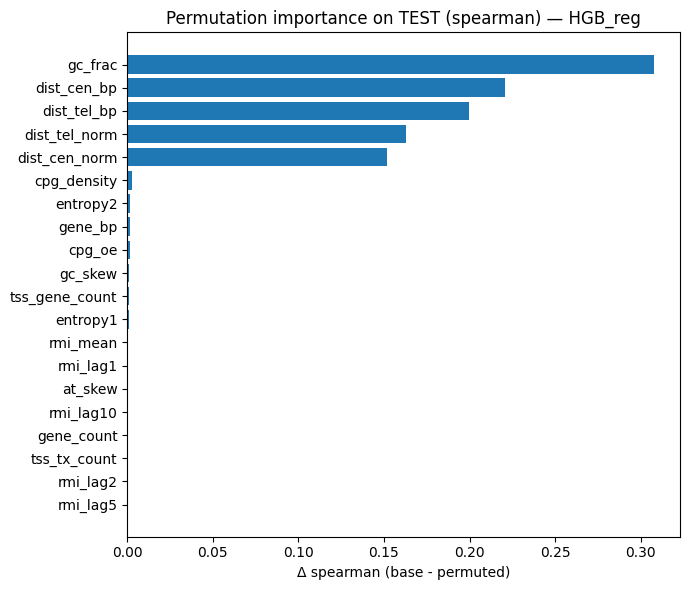

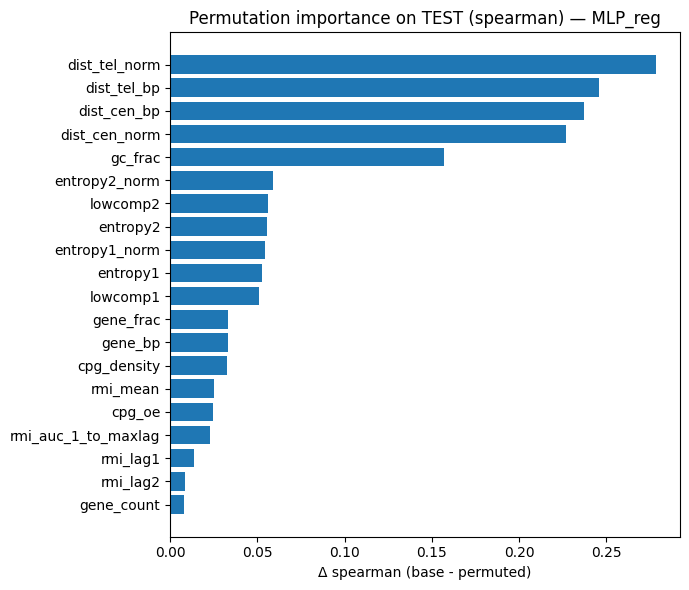

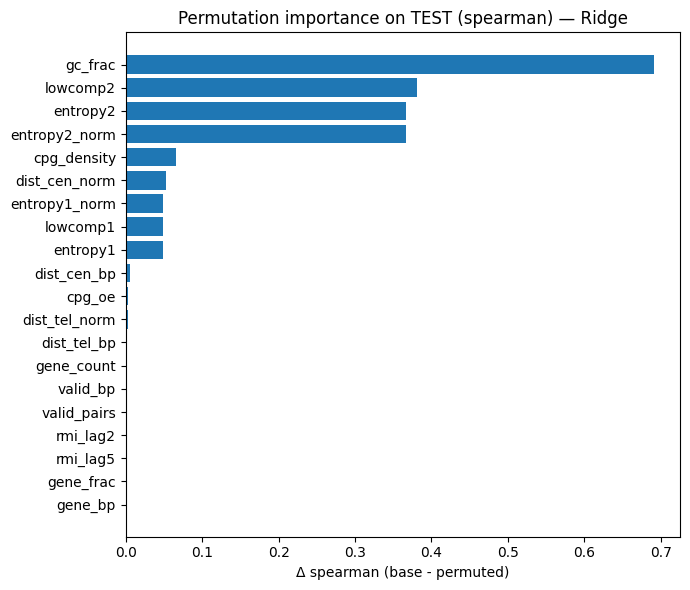

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

# -------------------------
# CONFIG
# -------------------------
VAL_FRAC     = 0.20
TEST_FRAC    = 0.20
N_REPEATS    = 10
N_PERM       = 3
SCORE_METRIC = "spearman"  # "spearman" or "r2"

try:
    RANDOM_SEED
except NameError:
    RANDOM_SEED = 7

# -------------------------
# target
# -------------------------
Y_COL = "y_log2" if "y_log2" in df.columns else ("y_log2_assay" if "y_log2_assay" in df.columns else None)
if Y_COL is None:
    raise ValueError("Cannot find y_log2 / y_log2_assay in df.")
print("Using Y_COL =", Y_COL)

# -------------------------
# filter valid bins if present (keep consistent with main benchmark)
# -------------------------
df_imp = df.copy()
if "valid_bin" in df_imp.columns:
    before = len(df_imp)
    df_imp = df_imp[df_imp["valid_bin"] == True].copy()
    print(f"Filtered valid_bin: {before} -> {len(df_imp)}")

# -------------------------
# build features from df (PRIMARY ONLY)
# -------------------------
meta_cols   = {"bin_id","chr","start0","end0","bin_size","valid_bin"}
target_cols = {"S_obs","S_null_mean","S_null_std","y_log2","y_z","y_log2_assay","y_z_assay"}
exclude = meta_cols.union(target_cols)

feat_cols_all = [c for c in df_imp.columns if c not in exclude]

TECH_PATTERNS = (
    "umap", "mapp",
    "repeat", "rmsk",
    "segdup", "superdup",
    "blacklist", "gap"
)
feat_cols_primary = [c for c in feat_cols_all if not any(p in c.lower() for p in TECH_PATTERNS)]
removed_cols = [c for c in feat_cols_all if c not in feat_cols_primary]

print(f"[Features] primary={len(feat_cols_primary)} / total={len(feat_cols_all)} | removed_tech={len(removed_cols)}")
print("Removed technical cols (first 30):", removed_cols[:30])

# -------------------------
# scoring
# -------------------------
def score_fn(y_true, y_pred, metric="spearman"):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if metric == "r2":
        return float(r2_score(y_true, y_pred))
    return float(spearmanr(y_true, y_pred).correlation)

# -------------------------
# wrappers predict(X_raw)
# -------------------------
class RidgeWrapper:
    def __init__(self, imp, sc, model):
        self.imp = imp
        self.sc = sc
        self.model = model
    def predict(self, X_raw):
        X_i = self.imp.transform(X_raw)
        X_s = self.sc.transform(X_i)
        return self.model.predict(X_s)

class HGBWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X_raw):
        return self.model.predict(X_raw)

class MLPWrapper:
    def __init__(self, imp, sc, mlp_model):
        self.imp = imp
        self.sc = sc
        self.mlp = mlp_model
    def predict(self, X_raw):
        X_i = self.imp.transform(X_raw)
        X_s = self.sc.transform(X_i)
        return mlp_reg_predict(self.mlp, X_s)  # must exist

# -------------------------
# permutation importance (in-place)
# -------------------------
def permutation_importance_inplace(predictor, X_te, y_te, metric="spearman", n_perm=3, seed=7):
    rng = np.random.default_rng(seed)
    X = np.asarray(X_te, dtype=np.float32, order="C")
    y = np.asarray(y_te, dtype=float)

    base = score_fn(y, predictor.predict(X), metric=metric)

    n, p = X.shape
    imps = np.zeros((n_perm, p), dtype=np.float64)

    X_work = X.copy()
    for r in range(n_perm):
        perm_idx = rng.permutation(n)
        for j in range(p):
            col = X_work[:, j].copy()
            X_work[:, j] = col[perm_idx]
            s = score_fn(y, predictor.predict(X_work), metric=metric)
            imps[r, j] = base - s
            X_work[:, j] = col

    return base, imps.mean(axis=0), imps.std(axis=0)

# -------------------------
# MAIN: repeated random splits
# -------------------------
X_all = df_imp[feat_cols_primary].to_numpy(dtype=np.float32)
y_all = df_imp[Y_COL].to_numpy(dtype=float)
y_bins_all = pd.qcut(y_all, q=10, labels=False, duplicates="drop")

rows = []

for rep in range(N_REPEATS):
    seed = RANDOM_SEED + rep

    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=seed)
    pool_idx, te_idx = next(sss1.split(X_all, y_bins_all))

    X_pool = X_all[pool_idx]; y_pool = y_all[pool_idx]
    X_te   = X_all[te_idx];   y_te   = y_all[te_idx]

    y_bins_pool = pd.qcut(y_pool, q=10, labels=False, duplicates="drop")
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=seed)
    tr_idx, va_idx = next(sss2.split(X_pool, y_bins_pool))

    X_tr, y_tr = X_pool[tr_idx], y_pool[tr_idx]
    X_va, y_va = X_pool[va_idx], y_pool[va_idx]

    # HGB
    hgb = HistGradientBoostingRegressor(
        random_state=seed, max_depth=6, learning_rate=0.05, max_iter=500
    )
    hgb.fit(X_tr, y_tr)
    hgbw = HGBWrapper(hgb)

    # Ridge (impute+scale)
    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()
    X_tr_i = imp.fit_transform(X_tr)
    X_va_i = imp.transform(X_va)
    X_te_i = imp.transform(X_te)
    X_tr_s = sc.fit_transform(X_tr_i)
    X_va_s = sc.transform(X_va_i)

    ridge = Ridge(alpha=1.0, random_state=seed)
    ridge.fit(X_tr_s, y_tr)
    ridgew = RidgeWrapper(imp, sc, ridge)

    # MLP (same preprocessing; must exist in notebook)
    mlp = train_mlp_reg(
        X_tr_s, y_tr,
        X_va_s, y_va,
        seed=seed,
        hidden=(128,64),
        dropout=0.2
    )
    mlpw = MLPWrapper(imp, sc, mlp)

    # permutation importance on TEST
    for model_name, pred in [("HGB_reg", hgbw), ("Ridge", ridgew), ("MLP_reg", mlpw)]:
        base, imp_mean, imp_std = permutation_importance_inplace(
            pred, X_te, y_te, metric=SCORE_METRIC, n_perm=N_PERM, seed=seed
        )
        for f, m, s in zip(feat_cols_primary, imp_mean, imp_std):
            rows.append({
                "rep": rep,
                "seed": seed,
                "model": model_name,
                "metric": SCORE_METRIC,
                "base_score": base,
                "feature": f,
                "imp_mean": float(m),
                "imp_std": float(s),
                "n_test": int(len(y_te))
            })

imp_df = pd.DataFrame(rows)

# -------------------------
# summarize (mean±std across repeats)
# -------------------------
summary = (imp_df
           .groupby(["model","feature"], as_index=False)[["imp_mean","imp_std","base_score","n_test"]]
           .agg({"imp_mean":["mean","std"], "imp_std":["mean"], "base_score":["mean","std"], "n_test":["mean"]})
          )
summary.columns = ["model","feature",
                   "imp_mean_mean","imp_mean_std",
                   "imp_std_mean",
                   "base_score_mean","base_score_std",
                   "n_test_mean"]

# top-20 per model
for model in summary["model"].unique():
    top = (summary[summary["model"]==model]
           .sort_values("imp_mean_mean", ascending=False)
           .head(20))
    print(f"\n=== Top-20 features by permutation importance ({SCORE_METRIC}) | {model} ===")
    display(top[["feature","imp_mean_mean","imp_mean_std","base_score_mean","base_score_std"]])

# plots: top-20
for model in summary["model"].unique():
    top = (summary[summary["model"]==model]
           .sort_values("imp_mean_mean", ascending=False)
           .head(20)
           .iloc[::-1])
    plt.figure(figsize=(7, 6))
    plt.barh(top["feature"], top["imp_mean_mean"])
    plt.title(f"Permutation importance on TEST ({SCORE_METRIC}) — {model}")
    plt.xlabel(f"Δ {SCORE_METRIC} (base - permuted)")
    plt.tight_layout()
    plt.show()

In [ ]:
import os
import pandas as pd

BS = 25_000

pathA = os.path.join(OUTDIR, f"dataset_by_assay_hg38_{BS}.csv.gz")
dsA = pd.read_csv(pathA)

# calcola seq features UNA volta per bin (drop_duplicates su bin_id)
bins_for_seq = dsA[["bin_id","chr","start0","end0","valid_bin"]].drop_duplicates("bin_id").copy()

SEQ_STRIDE = 1  # 2 o 5 se vuoi più veloce
seq_feat = seq_features_for_bins(bins_for_seq, FASTA_HG38, stride=SEQ_STRIDE)

dsA2 = dsA.merge(seq_feat, on="bin_id", how="left")

out_path = os.path.join(OUTDIR, f"dataset_by_assay_hg38_{BS}_seqfeat.csv")
save_csv(dsA2, out_path)
print("Saved:", out_path + ".gz")


Loading: out_bins_experiment/dataset_by_assay_hg38_25000.csv.gz
dfA shape: (370623, 39)
Columns head: ['bin_id', 'assay', 'S_obs_assay', 'S_null_mean_assay', 'S_null_std_assay', 'y_log2_assay', 'y_z_assay', 'chr', 'start0', 'end0', 'bin_size', 'valid_bin', 'gc_frac', 'gene_bp', 'gene_frac', 'gene_count', 'tss_tx_count', 'tss_gene_count', 'repeat_frac_total', 'repeat_frac_LINE', 'repeat_frac_SINE', 'repeat_frac_LTR', 'repeat_frac_DNA', 'repeat_frac_Simple_repeat', 'repeat_frac_SATELLITE']
n_features: 27
features (first 30): ['gc_frac', 'gene_bp', 'gene_frac', 'gene_count', 'tss_tx_count', 'tss_gene_count', 'repeat_frac_total', 'repeat_frac_LINE', 'repeat_frac_SINE', 'repeat_frac_LTR', 'repeat_frac_DNA', 'repeat_frac_Simple_repeat', 'repeat_frac_SATELLITE', 'segdup_frac', 'mapp_mean', 'mapp_cov', 'mapp_frac_gt_0.5', 'dist_tel_bp', 'dist_cen_bp', 'dist_tel_norm', 'dist_cen_norm', 'rmi_lag1', 'rmi_lag2', 'rmi_lag5', 'rmi_lag10', 'rmi_mean', 'rmi_auc_1_to_maxlag']
Using Y_COL = y_log2_assay

In [44]:
from sklearn.model_selection import StratifiedShuffleSplit

VAL_FRAC = 0.20
assays = sorted(df["assay"].dropna().unique().tolist())
print("Assays:", assays)

rows = []

for i, assay_holdout in enumerate(assays):
    seed = RANDOM_SEED + i

    df_test = df[df["assay"] == assay_holdout].copy()
    df_pool = df[df["assay"] != assay_holdout].copy()

    # opzionale: tieni solo valid bins
    if "valid_bin" in df.columns:
        df_test = df_test[df_test["valid_bin"] == True].copy()
        df_pool = df_pool[df_pool["valid_bin"] == True].copy()

    X_te = df_test[feat_cols].to_numpy(dtype=np.float32)
    y_te = df_test[Y_COL].to_numpy(dtype=float)

    X_pool = df_pool[feat_cols].to_numpy(dtype=np.float32)
    y_pool = df_pool[Y_COL].to_numpy(dtype=float)

    # stratify per decili del target nel pool
    y_bins = pd.qcut(y_pool, q=10, labels=False, duplicates="drop")

    sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=seed)
    tr_idx, va_idx = next(sss.split(X_pool, y_bins))

    X_tr, y_tr = X_pool[tr_idx], y_pool[tr_idx]
    X_va, y_va = X_pool[va_idx], y_pool[va_idx]

    res = fit_eval_regressors(
        X_tr, y_tr, X_va, y_va, X_te, y_te,
        seed=seed,
        mlp_loss="smoothl1",
        mlp_hidden=(128,64),
        mlp_dropout=0.2
    )
    res["assay_holdout"] = assay_holdout
    res["n_test"] = len(df_test)
    rows.append(res)

bench_loao = pd.concat(rows, ignore_index=True)

display(
    bench_loao[["assay_holdout","n_test","model","Spearman","R2","MAE","Hits@1%","Hits@5%"]]
    .sort_values(["assay_holdout","model"])
)

summary_loao = (bench_loao
    .groupby("model", as_index=False)[["Spearman","R2","MAE","hits1","hits5"]]
    .agg(["mean","std"])
)
display(summary_loao)


Assays: ['ATAC_seq', 'Circle_Seq', 'WGS']


,assay_holdout,n_test,model,Spearman,R2,MAE,Hits@1%,Hits@5%
0,ATAC_seq,112542,HGB_reg,0.123311,-0.915370,0.434784,120/1126,836/5628
2,ATAC_seq,112542,MLP_reg,0.123840,-0.757639,0.416184,40/1126,808/5628
1,ATAC_seq,112542,Ridge,0.119327,-0.845185,0.432231,56/1126,892/5628
3,Circle_Seq,112542,HGB_reg,0.183831,-0.140161,0.735618,95/1126,439/5628
5,Circle_Seq,112542,MLP_reg,0.179434,-0.160442,0.741840,89/1126,471/5628
4,Circle_Seq,112542,Ridge,0.160718,-0.100377,0.737569,8/1126,223/5628
6,WGS,112542,HGB_reg,0.373989,0.131333,0.458986,79/1126,668/5628
8,WGS,112542,MLP_reg,0.368257,0.123994,0.458082,74/1126,806/5628
7,WGS,112542,Ridge,0.396901,0.121030,0.458705,29/1126,596/5628


model  Spearman                  R2                 MAE            \
                mean       std      mean       std      mean       std   
0  HGB_reg  0.227044  0.130806 -0.308066  0.543177  0.543130  0.167139   
1  MLP_reg  0.223844  0.128118 -0.264696  0.449968  0.538702  0.177166   
2    Ridge  0.225648  0.149746 -0.274844  0.506183  0.542835  0.169163   

       hits1                  hits5              
        mean        std        mean         std  
0  98.000000  20.663978  647.666667  199.279536  
1  67.666667  25.106440  695.000000  193.992268  
2  31.000000  24.062419  570.333333  335.237727

# DeepCircle confronto

In [45]:
import os, glob, gzip, math, random
import numpy as np
import pandas as pd

import pyranges as pr
from pyfaidx import Fasta

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------
# Seeds
# -------------------------
SEED = 7
def set_seed(seed=7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# -------------------------
# DeepCircle settings
# -------------------------
WIN = 1000  # DeepCircle usa 1000bp windows
MAX_POS_PER_BED = 200_000  # safety (None = no limit)

DEEPCIRCLE_DB = r"DeepCircle/DNABERT/eccdna/db"
BED_GLOB = os.path.join(DEEPCIRCLE_DB, "**", "*.bed")
RAW_SUFFIX = "_eccdna_filt_uniq.bed"
bad_names = {"hg38_gaps.bed", "hg38_noalt_gap.bed"}

# -------------------------
# Genome resources (edit paths)
# -------------------------
HG38_FASTA    = r"./hg38.fa"                  # richiede hg38.fa.fai
GENCODE_GTF   = r"./gencode.v49.annotation.gtf.gz"
HG38_GAPS_BED = r"./hg38_gaps.bed"            # BED >=3 colonne: chr start end

# opzionale: centromeri (BED 0-based half-open) con 3 colonne chr start end
CENTROMERE_BED = None  # e.g. r"./hg38_centromeres.bed"

# cromosomi (DeepCircle tipicamente: chr1-22 + chrX)
KEEP_CHRS = [f"chr{i}" for i in range(1, 23)] + ["chrX"]

# output
OUTDIR = "out_deepcircle_like"
os.makedirs(OUTDIR, exist_ok=True)

def save_csv_gz(df, path):
    if not path.endswith(".gz"):
        path += ".gz"
    df.to_csv(path, index=False, compression="gzip")
    print("saved:", path, "shape:", df.shape)

# sanity checks
for p in [HG38_FASTA, HG38_FASTA + ".fai", GENCODE_GTF, HG38_GAPS_BED]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing required file: {p}")

print("OK config. OUTDIR=", OUTDIR)


DEVICE: cpu
OK config. OUTDIR= out_deepcircle_like


In [46]:
# chr sizes da .fai
fai = pd.read_csv(HG38_FASTA + ".fai", sep="\t", header=None, usecols=[0, 1], names=["Chromosome", "Length"])
fai = fai[fai["Chromosome"].isin(KEEP_CHRS)].copy()
CHR_LEN = dict(zip(fai["Chromosome"], fai["Length"].astype(int)))
print("Loaded chr sizes:", len(CHR_LEN), "example:", list(CHR_LEN.items())[:3])

# FASTA (upper)
FA = Fasta(HG38_FASTA, as_raw=True, sequence_always_upper=True)

# gaps BED
gaps = pd.read_csv(HG38_GAPS_BED, sep="\t", header=None, comment="#")
if gaps.shape[1] < 3:
    raise ValueError("HG38_GAPS_BED non valido: servono >=3 colonne (chr,start,end).")

gaps = gaps.iloc[:, :3].copy()
gaps.columns = ["Chromosome", "Start", "End"]
gaps = gaps[gaps["Chromosome"].isin(KEEP_CHRS)].copy()
gaps["Start"] = gaps["Start"].astype(int)
gaps["End"]   = gaps["End"].astype(int)
gaps = gaps[gaps["End"] > gaps["Start"]].copy()

gaps_pr = pr.PyRanges(gaps).merge()
print("Gaps intervals:", len(gaps), "| merged:", len(gaps_pr))


Loaded chr sizes: 23 example: [('chr1', 248956422), ('chr10', 133797422), ('chr11', 135086622)]
Gaps intervals: 547 | merged: 524


In [47]:
def load_genes_tss_from_gtf(gtf_gz_path, keep_chrs):
    genes = []
    tss   = []
    with gzip.open(gtf_gz_path, "rt") as fh:
        for line in fh:
            if not line or line[0] == "#":
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue
            chrom, source, feature, start, end, score, strand, frame, attrs = parts
            if chrom not in keep_chrs:
                continue

            # GTF: 1-based inclusive -> 0-based half-open
            s0 = int(start) - 1
            e0 = int(end)

            if feature == "gene":
                genes.append((chrom, s0, e0))
            elif feature == "transcript":
                if strand == "+":
                    t = s0
                elif strand == "-":
                    t = e0 - 1
                else:
                    continue
                tss.append((chrom, t, t+1))

    genes_df = pd.DataFrame(genes, columns=["Chromosome","Start","End"]).drop_duplicates()
    tss_df   = pd.DataFrame(tss,   columns=["Chromosome","Start","End"])
    genes_pr = pr.PyRanges(genes_df).merge()
    tss_pr   = pr.PyRanges(tss_df)  # punti, non merge
    return genes_pr, tss_pr

genes_pr, tss_pr = load_genes_tss_from_gtf(GENCODE_GTF, KEEP_CHRS)
print("Genes intervals (merged):", len(genes_pr))
print("TSS points:", len(tss_pr))

# centromeri (opzionale)
CENTROMERE = {}
if CENTROMERE_BED is not None:
    cen = pd.read_csv(CENTROMERE_BED, sep="\t", header=None, comment="#")
    cen = cen.iloc[:, :3].copy()
    cen.columns = ["Chromosome","Start","End"]
    cen = cen[cen["Chromosome"].isin(KEEP_CHRS)].copy()
    cen["Start"] = cen["Start"].astype(int)
    cen["End"]   = cen["End"].astype(int)
    for _, r in cen.iterrows():
        CENTROMERE[r["Chromosome"]] = (int(r["Start"]), int(r["End"]))
    print("Centromeres loaded:", len(CENTROMERE))
else:
    print("Centromeres: NONE (dist_cen features saranno NaN e non usate se scegli feat set base).")


Genes intervals (merged): 32136
TSS points: 505318
Centromeres: NONE (dist_cen features saranno NaN e non usate se scegli feat set base).


In [48]:
def read_bed_3col(bed_path):
    df = pd.read_csv(bed_path, sep="\t", header=None, comment="#", usecols=[0,1,2])
    df.columns = ["Chromosome","Start","End"]
    df = df[df["Chromosome"].isin(KEEP_CHRS)].copy()
    df["Start"] = df["Start"].astype(int)
    df["End"]   = df["End"].astype(int)
    df = df[df["End"] > df["Start"]].drop_duplicates()
    return df

def to_fixed_windows(df_intervals, win=1000):
    # finestre 1kb centrate al midpoint dell'eccDNA
    mid = ((df_intervals["Start"].values + df_intervals["End"].values) // 2).astype(int)
    start = mid - win//2
    end   = start + win
    out = pd.DataFrame({
        "Chromosome": df_intervals["Chromosome"].values,
        "Start": start,
        "End": end
    })

    # dentro chromosome
    ok = (out["Start"] >= 0) & (out["End"] <= out["Chromosome"].map(CHR_LEN))
    out = out[ok].copy()

    # dedup (evita leakage train/test)
    out = out.drop_duplicates().reset_index(drop=True)
    return out

def filter_no_overlap(df_windows: pd.DataFrame, forbidden_pr: pr.PyRanges) -> pd.DataFrame:
    if df_windows is None or len(df_windows) == 0:
        return df_windows
    wpr = pr.PyRanges(df_windows[["Chromosome","Start","End"]])
    cnt = wpr.count_overlaps(forbidden_pr).df["NumberOverlaps"].to_numpy()
    return df_windows[cnt == 0].reset_index(drop=True)

def sample_negatives_chr(chrom: str, n: int, forbidden_pr_chr: pr.PyRanges, win=1000,
                         rng=None, max_rounds=60, batch_factor=30, min_batch=30000) -> pd.DataFrame:
    if n <= 0:
        return pd.DataFrame(columns=["Chromosome","Start","End"])
    if rng is None:
        rng = np.random.default_rng(SEED)

    L = int(CHR_LEN[chrom])
    if L <= win + 1:
        raise ValueError(f"Chrom {chrom} too short for win={win} (len={L})")

    need = n
    kept = []
    for _ in range(max_rounds):
        if need <= 0:
            break

        m = max(min_batch, need * batch_factor)
        starts = rng.integers(0, L - win, size=m, endpoint=False, dtype=np.int64)
        cand = pd.DataFrame({"Chromosome": chrom, "Start": starts, "End": starts + win})

        cand = filter_no_overlap(cand, forbidden_pr_chr)
        if len(cand) == 0:
            continue

        take = cand.head(need)
        kept.append(take)
        need -= len(take)

    if need > 0:
        raise RuntimeError(f"Neg sampling incomplete on {chrom}: missing {need}. Prova ad aumentare max_rounds/batch_factor o ridurre n.")
    out = pd.concat(kept, ignore_index=True).drop_duplicates().reset_index(drop=True)
    if len(out) > n:
        out = out.sample(n, random_state=SEED).reset_index(drop=True)
    return out

def sample_negatives_like_positives(pos_windows: pd.DataFrame, raw_eccdna_intervals: pd.DataFrame,
                                    win=1000, avoid_pos_overlap=True) -> pd.DataFrame:
    forb_df = pd.concat([
        raw_eccdna_intervals[["Chromosome","Start","End"]],
        gaps[["Chromosome","Start","End"]],
    ], ignore_index=True).drop_duplicates()

    if avoid_pos_overlap:
        forb_df = pd.concat([forb_df, pos_windows[["Chromosome","Start","End"]]], ignore_index=True).drop_duplicates()

    forbidden_pr = pr.PyRanges(forb_df).merge()
    n_per_chr = pos_windows["Chromosome"].value_counts().to_dict()
    rng = np.random.default_rng(SEED)

    neg_all = []
    for chrom, n_ch in n_per_chr.items():
        forb_chr = forbidden_pr[chrom]
        neg_chr = sample_negatives_chr(chrom, n_ch, forb_chr, win=win, rng=rng)
        neg_all.append(neg_chr)

    neg = pd.concat(neg_all, ignore_index=True)
    neg = neg.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return neg

def make_deepcircle_xy_from_bed(bed_path, filter_len_lt_win=True):
    raw = read_bed_3col(bed_path)
    if len(raw) == 0:
        return None

    # DeepCircle: spesso filtra eccDNA >= 1000bp
    if filter_len_lt_win:
        raw = raw[(raw["End"] - raw["Start"]) < WIN].copy()
        if len(raw) == 0:
            return None

    # safety
    if MAX_POS_PER_BED is not None and len(raw) > MAX_POS_PER_BED:
        raw = raw.sample(MAX_POS_PER_BED, random_state=SEED).reset_index(drop=True)

    # pos windows
    pos_win = to_fixed_windows(raw, win=WIN)

    # rimuovi pos in gaps
    pos_win = filter_no_overlap(pos_win, gaps_pr)
    if len(pos_win) == 0:
        return None
    pos_win["y"] = 1

    # neg windows (1:1 per chrom, no overlap con eccDNA+gaps+pos)
    neg_win = sample_negatives_like_positives(pos_win, raw, win=WIN, avoid_pos_overlap=True)
    if len(neg_win) == 0:
        return None
    neg_win["y"] = 0

    df_xy = pd.concat([pos_win, neg_win], ignore_index=True)
    df_xy = df_xy.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return df_xy


In [49]:
# ---------- sequence helpers ----------
def _valid_len(seq: str) -> int:
    # escludi N dal denominatore
    return sum(b in "ACGT" for b in seq)

def _count_acgt(seq: str):
    # seq già upper
    return seq.count("A"), seq.count("C"), seq.count("G"), seq.count("T")

def gc_fraction_seq(seq: str) -> float:
    v = _valid_len(seq)
    if v == 0:
        return np.nan
    gc = seq.count("G") + seq.count("C")
    return gc / v

def cpg_density_seq(seq: str) -> float:
    v = _valid_len(seq)
    if v == 0:
        return np.nan
    # densità per bp (o per 100bp se vuoi moltiplicare)
    return seq.count("CG") / v

def cpg_oe_seq(seq: str) -> float:
    # observed/expected CpG
    v = _valid_len(seq)
    if v == 0:
        return np.nan
    C = seq.count("C")
    G = seq.count("G")
    obs = seq.count("CG")
    exp = (C * G) / max(v, 1)
    if exp == 0:
        return np.nan
    return obs / exp

def gc_skew_seq(seq: str) -> float:
    # (G-C)/(G+C)
    _, C, G, _ = _count_acgt(seq)
    den = (G + C)
    if den == 0:
        return np.nan
    return (G - C) / den

def at_skew_seq(seq: str) -> float:
    # (A-T)/(A+T)
    A, _, _, T = _count_acgt(seq)
    den = (A + T)
    if den == 0:
        return np.nan
    return (A - T) / den

def shannon_entropy_1mer(seq: str) -> float:
    # Shannon entropy su 1-mer (A,C,G,T), ignorando N
    v = _valid_len(seq)
    if v == 0:
        return np.nan
    A, C, G, T = _count_acgt(seq)
    p = np.array([A, C, G, T], dtype=float) / v
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

# ---------- main feature builder ----------
def build_features(df_xy: pd.DataFrame,
                   add_cpg=True,
                   add_skew=True,
                   add_entropy=True):
    df = df_xy.copy()

    # sequenze 1kb
    seqs = []
    for c, s, e in df[["Chromosome","Start","End"]].itertuples(index=False, name=None):
        seq = FA[c][int(s):int(e)]
        seqs.append(seq if seq is not None else "")
    seqs = [x.upper() if isinstance(x, str) else "" for x in seqs]

    # GC
    df["gc_fraction"] = [gc_fraction_seq(seq) for seq in seqs]

    # CpG features (opzionali)
    if add_cpg:
        df["cpg_density"] = [cpg_density_seq(seq) for seq in seqs]
        df["cpg_oe"]      = [cpg_oe_seq(seq) for seq in seqs]

    # skew (opzionali)
    if add_skew:
        df["gc_skew"] = [gc_skew_seq(seq) for seq in seqs]
        df["at_skew"] = [at_skew_seq(seq) for seq in seqs]

    # entropy (opzionale)
    if add_entropy:
        df["H1"] = [shannon_entropy_1mer(seq) for seq in seqs]

    # gene/tss overlaps
    wpr = pr.PyRanges(df[["Chromosome","Start","End"]])
    df["gene_count"] = wpr.count_overlaps(genes_pr).df["NumberOverlaps"].values
    df["tss_count"]  = wpr.count_overlaps(tss_pr).df["NumberOverlaps"].values
    df["log1p_gene_count"] = np.log1p(df["gene_count"].astype(float))
    df["log1p_tss_count"]  = np.log1p(df["tss_count"].astype(float))

    # dist telomere
    mid = ((df["Start"].values + df["End"].values) // 2).astype(int)
    chrlen = df["Chromosome"].map(CHR_LEN).values.astype(int)
    dist_tel = np.minimum(mid, chrlen - mid)
    df["dist_tel_bp"]   = dist_tel
    df["dist_tel_Mb"]   = dist_tel / 1e6
    df["dist_tel_norm"] = dist_tel / chrlen

    # dist centromere (se disponibile)
    if len(CENTROMERE) > 0:
        dist_cen = []
        for c, m, L in zip(df["Chromosome"].values, mid, chrlen):
            if c not in CENTROMERE:
                dist_cen.append(np.nan)
                continue
            a, b = CENTROMERE[c]
            if a <= m <= b:
                d = 0
            else:
                d = min(abs(m - a), abs(m - b))
            dist_cen.append(d)
        dist_cen = np.array(dist_cen, dtype=float)
        df["dist_cen_bp"]   = dist_cen
        df["dist_cen_Mb"]   = dist_cen / 1e6
        df["dist_cen_norm"] = dist_cen / chrlen

    # log transforms (stabili)
    df["log1p_dist_tel_Mb"]   = np.log1p(np.clip(df["dist_tel_Mb"].values, 0, None))
    df["log1p_dist_tel_norm"] = np.log1p(np.clip(df["dist_tel_norm"].values, 0, None))
    if "dist_cen_Mb" in df.columns:
        df["log1p_dist_cen_Mb"]   = np.log1p(np.clip(df["dist_cen_Mb"].values, 0, None))
        df["log1p_dist_cen_norm"] = np.log1p(np.clip(df["dist_cen_norm"].values, 0, None))

    return df


In [50]:
def safe_pr_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))

class ShallowMLP(nn.Module):
    def __init__(self, d_in, hidden=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)  # logits

@torch.no_grad()
def mlp_predict_proba(model, X, device=DEVICE):
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32, device=device)
    p = torch.sigmoid(model(Xt)).detach().cpu().numpy()
    return p

def train_mlp_earlystop(
    Xtr, ytr,
    Xva, yva,
    pos_weight=1.0,
    seed=7,
    device=DEVICE,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=512,
    max_epochs=200,
    patience=25,
    min_delta=1e-4,
    dropout=0.2,
    grad_clip=1.0,
    verbose=False
):
    set_seed(seed)
    model = ShallowMLP(d_in=Xtr.shape[1], hidden=64, dropout=dropout).to(device)

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.float32)
    ds = torch.utils.data.TensorDataset(Xtr_t, ytr_t)

    g = torch.Generator()
    g.manual_seed(seed)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False, generator=g)

    Xva_t = torch.tensor(Xva, dtype=torch.float32, device=device)
    yva_np = np.asarray(yva).astype(int)

    pw = torch.tensor([pos_weight], dtype=torch.float32, device=device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_pr = -np.inf
    best_state = None
    bad = 0

    for ep in range(1, max_epochs + 1):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

        with torch.no_grad():
            pva = torch.sigmoid(model(Xva_t)).detach().cpu().numpy()
        pr = safe_pr_auc(yva_np, pva)
        pr_eff = pr if np.isfinite(pr) else -np.inf

        if pr_eff > best_pr + min_delta:
            best_pr = pr_eff
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if verbose and (ep == 1 or ep % 10 == 0):
            print(f"[MLP] ep={ep} val PR-AUC={pr:.4f} best={best_pr:.4f} bad={bad}/{patience}")

        if bad >= patience:
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model

def metrics_bin(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_hat = (y_prob >= thr).astype(int)
    out = {
        "acc": accuracy_score(y_true, y_hat),
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
        "f1": f1_score(y_true, y_hat, zero_division=0),
    }
    if len(np.unique(y_true)) == 2:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
        out["pr_auc"]  = average_precision_score(y_true, y_prob)
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"]  = np.nan
    return out


In [51]:
def select_feat_cols(df_feat: pd.DataFrame, use_extended=True):
    # base (sempre)
    feat_cols = [
        "gc_fraction",
        "log1p_gene_count",
        "log1p_tss_count",
        "log1p_dist_tel_Mb",
        "log1p_dist_tel_norm",
    ]

    # extra seq (se presenti e richieste)
    if use_extended:
        for c in ["cpg_density","cpg_oe","gc_skew","at_skew","H1"]:
            if c in df_feat.columns:
                feat_cols.append(c)

    # centromere (solo se disponibili e finite)
    cen_cols = ["log1p_dist_cen_Mb","log1p_dist_cen_norm"]
    if all(c in df_feat.columns for c in cen_cols):
        if df_feat[cen_cols].replace([np.inf, -np.inf], np.nan).notna().all().all():
            feat_cols += cen_cols

    return feat_cols

def train_and_eval_on_df(df_feat: pd.DataFrame, use_extended=True, verbose_split=True):
    feat_cols = select_feat_cols(df_feat, use_extended=use_extended)

    df = df_feat.replace([np.inf, -np.inf], np.nan).dropna(subset=feat_cols + ["y"]).copy()
    X = df[feat_cols].values.astype(np.float32)
    y = df["y"].values.astype(int)

    # 80/20 test
    X_trainfull, X_te, y_trainfull, y_te = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    # val dal train: 0.125*0.8 = 0.10 totale
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_trainfull, y_trainfull, test_size=0.125, random_state=SEED, stratify=y_trainfull
    )

    if verbose_split:
        print("Split sizes:", len(y_tr), len(y_va), len(y_te),
              "| pos:", int(y_tr.sum()), int(y_va.sum()), int(y_te.sum()))

    # preprocess (impute+scale) per LR/MLP
    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()

    X_tr_i = imp.fit_transform(X_tr)
    X_va_i = imp.transform(X_va)
    X_te_i = imp.transform(X_te)

    X_tr_s = sc.fit_transform(X_tr_i)
    X_va_s = sc.transform(X_va_i)
    X_te_s = sc.transform(X_te_i)

    # pos_weight (se bilanciato ~1)
    pos = max(int(y_tr.sum()), 1)
    neg = len(y_tr) - pos
    pos_weight = float(neg / pos)

    rows = []

    # LogReg
    lr = LogisticRegression(max_iter=5000, solver="lbfgs", random_state=SEED)
    lr.fit(X_tr_s, y_tr)
    p_lr = lr.predict_proba(X_te_s)[:, 1]
    rows.append({"model": "LogReg", **metrics_bin(y_te, p_lr, thr=0.5)})

    # HGB (no scaling; ma qui imputiamo già a monte per avere X senza NaN)
    hgb = HistGradientBoostingClassifier(
        random_state=SEED, max_depth=6, learning_rate=0.05, max_iter=500
    )
    hgb.fit(X_tr_i, y_tr)
    p_hgb = hgb.predict_proba(X_te_i)[:, 1]
    rows.append({"model": "HGB", **metrics_bin(y_te, p_hgb, thr=0.5)})

    # MLP
    mlp = train_mlp_earlystop(
        Xtr=X_tr_s, ytr=y_tr,
        Xva=X_va_s, yva=y_va,
        pos_weight=pos_weight,
        seed=SEED,
        lr=1e-3, max_epochs=200, patience=25,
        batch_size=512, dropout=0.2,
        verbose=False
    )
    p_mlp = mlp_predict_proba(mlp, X_te_s)
    rows.append({"model": "MLP_shallow", **metrics_bin(y_te, p_mlp, thr=0.5)})

    res = pd.DataFrame(rows)
    return res, feat_cols, df


In [52]:
bed_files = sorted(glob.glob(BED_GLOB, recursive=True))
bed_files = [b for b in bed_files if b.endswith(RAW_SUFFIX)]
bed_files = [b for b in bed_files if os.path.basename(b) not in bad_names]

if len(bed_files) == 0:
    raise RuntimeError("Nessun *_eccdna_filt_uniq.bed trovato. Controlla DEEPCIRCLE_DB / BED_GLOB.")

test_bed = bed_files[0]
print("TEST BED:", os.path.basename(test_bed))

df_xy = make_deepcircle_xy_from_bed(test_bed)
print("XY:", len(df_xy), "pos:", int(df_xy["y"].sum()), "neg:", int((1-df_xy["y"]).sum()))

df_feat = build_features(df_xy, add_cpg=True, add_skew=True, add_entropy=True)
res, feat_cols_used, df_used = train_and_eval_on_df(df_feat, use_extended=True, verbose_split=True)

display(res.sort_values("f1", ascending=False))
print("Features used:", feat_cols_used)


TEST BED: PC-3_circleseq_eccdna_filt_uniq.bed
XY: 38610 pos: 19305 neg: 19305
Split sizes: 27027 3861 7722 | pos: 13513 1931 3861


,model,acc,precision,recall,f1,roc_auc,pr_auc
2,MLP_shallow,0.781015,0.756623,0.828542,0.790951,0.854034,0.826307
1,HGB,0.783735,0.768834,0.811448,0.789567,0.855749,0.827424
0,LogReg,0.776094,0.749766,0.828801,0.787305,0.847599,0.813993


Features used: ['gc_fraction', 'log1p_gene_count', 'log1p_tss_count', 'log1p_dist_tel_Mb', 'log1p_dist_tel_norm', 'cpg_density', 'cpg_oe', 'gc_skew', 'at_skew', 'H1']


In [53]:
bed_files = sorted(glob.glob(BED_GLOB, recursive=True))
bed_files = [b for b in bed_files if b.endswith(RAW_SUFFIX)]
bed_files = [b for b in bed_files if os.path.basename(b) not in bad_names]

print("RAW positive BED files found:", len(bed_files))
print("Example:", [os.path.basename(b) for b in bed_files[:10]])

all_rows = []
for i, bed in enumerate(bed_files, 1):
    name = os.path.basename(bed)
    print(f"\n[{i}/{len(bed_files)}] {name}")

    df_xy = make_deepcircle_xy_from_bed(bed)
    if df_xy is None or len(df_xy) == 0:
        print("  -> skipped (empty after filters)")
        continue

    print("  xy rows:", len(df_xy), "pos:", int(df_xy["y"].sum()), "neg:", int((1-df_xy["y"]).sum()))

    df_feat = build_features(df_xy, add_cpg=True, add_skew=True, add_entropy=True)

    res, feat_cols_used, df_used = train_and_eval_on_df(df_feat, use_extended=True, verbose_split=False)
    res["dataset"] = name
    res["n"] = int(len(df_used))
    res["n_pos"] = int(df_used["y"].sum())
    res["features_used"] = ",".join(feat_cols_used)
    all_rows.append(res)

if len(all_rows) == 0:
    raise RuntimeError("Nessun dataset valido prodotto. Controlla filtri/paths.")

res_all = pd.concat(all_rows, ignore_index=True)
display(res_all.sort_values(["dataset","model"]).head(30))

metrics = ["acc","precision","recall","f1","roc_auc","pr_auc"]
paper_like = (
    res_all.groupby("model")[metrics]
           .agg(["mean","std"])
           .sort_values(("f1","mean"), ascending=False)
)
display(paper_like)

save_csv_gz(res_all, os.path.join(OUTDIR, "deepcircle_like_eval_rawpos_per_bed.csv"))
paper_like.to_csv(os.path.join(OUTDIR, "deepcircle_like_eval_rawpos_summary_mean_sd.csv"))
print("Saved summaries in:", OUTDIR)


RAW positive BED files found: 12
Example: ['PC-3_circleseq_eccdna_filt_uniq.bed', 'C4-2_circleseq_eccdna_filt_uniq.bed', 'ES2_circleseq_eccdna_filt_uniq.bed', 'HeLaS3_circleseq_eccdna_filt_uniq.bed', 'Leukocytes_circleseq_eccdna_filt_uniq.bed', 'LnCap_circleseq_eccdna_filt_uniq.bed', 'Lung-normal_circleseq_eccdna_filt_uniq.bed', 'Lung-tumor_circleseq_eccdna_filt_uniq.bed', 'Muscle_circleseq_eccdna_filt_uniq.bed', 'OVCAR8_circleseq_eccdna_filt_uniq.bed']

[1/12] PC-3_circleseq_eccdna_filt_uniq.bed
  xy rows: 38610 pos: 19305 neg: 19305

[2/12] C4-2_circleseq_eccdna_filt_uniq.bed
  xy rows: 98800 pos: 49400 neg: 49400

[3/12] ES2_circleseq_eccdna_filt_uniq.bed
  xy rows: 333421 pos: 166713 neg: 166708

[4/12] HeLaS3_circleseq_eccdna_filt_uniq.bed
  xy rows: 49798 pos: 24899 neg: 24899

[5/12] Leukocytes_circleseq_eccdna_filt_uniq.bed
  xy rows: 6634 pos: 3317 neg: 3317

[6/12] LnCap_circleseq_eccdna_filt_uniq.bed
  xy rows: 244992 pos: 122496 neg: 122496

[7/12] Lung-normal_circleseq_ecc

,model,acc,precision,recall,f1,roc_auc,pr_auc,dataset,n,n_pos,features_used
4,HGB,0.785830,0.764717,0.825709,0.794043,0.862563,0.836778,C4-2_circleseq_eccdna_filt_uniq.bed,98800,49400,"gc_fraction,log1p_gene_count,log1p_tss_count,l..."
3,LogReg,0.778391,0.751762,0.831275,0.789522,0.850651,0.821606,C4-2_circleseq_eccdna_filt_uniq.bed,98800,49400,"gc_fraction,log1p_gene_count,log1p_tss_count,l..."
5,MLP_shallow,0.786235,0.758690,0.839474,0.797040,0.860010,0.833622,C4-2_circleseq_eccdna_filt_uniq.bed,98800,49400,"gc_fraction,log1p_gene_count,log1p_tss_count,l..."
7,HGB,0.713174,0.685017,0.789281,0.733462,0.782226,0.743231,ES2_circleseq_eccdna_filt_uniq.bed,333421,166713,"gc_fraction,log1p_gene_count,log1p_tss_count,l..."
6,LogReg,0.707715,0.684900,0.769427,0.724707,0.771976,0.730461,ES2_circleseq_eccdna_filt_uniq.bed,333421,166713,"gc_fraction,log1p_gene_count,log1p_tss_count,l..."
8,MLP_shallow,0.712289,0.685432,0.784722,0.731724,0.779317,0.737646,ES2_circleseq_eccdna_filt_uniq.bed,333421,166713,"gc_fraction,log1p_gene_count,log1p_tss_count,l..."
10,HGB,0.771586,0.741907,0.832932,0.784789,0.840020,0.799117,HeLaS3_circleseq_eccdna_filt_uniq.bed,49797,24899,"gc_fraction,log1p_gene_count,log1p_tss_count,l..."
9,LogReg,0.763755,0.727999,0.842169,0.780933,0.832975,0.790847,HeLaS3_circleseq_eccdna_filt_uniq.bed,49797,24899,"gc_fraction,log1p_gene_count,log1p_tss_count,l..."
11,MLP_shallow,0.770582,0.733982,0.848795,0.787224,0.840274,0.794505,HeLaS3_circleseq_eccdna_filt_uniq.bed,49797,24899,"gc_fraction,log1p_gene_count,log1p_tss_count,l..."
13,HGB,0.645818,0.643068,0.656627,0.649776,0.689025,0.653011,Leukocytes_circleseq_eccdna_filt_uniq.bed,6634,3317,"gc_fraction,log1p_gene_count,log1p_tss_count,l..."


acc           precision              recall            \
                 mean       std      mean       std      mean       std   
model                                                                     
MLP_shallow  0.751137  0.040517  0.727071  0.037261  0.804532  0.041599   
HGB          0.751095  0.043915  0.731388  0.040984  0.793889  0.049153   
LogReg       0.744563  0.040370  0.718023  0.035790  0.805295  0.044001   

                   f1             roc_auc              pr_auc            
                 mean       std      mean       std      mean       std  
model                                                                    
MLP_shallow  0.763762  0.038436  0.820538  0.048173  0.787981  0.051511  
HGB          0.761180  0.043409  0.821065  0.052094  0.789892  0.054692  
LogReg       0.759100  0.039028  0.811687  0.047039  0.775953  0.048112

saved: out_deepcircle_like/deepcircle_like_eval_rawpos_per_bed.csv.gz shape: (36, 11)
Saved summaries in: out_deepcircle_like


facciamo un confronto 1:1 “DeepCircle-like” nel modo più difendibile: stesso dataset, stesso preprocessing, stessi negativi 1:1, stesso split (train/val/test), stessi seed, e poi confronti DeepCircle (DNABERT) vs i tuoi modelli (HGB/LogReg/MLP + engineered features).

In [54]:
import os, glob, gzip, math, random
import numpy as np
import pandas as pd

import pyranges as pr
from pyfaidx import Fasta

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef, balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

import torch
import torch.nn as nn
import torch.optim as optim

SEED = 7
WIN  = 1000  # DeepCircle window
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEEPCIRCLE_DB = r"DeepCircle/DNABERT/eccdna/db"
BED_GLOB = os.path.join(DEEPCIRCLE_DB, "**", "*.bed")
RAW_SUFFIX = "_eccdna_filt_uniq.bed"

HG38_FASTA    = r"./hg38.fa"                 # richiede anche hg38.fa.fai
GENCODE_GTF   = r"./gencode.v49.annotation.gtf.gz"
HG38_GAPS_BED = r"./hg38_gaps.bed"

# opzionale: centromeri
CENTROMERE_BED = None  # e.g. "./hg38_centromeres.bed"

KEEP_CHRS = [f"chr{i}" for i in range(1,23)] + ["chrX"]  # come DeepCircle tipico
MAX_POS_PER_BED = 200_000   # safety, None per disattivare

OUTDIR = "out_deepcircle_1to1"
os.makedirs(OUTDIR, exist_ok=True)

def set_seed(seed=7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("DEVICE:", DEVICE, "| OUTDIR:", OUTDIR)


DEVICE: cpu | OUTDIR: out_deepcircle_1to1


In [55]:
# chr sizes da .fai
fai_path = HG38_FASTA + ".fai"
fai = pd.read_csv(fai_path, sep="\t", header=None, usecols=[0,1], names=["Chromosome","Length"])
fai = fai[fai["Chromosome"].isin(KEEP_CHRS)].copy()
CHR_LEN = dict(zip(fai["Chromosome"], fai["Length"].astype(int)))
print("Loaded chr sizes:", len(CHR_LEN))

# FASTA
FA = Fasta(HG38_FASTA, as_raw=True, sequence_always_upper=True)

# gaps
gaps = pd.read_csv(HG38_GAPS_BED, sep="\t", header=None, comment="#")
gaps = gaps.iloc[:, :3].copy()
gaps.columns = ["Chromosome","Start","End"]
gaps = gaps[gaps["Chromosome"].isin(KEEP_CHRS)].copy()
gaps["Start"] = gaps["Start"].astype(int)
gaps["End"]   = gaps["End"].astype(int)
gaps_pr = pr.PyRanges(gaps)

print("Gaps intervals:", len(gaps))


Loaded chr sizes: 23
Gaps intervals: 547


In [56]:
def load_genes_tss_from_gtf(gtf_gz_path, keep_chrs):
    genes = []
    tss   = []
    with gzip.open(gtf_gz_path, "rt") as fh:
        for line in fh:
            if not line or line[0] == "#":
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue
            chrom, source, feature, start, end, score, strand, frame, attrs = parts
            if chrom not in keep_chrs:
                continue

            # GTF: 1-based inclusive -> 0-based half-open
            s0 = int(start) - 1
            e0 = int(end)

            if feature == "gene":
                genes.append((chrom, s0, e0))
            elif feature == "transcript":
                if strand == "+":
                    t = s0
                elif strand == "-":
                    t = e0 - 1
                else:
                    continue
                tss.append((chrom, t, t+1))

    genes_df = pd.DataFrame(genes, columns=["Chromosome","Start","End"]).drop_duplicates()
    tss_df   = pd.DataFrame(tss,   columns=["Chromosome","Start","End"])
    return pr.PyRanges(genes_df), pr.PyRanges(tss_df)

genes_pr, tss_pr = load_genes_tss_from_gtf(GENCODE_GTF, KEEP_CHRS)
print("Genes:", len(genes_pr), "| TSS:", len(tss_pr))

# centromeri (opzionale)
CENTROMERE = {}
if CENTROMERE_BED is not None:
    cen = pd.read_csv(CENTROMERE_BED, sep="\t", header=None, comment="#").iloc[:, :3].copy()
    cen.columns = ["Chromosome","Start","End"]
    cen = cen[cen["Chromosome"].isin(KEEP_CHRS)].copy()
    cen["Start"] = cen["Start"].astype(int)
    cen["End"]   = cen["End"].astype(int)
    for _, r in cen.iterrows():
        CENTROMERE[r["Chromosome"]] = (int(r["Start"]), int(r["End"]))
    print("Centromeres loaded:", len(CENTROMERE))
else:
    print("Centromeres: NONE")


Genes: 77965 | TSS: 505318
Centromeres: NONE


In [57]:
def read_bed_3col(bed_path):
    df = pd.read_csv(bed_path, sep="\t", header=None, comment="#", usecols=[0,1,2])
    df.columns = ["Chromosome","Start","End"]
    df = df[df["Chromosome"].isin(KEEP_CHRS)].copy()
    df["Start"] = df["Start"].astype(int)
    df["End"]   = df["End"].astype(int)
    df = df[df["End"] > df["Start"]]
    return df

def to_fixed_windows(df_intervals, win=1000):
    mid = ((df_intervals["Start"].values + df_intervals["End"].values) // 2).astype(int)
    start = mid - win//2
    end   = start + win
    out = pd.DataFrame({"Chromosome": df_intervals["Chromosome"].values, "Start": start, "End": end})
    ok = (out["Start"] >= 0) & (out["End"] <= out["Chromosome"].map(CHR_LEN))
    return out[ok].reset_index(drop=True)

def drop_any_overlap(df_windows, forbidden_pr):
    if len(df_windows) == 0:
        return df_windows
    wpr = pr.PyRanges(df_windows)
    ov = wpr.overlap(forbidden_pr)
    if len(ov) == 0:
        return df_windows
    ov_df = ov.df[["Chromosome","Start","End"]].drop_duplicates()
    bad = set(map(tuple, ov_df.values.tolist()))
    mask = [tuple(x) not in bad for x in df_windows[["Chromosome","Start","End"]].values.tolist()]
    return df_windows[np.array(mask)].reset_index(drop=True)

def sample_negatives_global(n, forbidden_pr, win=1000, max_rounds=50, batch_size=200000, seed=7):
    if n <= 0:
        return pd.DataFrame(columns=["Chromosome","Start","End"])
    rng = np.random.default_rng(seed)

    chroms = KEEP_CHRS
    lens   = np.array([CHR_LEN[c] for c in chroms], dtype=np.int64)
    weights = lens / lens.sum()

    kept = []
    need = n
    rounds = 0

    while need > 0 and rounds < max_rounds:
        rounds += 1
        m = max(batch_size, need * 10)

        ch = rng.choice(chroms, size=m, p=weights)
        starts = np.array([rng.integers(0, CHR_LEN[c] - win) for c in ch], dtype=np.int64)
        ends   = starts + win

        cand = pd.DataFrame({"Chromosome": ch, "Start": starts, "End": ends})
        cand_pr = pr.PyRanges(cand)

        ov = cand_pr.overlap(forbidden_pr)
        if len(ov) > 0:
            ov_df = ov.df[["Chromosome","Start","End"]].drop_duplicates()
            bad = set(map(tuple, ov_df.values.tolist()))
            mask = [tuple(x) not in bad for x in cand[["Chromosome","Start","End"]].values.tolist()]
            cand = cand[np.array(mask)]

        if len(cand) == 0:
            continue

        take = cand.head(need)
        kept.append(take)
        need -= len(take)

    if need > 0:
        raise RuntimeError(f"Neg sampling incompleto: mancavano {need}. Prova ad aumentare max_rounds/batch_size o ridurre n.")

    out = pd.concat(kept, ignore_index=True).drop_duplicates().reset_index(drop=True)
    if len(out) > n:
        out = out.sample(n, random_state=seed).reset_index(drop=True)
    return out

def sample_negatives_like_positives(pos_windows, raw_eccdna_intervals, win=1000, seed=7):
    forb_df = pd.concat([
        raw_eccdna_intervals[["Chromosome","Start","End"]],
        gaps[["Chromosome","Start","End"]]
    ], ignore_index=True).drop_duplicates()
    forbidden_pr = pr.PyRanges(forb_df)

    n_per_chr = pos_windows["Chromosome"].value_counts().to_dict()
    neg_all = []
    for chrom, n_ch in n_per_chr.items():
        forb_chr = forbidden_pr[chrom]
        neg_chr = sample_negatives_global(
            n_ch, forb_chr, win=win,
            batch_size=max(50000, n_ch*20),
            seed=seed + hash(chrom) % 10_000
        )
        neg_chr["Chromosome"] = chrom
        neg_all.append(neg_chr)

    neg = pd.concat(neg_all, ignore_index=True).drop_duplicates()
    neg = neg.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return neg

def make_xy_from_bed(bed_path, win=1000, filter_len_lt_win=True, seed=7):
    raw = read_bed_3col(bed_path)
    if len(raw) == 0:
        return None

    if filter_len_lt_win:
        raw = raw[(raw["End"] - raw["Start"]) < win].copy()
        if len(raw) == 0:
            return None

    if MAX_POS_PER_BED is not None and len(raw) > MAX_POS_PER_BED:
        raw = raw.sample(MAX_POS_PER_BED, random_state=seed).reset_index(drop=True)

    pos = to_fixed_windows(raw, win=win)
    pos = drop_any_overlap(pos, gaps_pr)
    if len(pos) == 0:
        return None
    pos["y"] = 1

    neg = sample_negatives_like_positives(pos, raw, win=win, seed=seed)
    if len(neg) == 0:
        return None
    neg["y"] = 0

    df = pd.concat([pos, neg], ignore_index=True)
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return df

def make_split_masks(df, seed=7, test_frac=0.20, val_frac_of_train=0.125):
    # test=20% ; val=12.5% del train => 10% totale ; train=70%
    idx = np.arange(len(df))
    y = df["y"].values.astype(int)

    tr_full, te = train_test_split(idx, test_size=test_frac, random_state=seed, stratify=y)
    y_trfull = y[tr_full]
    tr, va = train_test_split(tr_full, test_size=val_frac_of_train, random_state=seed, stratify=y_trfull)

    m_tr = np.zeros(len(df), dtype=bool); m_tr[tr] = True
    m_va = np.zeros(len(df), dtype=bool); m_va[va] = True
    m_te = np.zeros(len(df), dtype=bool); m_te[te] = True
    return m_tr, m_va, m_te


In [58]:
def get_seq(chrom, start, end):
    s = FA[chrom][start:end]
    if s is None:
        return ""
    return str(s).upper()

def gc_fraction(seq):
    if not seq:
        return np.nan
    valid = sum(b in "ACGT" for b in seq)
    if valid == 0:
        return np.nan
    gc = seq.count("G") + seq.count("C")
    return gc / valid

def cpg_density(seq):
    # CpG per bp (su basi valide)
    if not seq:
        return np.nan
    valid = sum(b in "ACGT" for b in seq)
    if valid == 0:
        return np.nan
    cpg = seq.count("CG")
    return cpg / valid

def cpg_oe(seq):
    # observed/expected CpG
    if not seq:
        return np.nan
    valid = sum(b in "ACGT" for b in seq)
    if valid == 0:
        return np.nan
    C = seq.count("C")
    G = seq.count("G")
    obs = seq.count("CG")
    exp = (C * G) / max(valid, 1)
    if exp == 0:
        return np.nan
    return obs / exp

def gc_skew(seq):
    G = seq.count("G"); C = seq.count("C")
    den = G + C
    if den == 0:
        return np.nan
    return (G - C) / den

def at_skew(seq):
    A = seq.count("A"); T = seq.count("T")
    den = A + T
    if den == 0:
        return np.nan
    return (A - T) / den

def shannon_entropy_1mer(seq):
    # entropia su A/C/G/T (ignora N)
    if not seq:
        return np.nan
    counts = {b:0 for b in "ACGT"}
    for ch in seq:
        if ch in counts:
            counts[ch] += 1
    n = sum(counts.values())
    if n == 0:
        return np.nan
    H = 0.0
    for b in "ACGT":
        p = counts[b] / n
        if p > 0:
            H -= p * math.log(p, 2)
    return H  # max=2

def build_features(df_xy, add_cpg=True, add_skew=True, add_entropy=True):
    df = df_xy.copy()

    # sequence (serve sia per features sia per export DeepCircle)
    df["seq"] = [get_seq(c,s,e) for c,s,e in df[["Chromosome","Start","End"]].itertuples(index=False, name=None)]

    # base
    df["gc_fraction"] = df["seq"].map(gc_fraction)

    # gene/tss counts
    wpr = pr.PyRanges(df[["Chromosome","Start","End"]])
    df["gene_count"] = wpr.count_overlaps(genes_pr).df["NumberOverlaps"].values
    df["tss_count"]  = wpr.count_overlaps(tss_pr).df["NumberOverlaps"].values
    df["log1p_gene_count"] = np.log1p(df["gene_count"].astype(float))
    df["log1p_tss_count"]  = np.log1p(df["tss_count"].astype(float))

    # distances
    mid = ((df["Start"].values + df["End"].values) // 2).astype(int)
    chrlen = df["Chromosome"].map(CHR_LEN).values.astype(int)
    dist_tel = np.minimum(mid, chrlen - mid)
    df["dist_tel_bp"]   = dist_tel
    df["dist_tel_Mb"]   = dist_tel / 1e6
    df["dist_tel_norm"] = dist_tel / chrlen
    df["log1p_dist_tel_Mb"]   = np.log1p(np.clip(df["dist_tel_Mb"].values, 0, None))
    df["log1p_dist_tel_norm"] = np.log1p(np.clip(df["dist_tel_norm"].values, 0, None))

    if len(CENTROMERE) > 0:
        dist_cen = []
        for c, m, L in zip(df["Chromosome"].values, mid, chrlen):
            if c not in CENTROMERE:
                dist_cen.append(np.nan); continue
            a, b = CENTROMERE[c]
            if a <= m <= b:
                d = 0
            else:
                d = min(abs(m-a), abs(m-b))
            dist_cen.append(d)
        dist_cen = np.array(dist_cen, dtype=float)
        df["dist_cen_bp"]   = dist_cen
        df["dist_cen_Mb"]   = dist_cen / 1e6
        df["dist_cen_norm"] = dist_cen / chrlen
        df["log1p_dist_cen_Mb"]   = np.log1p(np.clip(df["dist_cen_Mb"].values, 0, None))
        df["log1p_dist_cen_norm"] = np.log1p(np.clip(df["dist_cen_norm"].values, 0, None))

    # extras
    if add_cpg:
        df["cpg_density"] = df["seq"].map(cpg_density)
        df["cpg_oe"]      = df["seq"].map(cpg_oe)
    if add_skew:
        df["gc_skew"] = df["seq"].map(gc_skew)
        df["at_skew"] = df["seq"].map(at_skew)
    if add_entropy:
        df["H1"] = df["seq"].map(shannon_entropy_1mer)

    return df


In [59]:
def save_tsv_for_deepcircle(df_feat, m_tr, m_va, m_te, out_prefix):
    # Formato generico: label \t sequence  (adatta se la repo DeepCircle vuole colonne diverse)
    def _dump(mask, tag):
        out = df_feat.loc[mask, ["seq","y"]].copy()
        out = out.rename(columns={"seq":"sequence","y":"label"})
        out_path = out_prefix + f"_{tag}.tsv"
        out.to_csv(out_path, sep="\t", index=False)
        return out_path, len(out), int(out["label"].sum())

    p_tr = _dump(m_tr, "train")
    p_va = _dump(m_va, "val")
    p_te = _dump(m_te, "test")
    return p_tr, p_va, p_te

def save_split_indices(m_tr, m_va, m_te, out_path):
    # salva indici per riprodurre lo split identico in futuro
    obj = {
        "train_idx": np.where(m_tr)[0].tolist(),
        "val_idx":   np.where(m_va)[0].tolist(),
        "test_idx":  np.where(m_te)[0].tolist()
    }
    import json
    with open(out_path, "w") as f:
        json.dump(obj, f)


In [60]:
class MLP(nn.Module):
    def __init__(self, d_in, hidden=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

@torch.no_grad()
def mlp_predict(model, X, device=DEVICE):
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32, device=device)
    return torch.sigmoid(model(Xt)).detach().cpu().numpy()

def safe_pr_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))

def train_mlp_earlystop(Xtr, ytr, Xva, yva, seed=7, lr=1e-3, wd=1e-4, batch=512, max_epochs=200, patience=25, dropout=0.2):
    set_seed(seed)
    model = MLP(d_in=Xtr.shape[1], hidden=64, dropout=dropout).to(DEVICE)

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.float32)
    ds = torch.utils.data.TensorDataset(Xtr_t, ytr_t)
    g = torch.Generator(); g.manual_seed(seed)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch, shuffle=True, generator=g)

    Xva_t = torch.tensor(Xva, dtype=torch.float32, device=DEVICE)
    yva_np = np.asarray(yva).astype(int)

    # bilanciato 1:1 => pos_weight ~ 1
    loss_fn = nn.BCEWithLogitsLoss()
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best = -np.inf
    best_state = None
    bad = 0

    for ep in range(1, max_epochs+1):
        model.train()
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        pva = mlp_predict(model, Xva)
        pr = safe_pr_auc(yva_np, pva)
        pr_eff = pr if np.isfinite(pr) else -np.inf
        if pr_eff > best + 1e-4:
            best = pr_eff
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if bad >= patience:
            break

    if best_state is not None:
        model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
    return model

def metrics_bin(y, p, thr=0.5):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    yhat = (p >= thr).astype(int)
    out = {
        "acc": accuracy_score(y, yhat),
        "bal_acc": balanced_accuracy_score(y, yhat),
        "precision": precision_score(y, yhat, zero_division=0),
        "recall": recall_score(y, yhat, zero_division=0),
        "f1": f1_score(y, yhat, zero_division=0),
        "mcc": matthews_corrcoef(y, yhat) if len(np.unique(y))==2 else np.nan,
        "roc_auc": roc_auc_score(y, p) if len(np.unique(y))==2 else np.nan,
        "pr_auc": average_precision_score(y, p) if len(np.unique(y))==2 else np.nan,
    }
    return out


In [61]:
bad_names = {"hg38_gaps.bed", "hg38_noalt_gap.bed"}

bed_files = sorted(glob.glob(BED_GLOB, recursive=True))
bed_files = [b for b in bed_files if b.endswith(RAW_SUFFIX)]
bed_files = [b for b in bed_files if os.path.basename(b) not in bad_names]

print("RAW positive BED files found:", len(bed_files))
print("Example:", [os.path.basename(b) for b in bed_files[:8]])

# feature set usato per il confronto (deve essere uguale per tutti i tuoi modelli)
FEAT_COLS = [
    "gc_fraction",
    "log1p_gene_count",
    "log1p_tss_count",
    "log1p_dist_tel_Mb",
    "log1p_dist_tel_norm",
    "cpg_density",
    "cpg_oe",
    "gc_skew",
    "at_skew",
    "H1",
]

rows = []
for i, bed in enumerate(bed_files, 1):
    name = os.path.basename(bed)
    print(f"\n[{i}/{len(bed_files)}] {name}")

    df_xy = make_xy_from_bed(bed, win=WIN, filter_len_lt_win=True, seed=SEED)
    if df_xy is None or len(df_xy) == 0:
        print("  -> skipped (empty)")
        continue

    df_feat = build_features(df_xy, add_cpg=True, add_skew=True, add_entropy=True)

    # drop NA
    df_feat = df_feat.replace([np.inf, -np.inf], np.nan).dropna(subset=FEAT_COLS + ["y","seq"]).copy()
    if len(df_feat) == 0 or len(df_feat["y"].unique()) < 2:
        print("  -> skipped (NA or single class)")
        continue

    m_tr, m_va, m_te = make_split_masks(df_feat, seed=SEED)

    # salva split e tsv per DeepCircle
    prefix = os.path.join(OUTDIR, name.replace(".bed",""))
    save_split_indices(m_tr, m_va, m_te, prefix + "_split_idx.json")
    (tr_info, va_info, te_info) = save_tsv_for_deepcircle(df_feat, m_tr, m_va, m_te, prefix)
    print("  saved TSV:", tr_info, va_info, te_info)

    # --- tuoi modelli (stesso split) ---
    Xtr = df_feat.loc[m_tr, FEAT_COLS].values.astype(np.float32)
    ytr = df_feat.loc[m_tr, "y"].values.astype(int)
    Xva = df_feat.loc[m_va, FEAT_COLS].values.astype(np.float32)
    yva = df_feat.loc[m_va, "y"].values.astype(int)
    Xte = df_feat.loc[m_te, FEAT_COLS].values.astype(np.float32)
    yte = df_feat.loc[m_te, "y"].values.astype(int)

    # LogReg (impute+scale)
    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()
    Xtr_i = imp.fit_transform(Xtr); Xva_i = imp.transform(Xva); Xte_i = imp.transform(Xte)
    Xtr_s = sc.fit_transform(Xtr_i); Xva_s = sc.transform(Xva_i); Xte_s = sc.transform(Xte_i)

    lr = LogisticRegression(max_iter=5000, solver="lbfgs", random_state=SEED)
    lr.fit(Xtr_s, ytr)
    p_lr = lr.predict_proba(Xte_s)[:,1]
    rows.append({"dataset": name, "model":"LogReg", "n":len(df_feat), "n_pos":int(df_feat["y"].sum()), **metrics_bin(yte, p_lr)})

    # HGB
    hgb = HistGradientBoostingClassifier(random_state=SEED, max_depth=6, learning_rate=0.05, max_iter=500)
    hgb.fit(Xtr, ytr)
    p_hgb = hgb.predict_proba(Xte)[:,1]
    rows.append({"dataset": name, "model":"HGB", "n":len(df_feat), "n_pos":int(df_feat["y"].sum()), **metrics_bin(yte, p_hgb)})

    # MLP
    mlp = train_mlp_earlystop(Xtr_s, ytr, Xva_s, yva, seed=SEED, max_epochs=200, patience=25)
    p_mlp = mlp_predict(mlp, Xte_s)
    rows.append({"dataset": name, "model":"MLP_shallow", "n":len(df_feat), "n_pos":int(df_feat["y"].sum()), **metrics_bin(yte, p_mlp)})

res_all = pd.DataFrame(rows)
display(res_all.sort_values(["dataset","model"]).head(30))

metrics_cols = ["acc","bal_acc","precision","recall","f1","mcc","roc_auc","pr_auc"]
summary = (res_all.groupby("model")[metrics_cols].agg(["mean","std"]).sort_values(("f1","mean"), ascending=False))
display(summary)

# salva
res_all.to_csv(os.path.join(OUTDIR, "bench_ours_per_bed.csv"), index=False)
summary.to_csv(os.path.join(OUTDIR, "bench_ours_summary_mean_sd.csv"))
print("Saved:", "bench_ours_per_bed.csv, bench_ours_summary_mean_sd.csv in", OUTDIR)


RAW positive BED files found: 12
Example: ['PC-3_circleseq_eccdna_filt_uniq.bed', 'C4-2_circleseq_eccdna_filt_uniq.bed', 'ES2_circleseq_eccdna_filt_uniq.bed', 'HeLaS3_circleseq_eccdna_filt_uniq.bed', 'Leukocytes_circleseq_eccdna_filt_uniq.bed', 'LnCap_circleseq_eccdna_filt_uniq.bed', 'Lung-normal_circleseq_eccdna_filt_uniq.bed', 'Lung-tumor_circleseq_eccdna_filt_uniq.bed']

[1/12] PC-3_circleseq_eccdna_filt_uniq.bed
  saved TSV: ('out_deepcircle_1to1/PC-3_circleseq_eccdna_filt_uniq_train.tsv', 23983, 13563) ('out_deepcircle_1to1/PC-3_circleseq_eccdna_filt_uniq_val.tsv', 3427, 1938) ('out_deepcircle_1to1/PC-3_circleseq_eccdna_filt_uniq_test.tsv', 6853, 3876)

[2/12] C4-2_circleseq_eccdna_filt_uniq.bed
  saved TSV: ('out_deepcircle_1to1/C4-2_circleseq_eccdna_filt_uniq_train.tsv', 61717, 34778) ('out_deepcircle_1to1/C4-2_circleseq_eccdna_filt_uniq_val.tsv', 8817, 4969) ('out_deepcircle_1to1/C4-2_circleseq_eccdna_filt_uniq_test.tsv', 17634, 9937)

[3/12] ES2_circleseq_eccdna_filt_uniq.bed


,dataset,model,n,n_pos,acc,bal_acc,precision,recall,f1,mcc,roc_auc,pr_auc
4,C4-2_circleseq_eccdna_filt_uniq.bed,HGB,88168,49684,0.797153,0.786527,0.790836,0.870182,0.828614,0.585540,0.859993,0.861739
3,C4-2_circleseq_eccdna_filt_uniq.bed,LogReg,88168,49684,0.792049,0.780168,0.782585,0.873704,0.825638,0.575312,0.852478,0.852583
5,C4-2_circleseq_eccdna_filt_uniq.bed,MLP_shallow,88168,49684,0.795452,0.784490,0.788356,0.870786,0.827524,0.582092,0.858677,0.860463
7,ES2_circleseq_eccdna_filt_uniq.bed,HGB,299512,166903,0.713303,0.696831,0.702999,0.840688,0.765703,0.414711,0.765263,0.765757
6,ES2_circleseq_eccdna_filt_uniq.bed,LogReg,299512,166903,0.706642,0.691866,0.702677,0.820916,0.757209,0.399884,0.756900,0.758927
8,ES2_circleseq_eccdna_filt_uniq.bed,MLP_shallow,299512,166903,0.712418,0.695766,0.701895,0.841197,0.765258,0.412919,0.762908,0.762023
10,HeLaS3_circleseq_eccdna_filt_uniq.bed,HGB,44096,24907,0.785261,0.770847,0.770877,0.881975,0.822692,0.561686,0.846482,0.845040
9,HeLaS3_circleseq_eccdna_filt_uniq.bed,LogReg,44096,24907,0.782880,0.768560,0.769461,0.878964,0.820575,0.556581,0.841844,0.836650
11,HeLaS3_circleseq_eccdna_filt_uniq.bed,MLP_shallow,44096,24907,0.788435,0.774943,0.776143,0.878964,0.824360,0.567851,0.846277,0.840134
13,Leukocytes_circleseq_eccdna_filt_uniq.bed,HGB,5869,3317,0.657581,0.643627,0.678474,0.750000,0.712446,0.294145,0.719655,0.754747


acc             bal_acc           precision            \
                 mean       std      mean       std      mean       std   
model                                                                     
MLP_shallow  0.759060  0.039172  0.745998  0.040649  0.754378  0.034720   
HGB          0.757928  0.043121  0.745259  0.043999  0.754542  0.036485   
LogReg       0.753862  0.038722  0.739400  0.040080  0.746288  0.033642   

               recall                  f1                 mcc            \
                 mean       std      mean       std      mean       std   
model                                                                     
MLP_shallow  0.849585  0.029228  0.799050  0.031411  0.506624  0.081570   
HGB          0.845817  0.038194  0.797449  0.035942  0.504472  0.089486   
LogReg       0.853858  0.028253  0.796403  0.031051  0.495978  0.080855   

              roc_auc              pr_auc            
                 mean       std      mean       std  
model                                                
MLP_shallow  0.818957  0.043296  0.821266  0.038808  
HGB          0.819847  0.045042  0.825039  0.037049  
LogReg       0.811063  0.042863  0.811575  0.035546

Saved: bench_ours_per_bed.csv, bench_ours_summary_mean_sd.csv in out_deepcircle_1to1
